In [51]:
!pip install scikit-learn
!pip install optbinning

In [70]:
import sys

print("Python do notebook:")
print(sys.executable)

from reportlab.lib import colors
from reportlab.lib.pagesizes import A4
from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
from reportlab.lib.units import cm

print("\nReportLab OK")

Python do notebook:
C:\Users\beelt\Documents\collections_case_candidate\.venv\Scripts\python.exe

ReportLab OK


In [71]:
from pathlib import Path
import json
import io
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from reportlab.lib import colors
from reportlab.lib.pagesizes import A4
from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
from reportlab.lib.units import cm
from reportlab.platypus import (
    SimpleDocTemplate,
    Paragraph,
    Spacer,
    Table,
    TableStyle,
    PageBreak,
    Image,
)

warnings.filterwarnings("ignore")

1. Configuração
Por padrão, o gerador procura os notebooks na mesma pasta deste arquivo ou na pasta anterior.
Ajuste apenas os caminhos se a estrutura do repositório mudar.

In [72]:
ROOT = Path.cwd()

CANDIDATES = [
    ROOT / "05_bivariate_eda_collections_macro_analysis.ipynb",
    ROOT.parent / "05_bivariate_eda_collections_macro_analysis.ipynb",
    ROOT / "notebooks" / "05_bivariate_eda_collections_macro_analysis.ipynb",
]

BIVARIATE_NOTEBOOK = next((p for p in CANDIDATES if p.exists()), None)

if BIVARIATE_NOTEBOOK is None:
    raise FileNotFoundError(
        "Não encontrei 05_bivariate_eda_collections_macro_analysis.ipynb. "
        "Ajuste BIVARIATE_NOTEBOOK nesta célula."
    )

REPORT_DIR = ROOT / "reports"
CHART_DIR = REPORT_DIR / "collections_report_charts"
REPORT_DIR.mkdir(parents=True, exist_ok=True)
CHART_DIR.mkdir(parents=True, exist_ok=True)

PDF_PATH = REPORT_DIR / "collections_macro_bivariate_analysis_report.pdf"

print("Notebook fonte :", BIVARIATE_NOTEBOOK.resolve())
print("PDF de saída   :", PDF_PATH.resolve())

Notebook fonte : C:\Users\beelt\Documents\collections_case_candidate\notebooks\05_bivariate_eda_collections_macro_analysis.ipynb
PDF de saída   : C:\Users\beelt\Documents\collections_case_candidate\notebooks\reports\collections_macro_bivariate_analysis_report.pdf


In [73]:
pd.set_option("display.max_columns", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

DATA_DIR = Path("../data")
QUEUE_PATH = DATA_DIR / "raw" / "collections_queue_sep2026.csv"
WA_PATH = DATA_DIR / "raw" / "whatsapp_collections_history.csv"

if not QUEUE_PATH.exists():
    QUEUE_PATH = Path("/mnt/data/collections_queue_sep2026(1).csv")
if not WA_PATH.exists():
    WA_PATH = Path("/mnt/data/whatsapp_collections_history(2).csv")

queue = pd.read_csv(QUEUE_PATH)
wa = pd.read_csv(WA_PATH)

wa["sent_at"] = pd.to_datetime(wa["sent_at"], errors="coerce")
queue["in_collections_since"] = pd.to_datetime(queue["in_collections_since"], errors="coerce")

print("Queue:", queue.shape)
print("WhatsApp:", wa.shape)

Queue: (10658, 10)
WhatsApp: (75406, 17)


##_______________________________________________________________ "" ____________________________________________________________

In [74]:
# ============================================================
# ABILITY MODEL — DEVELOPMENT BASE
# Grain: customer × month
# Period: Jun-Aug 2026
# ============================================================

import pandas as pd
import numpy as np

df = wa.copy()

df["sent_at"] = pd.to_datetime(df["sent_at"])
df["month"] = df["sent_at"].dt.to_period("M")

df = df.sort_values(
    ["customer_id", "sent_at"]
).copy()

print("=" * 90)
print("SOURCE DATA")
print("=" * 90)

print(f"Messages  : {len(df):,}")
print(f"Customers : {df['customer_id'].nunique():,}")
print()

display(
    df.groupby("month")
      .agg(
          customers=("customer_id", "nunique"),
          messages=("customer_id", "size")
      )
)

SOURCE DATA
Messages  : 75,406
Customers : 11,724



,customers,messages
month,,
2026-06,3681,14465
2026-07,7030,29716
2026-08,8595,31225


In [75]:
# ============================================================
# MONTHLY OPENING SNAPSHOT
# ============================================================

opening = (
    df
    .groupby(
        ["customer_id", "month"],
        as_index=False
    )
    .first()
)

opening = opening[
    [
        "customer_id",
        "month",
        "sent_at",
        "days_past_due",
        "outstanding_balance_brl",
        "monthly_salary_brl",
        "payday_day_of_month",
        "n_prior_transactions",
        "account_age_months",
        "days_since_last_app_login",
        "state_uf"
    ]
].copy()

opening = opening.rename(
    columns={
        "sent_at": "snapshot_date"
    }
)

print(
    f"Customer-month observations: "
    f"{len(opening):,}"
)

display(opening.head())

Customer-month observations: 19,306


,customer_id,month,snapshot_date,days_past_due,outstanding_balance_brl,monthly_salary_brl,payday_day_of_month,n_prior_transactions,account_age_months,days_since_last_app_login,state_uf
0,C000001,2026-07,2026-07-06 13:29:00,3,934.58,"1,680.00",5,5,2,38,ES
1,C000002,2026-07,2026-07-29 10:31:00,4,"1,143.79","2,670.00",20,4,7,15,BA
2,C000002,2026-08,2026-08-02 10:54:00,8,"1,143.79","2,670.00",20,4,7,19,BA
3,C000003,2026-06,2026-06-09 09:52:00,3,758.22,"1,200.00",25,2,1,13,SP
4,C000003,2026-07,2026-07-31 17:50:00,55,758.22,"1,200.00",25,2,1,31,SP


In [76]:
# ============================================================
# MONTHLY PAYMENT OUTCOME
# ============================================================

monthly_outcome = (
    df
    .groupby(
        ["customer_id", "month"],
        as_index=False
    )
    .agg(
        paid_in_month=(
            "amount_paid_brl",
            lambda x: int(
                x.fillna(0).gt(0).any()
            )
        ),

        total_paid_in_month_brl=(
            "amount_paid_brl",
            "sum"
        )
    )
)

monthly = opening.merge(
    monthly_outcome,
    on=["customer_id", "month"],
    how="left"
)

print("=" * 90)
print("MONTHLY DEVELOPMENT BASE")
print("=" * 90)

print(f"Observations : {len(monthly):,}")

print(
    f"Payers       : "
    f"{monthly['paid_in_month'].sum():,}"
)

print(
    f"Payment rate : "
    f"{100 * monthly['paid_in_month'].mean():.2f}%"
)

display(
    monthly.groupby("month")
    .agg(
        observations=("customer_id", "size"),
        payers=("paid_in_month", "sum"),
        payers_rate=("paid_in_month", "mean"),
        recovered_brl=("total_paid_in_month_brl", "sum")
    )
)

MONTHLY DEVELOPMENT BASE
Observations : 19,306
Payers       : 5,214
Payment rate : 27.01%


,observations,payers,payers_rate,recovered_brl
month,,,,
2026-06,3681,1101,0.30,"774,043.04"
2026-07,7030,2016,0.29,"1,340,671.98"
2026-08,8595,2097,0.24,"1,344,590.28"


#__________________________________________________________________________________________________________________________________________________________________________________________

# DTI × PAYMENT — CUSTOMER LEVEL

CUSTOMER-LEVEL POPULATION VALIDATION
Rows                  : 11,724
Unique customers      : 11,724
Customers with DTI    : 11,724
Customers without DTI : 0
Ever paid             : 4,893
Payment rate          : 41.73%

DTI DECILE VALIDATION
Customers across deciles : 11,724
Customers with valid DTI : 11,724


,dti_decile,customers,min_dti,median_dti,max_dti,payers,payment_rate_pct,recovered_brl,recovery_per_customer_brl,portfolio_recovery_rate_pct
0,1,1173,0.06,0.12,0.15,619,52.77,"190,703.40",162.58,47.15
1,2,1172,0.15,0.17,0.19,560,47.78,"218,422.81",186.37,40.77
2,3,1172,0.19,0.21,0.23,543,46.33,"260,689.68",222.43,40.39
3,4,1173,0.23,0.26,0.28,486,41.43,"308,181.28",262.73,36.21
4,5,1172,0.28,0.30,0.32,511,43.60,"374,958.86",319.93,39.22
5,6,1172,0.32,0.34,0.36,468,39.93,"379,464.04",323.77,33.69
6,7,1173,0.36,0.39,0.41,468,39.90,"437,907.96",373.32,35.20
7,8,1172,0.41,0.43,0.46,444,37.88,"449,280.32",383.34,33.42
8,9,1172,0.46,0.48,0.51,411,35.07,"443,003.52",377.99,31.17
9,10,1173,0.51,0.56,0.83,383,32.65,"396,693.43",338.19,27.60


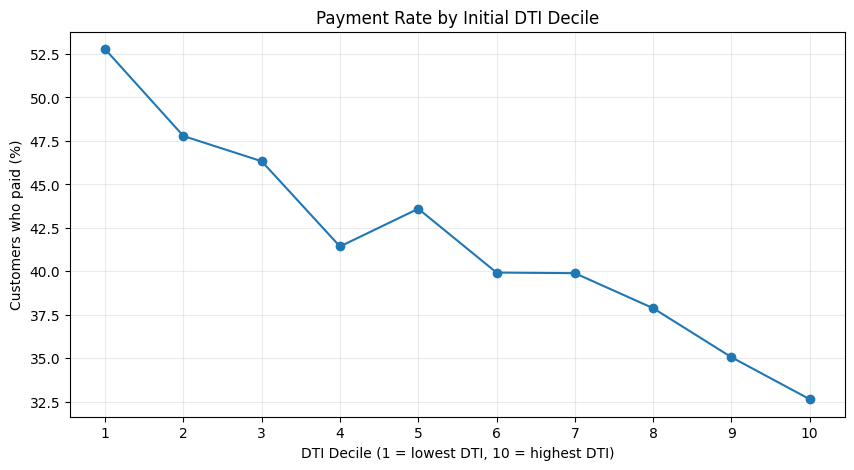

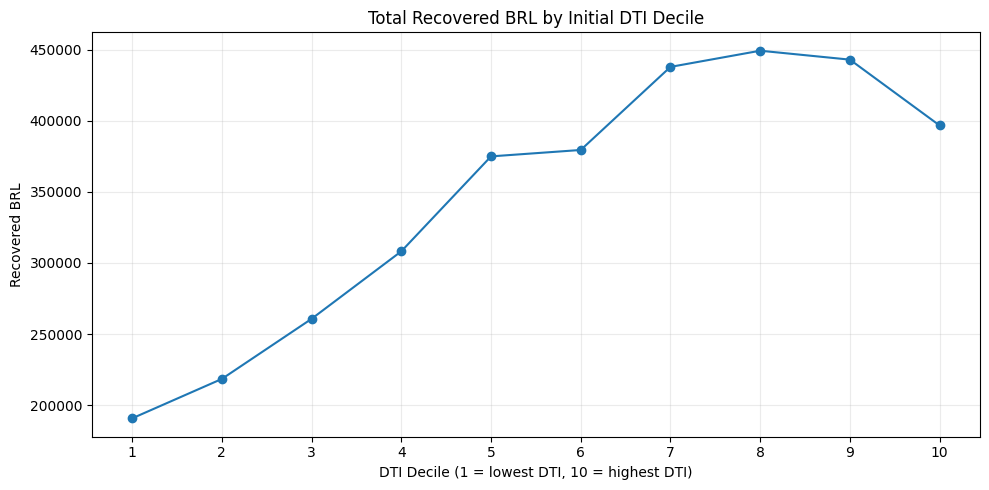

In [77]:
# ============================================================
# DTI × PAYMENT — CUSTOMER LEVEL
# Grain: 1 row per customer
# Expected population: 11,724 customers
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = wa.copy()

# ------------------------------------------------------------
# 1. PREPARE DATA
# ------------------------------------------------------------

df["sent_at"] = pd.to_datetime(df["sent_at"])

df = df.sort_values(
    ["customer_id", "sent_at"]
).copy()


# ============================================================
# 2. CUSTOMER-LEVEL BASE
#    DTI measured at FIRST observed contact
# ============================================================

first_obs = (
    df
    .groupby("customer_id", as_index=False)
    .first()[
        [
            "customer_id",
            "sent_at",
            "outstanding_balance_brl",
            "monthly_salary_brl"
        ]
    ]
    .rename(
        columns={
            "sent_at": "first_observed_at",
            "outstanding_balance_brl": "initial_balance_brl",
            "monthly_salary_brl": "initial_salary_brl"
        }
    )
)


# ============================================================
# 3. CUSTOMER PAYMENT OUTCOME
# ============================================================

customer_outcome = (
    df
    .groupby("customer_id", as_index=False)
    .agg(
        total_messages=("customer_id", "size"),

        # Customer paid at least once
        ever_paid=(
            "paid_within_72h",
            "max"
        ),

        # Total observed recovery
        total_recovered_brl=(
            "amount_paid_brl",
            "sum"
        )
    )
)


# ============================================================
# 4. MERGE
# ============================================================

customer = first_obs.merge(
    customer_outcome,
    on="customer_id",
    how="left",
    validate="one_to_one"
)


# ============================================================
# 5. DTI
# ============================================================

customer["dti_proxy"] = np.where(
    customer["initial_salary_brl"].gt(0),
    customer["initial_balance_brl"]
    / customer["initial_salary_brl"],
    np.nan
)


# ============================================================
# 6. POPULATION VALIDATION
# ============================================================

print("=" * 70)
print("CUSTOMER-LEVEL POPULATION VALIDATION")
print("=" * 70)

print(
    f"Rows                  : {len(customer):,}"
)

print(
    f"Unique customers      : {customer['customer_id'].nunique():,}"
)

print(
    f"Customers with DTI    : {customer['dti_proxy'].notna().sum():,}"
)

print(
    f"Customers without DTI : {customer['dti_proxy'].isna().sum():,}"
)

print(
    f"Ever paid             : {customer['ever_paid'].sum():,.0f}"
)

print(
    f"Payment rate          : {customer['ever_paid'].mean():.2%}"
)

assert (
    len(customer)
    == customer["customer_id"].nunique()
), "ERROR: customer table is not 1 row per customer"

assert (
    customer["customer_id"].nunique()
    == 11724
), "ERROR: expected 11,724 customers"


# ============================================================
# 7. DTI DECILES
# ============================================================

valid_dti = customer[
    customer["dti_proxy"].notna()
].copy()


valid_dti["dti_decile"] = (
    pd.qcut(
        valid_dti["dti_proxy"],
        q=10,
        labels=False,
        duplicates="drop"
    )
    + 1
)


# ============================================================
# 8. DTI VALIDATION TABLE
# ============================================================

dti_validation = (
    valid_dti
    .groupby("dti_decile", as_index=False)
    .agg(
        customers=(
            "customer_id",
            "nunique"
        ),

        min_dti=(
            "dti_proxy",
            "min"
        ),

        median_dti=(
            "dti_proxy",
            "median"
        ),

        max_dti=(
            "dti_proxy",
            "max"
        ),

        payers=(
            "ever_paid",
            "sum"
        ),

        payment_rate=(
            "ever_paid",
            "mean"
        ),

        recovered_brl=(
            "total_recovered_brl",
            "sum"
        ),

        initial_balance_brl=(
            "initial_balance_brl",
            "sum"
        )
    )
)


# ============================================================
# 9. BUSINESS METRICS
# ============================================================

dti_validation["payment_rate_pct"] = (
    100 * dti_validation["payment_rate"]
)

dti_validation["recovery_per_customer_brl"] = (
    dti_validation["recovered_brl"]
    / dti_validation["customers"]
)

dti_validation["portfolio_recovery_rate_pct"] = (
    100
    * dti_validation["recovered_brl"]
    / dti_validation["initial_balance_brl"]
)


# ============================================================
# 10. FINAL CHECK
# ============================================================

print("\n" + "=" * 70)
print("DTI DECILE VALIDATION")
print("=" * 70)

print(
    f"Customers across deciles : "
    f"{dti_validation['customers'].sum():,}"
)

print(
    f"Customers with valid DTI : "
    f"{len(valid_dti):,}"
)

assert (
    dti_validation["customers"].sum()
    == len(valid_dti)
), "ERROR: customers lost or duplicated in deciles"


display(
    dti_validation[
        [
            "dti_decile",
            "customers",
            "min_dti",
            "median_dti",
            "max_dti",
            "payers",
            "payment_rate_pct",
            "recovered_brl",
            "recovery_per_customer_brl",
            "portfolio_recovery_rate_pct"
        ]
    ]
)


# ============================================================
# 11. PAYMENT RATE × DTI DECILE
# ============================================================

plt.figure(figsize=(10, 5))

plt.plot(
    dti_validation["dti_decile"],
    dti_validation["payment_rate_pct"],
    marker="o"
)

plt.xlabel("DTI Decile (1 = lowest DTI, 10 = highest DTI)")
plt.ylabel("Customers who paid (%)")
plt.title("Payment Rate by Initial DTI Decile")

plt.xticks(range(1, 11))
plt.grid(alpha=0.25)

plt.show()

# ============================================================
# RECOVERED BRL × DTI DECILE
# ============================================================

plt.figure(figsize=(10, 5))

plt.plot(
    dti_validation["dti_decile"],
    dti_validation["recovered_brl"],
    marker="o"
)

plt.xlabel("DTI Decile (1 = lowest DTI, 10 = highest DTI)")
plt.ylabel("Recovered BRL")
plt.title("Total Recovered BRL by Initial DTI Decile")

plt.xticks(range(1, 11))

plt.grid(alpha=0.25)

plt.tight_layout()
plt.show()

### ** Relação negativa bastante clara entre dívida relativa à renda e probabilidade de pagamento.

Do menor para o maior decil de DTI, a taxa de clientes que realizaram algum pagamento cai de 52,8% para 32,7%, uma diferença de 20,1 p.p.

maior dívida / renda → menor propensão a pagar → menor percentual da dívida recuperado.

Capacidade de pagamento != oportunidade monetária  
Um cliente com DTI baixo tem maior probabilidade de pagar, mas pode representar poucos reais. Um cliente com DTI alto tem menor probabilidade de pagar, mas pode representar uma oportunidade monetária maior  
(payment_rate_pct x recovered_brl x recovery_per_customer_brl x portfolio_recovery_rate_pct)

DTI x Pagadores (0/1) discrimina bem a propensão ao pagamento, mas não o valor recuperado.  
Clientes de maior DTI pagam menos frequentemente, porém, quando pagam, podem gerar maior recuperação.  
Portanto, DTI x Pagadores (0/1) sozinho não é suficiente para priorização por retorno financeiro.

__

#__________________________________________________________________________________________________________________________________________________________________________________________

# DTI × EXPECTED RECOVERY — CUSTOMER LEVEL

DTI × EXPECTED RECOVERY — POPULATION VALIDATION
Customers                : 11,724
Customers with DTI       : 11,724
Customers who paid       : 4,893
Customers with R$ 0      : 6,831
Total recovered          : R$ 3,459,305.30
Overall E[Recovery]      : R$ 295.06

Expected recovery decomposition: PASS
Customers across DTI deciles: 11,724


,dti_decile,customers,min_dti,median_dti,max_dti,payers,payment_rate_pct,recovery_if_paid_brl,expected_recovery_brl,total_recovered_brl,portfolio_recovery_rate_pct
0,1,1173,0.06,0.12,0.15,619,52.77,308.08,162.58,"190,703.40",47.15
1,2,1172,0.15,0.17,0.19,560,47.78,390.04,186.37,"218,422.81",40.77
2,3,1172,0.19,0.21,0.23,543,46.33,480.09,222.43,"260,689.68",40.39
3,4,1173,0.23,0.26,0.28,486,41.43,634.12,262.73,"308,181.28",36.21
4,5,1172,0.28,0.30,0.32,511,43.60,733.77,319.93,"374,958.86",39.22
5,6,1172,0.32,0.34,0.36,468,39.93,810.82,323.77,"379,464.04",33.69
6,7,1173,0.36,0.39,0.41,468,39.90,935.70,373.32,"437,907.96",35.20
7,8,1172,0.41,0.43,0.46,444,37.88,"1,011.89",383.34,"449,280.32",33.42
8,9,1172,0.46,0.48,0.51,411,35.07,"1,077.87",377.99,"443,003.52",31.17
9,10,1173,0.51,0.56,0.83,383,32.65,"1,035.75",338.19,"396,693.43",27.60


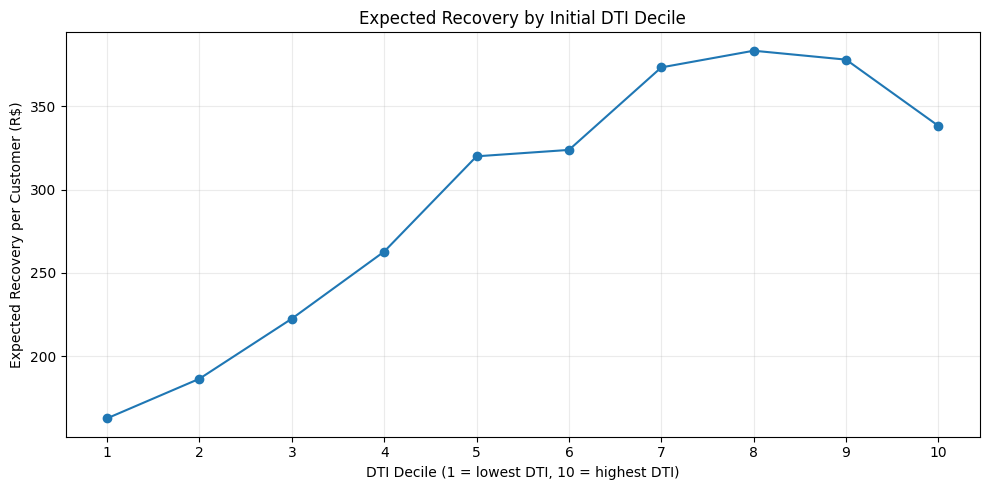

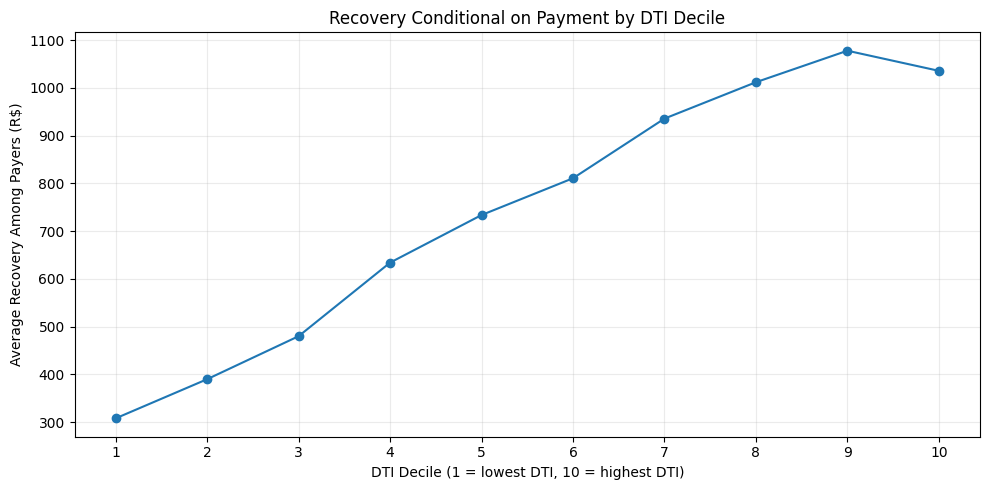

In [78]:
# ============================================================
# DTI × EXPECTED RECOVERY — CUSTOMER LEVEL
# Grain: 1 row per customer
# Population: 11,724 customers
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# 1. VALIDATE CUSTOMER-LEVEL DATASET
# ============================================================

assert len(customer) == customer["customer_id"].nunique()
assert customer["customer_id"].nunique() == 11724

print("=" * 75)
print("DTI × EXPECTED RECOVERY — POPULATION VALIDATION")
print("=" * 75)

print(f"Customers                : {len(customer):,}")
print(f"Customers with DTI       : {customer['dti_proxy'].notna().sum():,}")
print(f"Customers who paid       : {(customer['total_recovered_brl'] > 0).sum():,}")
print(f"Customers with R$ 0      : {(customer['total_recovered_brl'] == 0).sum():,}")
print(f"Total recovered          : R$ {customer['total_recovered_brl'].sum():,.2f}")
print(f"Overall E[Recovery]      : R$ {customer['total_recovered_brl'].mean():,.2f}")


# ============================================================
# 2. CREATE DTI DECILES
# ============================================================

dti_er = customer[
    customer["dti_proxy"].notna()
].copy()

dti_er["dti_decile"] = (
    pd.qcut(
        dti_er["dti_proxy"],
        q=10,
        labels=False,
        duplicates="drop"
    )
    + 1
)


# ============================================================
# 3. DTI × EXPECTED RECOVERY TABLE
# ============================================================

dti_expected_recovery = (
    dti_er
    .groupby("dti_decile", as_index=False)
    .agg(

        customers=(
            "customer_id",
            "nunique"
        ),

        min_dti=(
            "dti_proxy",
            "min"
        ),

        median_dti=(
            "dti_proxy",
            "median"
        ),

        max_dti=(
            "dti_proxy",
            "max"
        ),

        initial_balance_brl=(
            "initial_balance_brl",
            "sum"
        ),

        payers=(
            "ever_paid",
            "sum"
        ),

        total_recovered_brl=(
            "total_recovered_brl",
            "sum"
        ),

        # ----------------------------------------------------
        # THIS IS THE EMPIRICAL EXPECTED RECOVERY
        # includes customers with ZERO recovery
        # ----------------------------------------------------

        expected_recovery_brl=(
            "total_recovered_brl",
            "mean"
        ),

        median_recovery_brl=(
            "total_recovered_brl",
            "median"
        )
    )
)


# ============================================================
# 4. PAYMENT PROBABILITY
# ============================================================

dti_expected_recovery["payment_rate_pct"] = (
    100
    * dti_expected_recovery["payers"]
    / dti_expected_recovery["customers"]
)


# ============================================================
# 5. RECOVERY CONDITIONAL ON PAYMENT
#
# E[R | R > 0]
# ============================================================

dti_expected_recovery["recovery_if_paid_brl"] = (
    dti_expected_recovery["total_recovered_brl"]
    / dti_expected_recovery["payers"]
)


# ============================================================
# 6. EXPECTED RECOVERY — DECOMPOSITION
#
# E[R] =
# P(pay) × E[R | pay]
# ============================================================

dti_expected_recovery["expected_recovery_decomposed_brl"] = (
    (
        dti_expected_recovery["payment_rate_pct"]
        / 100
    )
    *
    dti_expected_recovery["recovery_if_paid_brl"]
)


# ============================================================
# 7. PORTFOLIO RECOVERY RATE
# ============================================================

dti_expected_recovery["portfolio_recovery_rate_pct"] = (
    100
    * dti_expected_recovery["total_recovered_brl"]
    / dti_expected_recovery["initial_balance_brl"]
)


# ============================================================
# 8. MATHEMATICAL VALIDATION
#
# mean recovery MUST equal:
# P(pay) × mean recovery conditional on payment
# ============================================================

np.testing.assert_allclose(
    dti_expected_recovery["expected_recovery_brl"],
    dti_expected_recovery["expected_recovery_decomposed_brl"],
    rtol=1e-10,
    atol=1e-8
)

print("\nExpected recovery decomposition: PASS")


# ============================================================
# 9. POPULATION VALIDATION
# ============================================================

assert (
    dti_expected_recovery["customers"].sum()
    == 11724
)

print(
    f"Customers across DTI deciles: "
    f"{dti_expected_recovery['customers'].sum():,}"
)


# ============================================================
# 10. DISPLAY TABLE
# ============================================================

display(
    dti_expected_recovery[
        [
            "dti_decile",
            "customers",

            "min_dti",
            "median_dti",
            "max_dti",

            "payers",
            "payment_rate_pct",

            "recovery_if_paid_brl",

            "expected_recovery_brl",

            "total_recovered_brl",

            "portfolio_recovery_rate_pct"
        ]
    ]
)


# ============================================================
# 11. GRAPH — EXPECTED RECOVERY × DTI DECILE
# ============================================================

plt.figure(figsize=(10, 5))

plt.plot(
    dti_expected_recovery["dti_decile"],
    dti_expected_recovery["expected_recovery_brl"],
    marker="o"
)

plt.xlabel(
    "DTI Decile (1 = lowest DTI, 10 = highest DTI)"
)

plt.ylabel(
    "Expected Recovery per Customer (R$)"
)

plt.title(
    "Expected Recovery by Initial DTI Decile"
)

plt.xticks(range(1, 11))

plt.grid(alpha=0.25)

plt.tight_layout()

plt.show()


# ============================================================
# 12. GRAPH — RECOVERY CONDITIONAL ON PAYMENT
# ============================================================

plt.figure(figsize=(10, 5))

plt.plot(
    dti_expected_recovery["dti_decile"],
    dti_expected_recovery["recovery_if_paid_brl"],
    marker="o"
)

plt.xlabel(
    "DTI Decile (1 = lowest DTI, 10 = highest DTI)"
)

plt.ylabel(
    "Average Recovery Among Payers (R$)"
)

plt.title(
    "Recovery Conditional on Payment by DTI Decile"
)

plt.xticks(range(1, 11))

plt.grid(alpha=0.25)

plt.tight_layout()

plt.show()

In [79]:
# ============================================================
# STEP 1 — EARLY COLLECTIONS POPULATION
#
# Definition:
# First observed WhatsApp event while customer is in
# DPD 1–30.
#
# IMPORTANT:
# This is NOT yet the final target definition.
# We are only auditing the population.
# ============================================================

import pandas as pd
import numpy as np


df = wa.copy()

df["sent_at"] = pd.to_datetime(df["sent_at"])

df = (
    df
    .sort_values(
        ["customer_id", "sent_at"]
    )
    .copy()
)


DATA_END = df["sent_at"].max()


# ============================================================
# 1. ALL EVENTS OBSERVED DURING DPD 1–30
# ============================================================

early_events = df[
    df["days_past_due"].between(
        1,
        30,
        inclusive="both"
    )
].copy()


print("=" * 90)
print("EARLY COLLECTIONS — DPD 1–30 POPULATION")
print("=" * 90)

print(
    f"Total WA customers             : "
    f"{df['customer_id'].nunique():,}"
)

print(
    f"Customers observed DPD 1–30    : "
    f"{early_events['customer_id'].nunique():,}"
)


# ============================================================
# 2. FIRST OBSERVED EVENT INSIDE DPD 1–30
# ============================================================

first_early = (
    early_events
    .groupby(
        "customer_id",
        as_index=False
    )
    .first()
)


first_early = first_early.rename(
    columns={
        "sent_at": "score_at",
        "days_past_due": "dpd_at_score",
        "outstanding_balance_brl": "balance_at_score",
        "monthly_salary_brl": "salary_at_score"
    }
)


# ============================================================
# 3. DTI AT FIRST OBSERVABLE SCORE
# ============================================================

first_early["dti_at_score"] = np.where(
    first_early["salary_at_score"] > 0,

    first_early["balance_at_score"]
    / first_early["salary_at_score"],

    np.nan
)


# ============================================================
# 4. HOW LATE DO WE FIRST OBSERVE THE CUSTOMER?
# ============================================================

print()
print("=" * 90)
print("DPD AT FIRST OBSERVED EARLY-COLLECTION EVENT")
print("=" * 90)

print(
    first_early["dpd_at_score"]
    .describe(
        percentiles=[
            .10,
            .25,
            .50,
            .75,
            .90,
            .95,
            .99
        ]
    )
)


# ============================================================
# 5. EXACT DISTRIBUTION BY FIRST DPD
# ============================================================

dpd_distribution = (
    first_early
    .groupby(
        "dpd_at_score",
        as_index=False
    )
    .agg(
        customers=(
            "customer_id",
            "nunique"
        )
    )
)


dpd_distribution["share_pct"] = (
    100
    * dpd_distribution["customers"]
    / len(first_early)
)


dpd_distribution["cumulative_customers"] = (
    dpd_distribution["customers"]
    .cumsum()
)


dpd_distribution["cumulative_share_pct"] = (
    100
    * dpd_distribution["cumulative_customers"]
    / len(first_early)
)


display(dpd_distribution)


# ============================================================
# 6. BUSINESS-FRIENDLY DPD BANDS
# ============================================================

first_early["entry_dpd_band"] = pd.cut(
    first_early["dpd_at_score"],

    bins=[
        0,
        1,
        5,
        10,
        15,
        20,
        25,
        30
    ],

    labels=[
        "DPD 1",
        "DPD 2–5",
        "DPD 6–10",
        "DPD 11–15",
        "DPD 16–20",
        "DPD 21–25",
        "DPD 26–30"
    ]
)


entry_band_summary = (
    first_early
    .groupby(
        "entry_dpd_band",
        observed=True,
        as_index=False
    )
    .agg(
        customers=(
            "customer_id",
            "nunique"
        )
    )
)


entry_band_summary["share_pct"] = (
    100
    * entry_band_summary["customers"]
    / len(first_early)
)


entry_band_summary["cumulative_customers"] = (
    entry_band_summary["customers"]
    .cumsum()
)


entry_band_summary["cumulative_share_pct"] = (
    100
    * entry_band_summary["cumulative_customers"]
    / len(first_early)
)


print()
print("=" * 90)
print("ENTRY DPD BANDS")
print("=" * 90)

display(entry_band_summary)


# ============================================================
# 7. COMPARE WITH DPD1-ONLY POPULATION
# ============================================================

n_dpd1 = (
    first_early["dpd_at_score"]
    .eq(1)
    .sum()
)

n_dpd_le30 = len(first_early)

incremental = (
    n_dpd_le30
    -
    n_dpd1
)


print()
print("=" * 90)
print("POPULATION GAIN VS DPD1 ONLY")
print("=" * 90)

print(
    f"First observed exactly DPD1    : "
    f"{n_dpd1:,}"
)

print(
    f"First observed within DPD1–30  : "
    f"{n_dpd_le30:,}"
)

print(
    f"Additional customers captured  : "
    f"{incremental:,}"
)

print(
    f"Population increase            : "
    f"{100 * incremental / n_dpd1:.2f}%"
)


# ============================================================
# 8. ENTRY MONTH
# ============================================================

first_early["score_month"] = (
    first_early["score_at"]
    .dt.to_period("M")
    .astype(str)
)


monthly_entry = (
    first_early
    .groupby(
        "score_month",
        as_index=False
    )
    .agg(

        customers=(
            "customer_id",
            "nunique"
        ),

        median_entry_dpd=(
            "dpd_at_score",
            "median"
        ),

        mean_entry_dpd=(
            "dpd_at_score",
            "mean"
        )
    )
)


print()
print("=" * 90)
print("POPULATION BY ENTRY MONTH")
print("=" * 90)

display(monthly_entry)


# ============================================================
# 9. VALIDATIONS
# ============================================================

assert (
    len(first_early)
    ==
    first_early["customer_id"].nunique()
)

assert (
    first_early["dpd_at_score"]
    .between(1, 30)
    .all()
)

assert (
    first_early["dti_at_score"]
    .notna()
    .all()
)


print()
print("EARLY COLLECTIONS POPULATION: PASS")

EARLY COLLECTIONS — DPD 1–30 POPULATION
Total WA customers             : 11,724
Customers observed DPD 1–30    : 11,723

DPD AT FIRST OBSERVED EARLY-COLLECTION EVENT
count   11,723.00
mean         3.05
std          2.47
min          1.00
10%          1.00
25%          1.00
50%          2.00
75%          4.00
90%          6.00
95%          8.00
99%         12.00
max         27.00
Name: dpd_at_score, dtype: float64


,dpd_at_score,customers,share_pct,cumulative_customers,cumulative_share_pct
0,1,3841,32.76,3841,32.76
1,2,2482,21.17,6323,53.94
2,3,1745,14.89,8068,68.82
3,4,1241,10.59,9309,79.41
4,5,822,7.01,10131,86.42
5,6,558,4.76,10689,91.18
6,7,330,2.81,11019,93.99
7,8,228,1.94,11247,95.94
8,9,162,1.38,11409,97.32
9,10,101,0.86,11510,98.18



ENTRY DPD BANDS


,entry_dpd_band,customers,share_pct,cumulative_customers,cumulative_share_pct
0,DPD 1,3841,32.76,3841,32.76
1,DPD 2–5,6290,53.66,10131,86.42
2,DPD 6–10,1379,11.76,11510,98.18
3,DPD 11–15,186,1.59,11696,99.77
4,DPD 16–20,22,0.19,11718,99.96
5,DPD 21–25,4,0.03,11722,99.99
6,DPD 26–30,1,0.01,11723,100.00



POPULATION GAIN VS DPD1 ONLY
First observed exactly DPD1    : 3,841
First observed within DPD1–30  : 11,723
Additional customers captured  : 7,882
Population increase            : 205.21%

POPULATION BY ENTRY MONTH


,score_month,customers,median_entry_dpd,mean_entry_dpd
0,2026-06,3681,2.00,2.95
1,2026-07,4155,2.00,3.09
2,2026-08,3887,2.00,3.11



EARLY COLLECTIONS POPULATION: PASS


In [80]:
# ============================================================
# STEP — INFER DPD30 DATE FROM FIRST OBSERVED DPD
# ============================================================

import pandas as pd
import numpy as np


customer_base = first_early.copy()


# ============================================================
# 1. DAYS REMAINING UNTIL DPD30
#
# Example:
# DPD3 -> 30 - 3 = 27 days remaining
# ============================================================

customer_base["days_until_dpd30"] = (
    30
    -
    customer_base["dpd_at_score"]
)


# ============================================================
# 2. INFER DATE CUSTOMER REACHES DPD30
# ============================================================

customer_base["dpd30_at"] = (
    customer_base["score_at"]
    +
    pd.to_timedelta(
        customer_base["days_until_dpd30"],
        unit="D"
    )
)


# ============================================================
# 3. MATURITY
#
# We can only build the complete target if DPD30
# happens before the end of our dataset.
# ============================================================

customer_base["mature_to_dpd30"] = (
    customer_base["dpd30_at"]
    <= DATA_END
)


# ============================================================
# 4. VALIDATION
# ============================================================

assert (
    customer_base["days_until_dpd30"]
    ==
    30 - customer_base["dpd_at_score"]
).all()


assert (
    customer_base["dpd30_at"]
    ==
    (
        customer_base["score_at"]
        +
        pd.to_timedelta(
            30 - customer_base["dpd_at_score"],
            unit="D"
        )
    )
).all()


print("DPD30 DATE CALCULATION: PASS")


# ============================================================
# 5. DISPLAY EXAMPLES
# ============================================================

print()
print("=" * 100)
print("INFERRED DPD30 DATE")
print("=" * 100)


display(
    customer_base[
        [
            "customer_id",
            "score_at",
            "dpd_at_score",
            "days_until_dpd30",
            "dpd30_at",
            "mature_to_dpd30"
        ]
    ]
    .sort_values(
        ["score_at", "customer_id"]
    )
    .head(30)
)

DPD30 DATE CALCULATION: PASS

INFERRED DPD30 DATE


,customer_id,score_at,dpd_at_score,days_until_dpd30,dpd30_at,mature_to_dpd30
1892,C001934,2026-06-01 09:18:00,1,29,2026-06-30 09:18:00,True
7657,C007836,2026-06-01 09:18:00,1,29,2026-06-30 09:18:00,True
4792,C004887,2026-06-01 09:48:00,1,29,2026-06-30 09:48:00,True
8996,C009207,2026-06-01 09:53:00,1,29,2026-06-30 09:53:00,True
3401,C003478,2026-06-01 09:54:00,1,29,2026-06-30 09:54:00,True
10592,C010842,2026-06-01 09:56:00,1,29,2026-06-30 09:56:00,True
4942,C005040,2026-06-01 10:06:00,1,29,2026-06-30 10:06:00,True
3652,C003731,2026-06-01 10:16:00,1,29,2026-06-30 10:16:00,True
8894,C009101,2026-06-01 10:21:00,1,29,2026-06-30 10:21:00,True
3267,C003340,2026-06-01 10:22:00,1,29,2026-06-30 10:22:00,True


In [81]:
# ============================================================
# STEP — BUILD RECOVERY TO DPD30 TARGET
#
# Grain final:
# 1 row = customer
#
# Window:
# first observed early-collections event
#          ->
# inferred DPD30 date
# ============================================================

import pandas as pd
import numpy as np


# ============================================================
# 1. KEEP ONLY MATURE CUSTOMERS
# ============================================================

mature_base = (
    customer_base[
        customer_base["mature_to_dpd30"]
    ]
    .copy()
)


print("=" * 90)
print("MATURE POPULATION")
print("=" * 90)

print(
    f"Mature customers : "
    f"{len(mature_base):,}"
)


# ============================================================
# 2. MESSAGE-LEVEL DATA
# ============================================================

messages = wa.copy()

messages["sent_at"] = pd.to_datetime(
    messages["sent_at"]
)


# ============================================================
# 3. ATTACH CUSTOMER TARGET WINDOW
# ============================================================

window = mature_base[
    [
        "customer_id",
        "score_at",
        "dpd_at_score",
        "dpd30_at",
        "balance_at_score",
        "salary_at_score",
        "dti_at_score"
    ]
].copy()


messages = messages.merge(
    window,
    on="customer_id",
    how="inner",
    validate="many_to_one"
)


# ============================================================
# 4. IDENTIFY EVENTS INSIDE TARGET WINDOW
# ============================================================

messages["inside_recovery_window"] = (
    (messages["sent_at"] >= messages["score_at"])
    &
    (messages["sent_at"] <= messages["dpd30_at"])
)


target_events = messages[
    messages["inside_recovery_window"]
].copy()


# ============================================================
# 5. EXTRA SAFETY:
# EVENT DPD SHOULD ALSO BE <= 30
# ============================================================

print()
print("=" * 90)
print("TARGET WINDOW AUDIT")
print("=" * 90)

print(
    f"Messages inside window : "
    f"{len(target_events):,}"
)

print(
    f"Customers represented  : "
    f"{target_events['customer_id'].nunique():,}"
)

print(
    f"Minimum event DPD       : "
    f"{target_events['days_past_due'].min():.0f}"
)

print(
    f"Maximum event DPD       : "
    f"{target_events['days_past_due'].max():.0f}"
)


# ============================================================
# 6. RECOVERY TARGET
# ============================================================

recovery_target = (
    target_events
    .groupby(
        "customer_id",
        as_index=False
    )
    .agg(

        messages_to_dpd30=(
            "customer_id",
            "size"
        ),

        recovery_to_dpd30_brl=(
            "amount_paid_brl",
            "sum"
        )
    )
)


# ============================================================
# 7. MERGE BACK TO CUSTOMER BASE
# ============================================================

model_base = mature_base.merge(
    recovery_target,
    on="customer_id",
    how="left",
    validate="one_to_one"
)


# ============================================================
# 8. ZERO RECOVERY
# ============================================================

model_base["recovery_to_dpd30_brl"] = (
    model_base["recovery_to_dpd30_brl"]
    .fillna(0)
)


model_base["messages_to_dpd30"] = (
    model_base["messages_to_dpd30"]
    .fillna(0)
)


# ============================================================
# 9. BINARY TARGET
# ============================================================

model_base["pay_to_dpd30"] = (
    model_base["recovery_to_dpd30_brl"] > 0
).astype(int)


# ============================================================
# 10. TARGET AUDIT
# ============================================================

print()
print("=" * 90)
print("EXPECTED RECOVERY TO DPD30 — TARGET")
print("=" * 90)

print(
    f"Customers              : "
    f"{len(model_base):,}"
)

print(
    f"Payers                 : "
    f"{model_base['pay_to_dpd30'].sum():,}"
)

print(
    f"Non-payers             : "
    f"{(model_base['pay_to_dpd30'] == 0).sum():,}"
)

print(
    f"Payment rate           : "
    f"{100 * model_base['pay_to_dpd30'].mean():.2f}%"
)

print(
    f"Total recovery         : "
    f"R$ {model_base['recovery_to_dpd30_brl'].sum():,.2f}"
)

print(
    f"Expected recovery      : "
    f"R$ {model_base['recovery_to_dpd30_brl'].mean():,.2f}"
)


# ============================================================
# 11. CONDITIONAL RECOVERY
# ============================================================

payers = model_base[
    model_base["pay_to_dpd30"] == 1
].copy()


print()
print("=" * 90)
print("RECOVERY | PAYMENT")
print("=" * 90)

print(
    f"E[Recovery | Pay]      : "
    f"R$ {payers['recovery_to_dpd30_brl'].mean():,.2f}"
)

print(
    f"Median Recovery | Pay  : "
    f"R$ {payers['recovery_to_dpd30_brl'].median():,.2f}"
)


print()

print(
    payers["recovery_to_dpd30_brl"]
    .describe(
        percentiles=[
            .50,
            .75,
            .90,
            .95,
            .99
        ]
    )
)


# ============================================================
# 12. EXPECTED VALUE DECOMPOSITION
# ============================================================

p_pay = (
    model_base["pay_to_dpd30"]
    .mean()
)

conditional_recovery = (
    payers["recovery_to_dpd30_brl"]
    .mean()
)

expected_recovery = (
    model_base["recovery_to_dpd30_brl"]
    .mean()
)

decomposed_expected_recovery = (
    p_pay
    *
    conditional_recovery
)


print()
print("=" * 90)
print("EXPECTED RECOVERY TO DPD30 — DECOMPOSITION")
print("=" * 90)

print(
    f"P(Pay to DPD30)             : "
    f"{p_pay:.2%}"
)

print(
    f"E[R | Pay to DPD30]         : "
    f"R$ {conditional_recovery:,.2f}"
)

print(
    f"P(Pay) × E[R | Pay]         : "
    f"R$ {decomposed_expected_recovery:,.2f}"
)

print(
    f"Empirical E[Recovery]       : "
    f"R$ {expected_recovery:,.2f}"
)


np.testing.assert_allclose(
    decomposed_expected_recovery,
    expected_recovery,
    rtol=1e-10,
    atol=1e-8
)


# ============================================================
# 13. FINAL VALIDATIONS
# ============================================================

assert (
    len(model_base)
    ==
    model_base["customer_id"].nunique()
)


assert (
    model_base.loc[
        model_base["pay_to_dpd30"] == 0,
        "recovery_to_dpd30_brl"
    ] == 0
).all()


assert (
    model_base.loc[
        model_base["pay_to_dpd30"] == 1,
        "recovery_to_dpd30_brl"
    ] > 0
).all()


print()
print("EXPECTED RECOVERY TO DPD30 TARGET: PASS")

MATURE POPULATION
Mature customers : 8,317

TARGET WINDOW AUDIT
Messages inside window : 49,543
Customers represented  : 8,317
Minimum event DPD       : 1
Maximum event DPD       : 30

EXPECTED RECOVERY TO DPD30 — TARGET
Customers              : 8,317
Payers                 : 3,319
Non-payers             : 4,998
Payment rate           : 39.91%
Total recovery         : R$ 2,320,184.90
Expected recovery      : R$ 278.97

RECOVERY | PAYMENT
E[Recovery | Pay]      : R$ 699.06
Median Recovery | Pay  : R$ 570.04

count   3,319.00
mean      699.06
std       476.00
min        63.57
50%       570.04
75%       934.91
90%     1,403.96
95%     1,768.36
99%     2,000.00
max     2,000.00
Name: recovery_to_dpd30_brl, dtype: float64

EXPECTED RECOVERY TO DPD30 — DECOMPOSITION
P(Pay to DPD30)             : 39.91%
E[R | Pay to DPD30]         : R$ 699.06
P(Pay) × E[R | Pay]         : R$ 278.97
Empirical E[Recovery]       : R$ 278.97

EXPECTED RECOVERY TO DPD30 TARGET: PASS


In [82]:
# ============================================================
# CANONICAL MODEL BASE
# Population: customers mature through DPD30
#
# Grain:
# 1 row = 1 customer
#
# Final columns:
# customer_id
# outstanding_balance_brl
# monthly_salary_brl
# DTI
# recovery_to_dpd30_brl
# ============================================================

import pandas as pd
import numpy as np


# ============================================================
# 1. START FROM MATURE CUSTOMERS ONLY
# ============================================================

mature_customers = (
    customer_base[
        customer_base["mature_to_dpd30"]
    ]
    [
        [
            "customer_id",
            "score_at",
            "dpd30_at",
            "balance_at_score",
            "salary_at_score"
        ]
    ]
    .copy()
)


# ------------------------------------------------------------
# CRITICAL:
# exactly one row per customer
# ------------------------------------------------------------

assert (
    len(mature_customers)
    ==
    mature_customers["customer_id"].nunique()
)

assert len(mature_customers) == 8_317


print("=" * 90)
print("MATURE POPULATION")
print("=" * 90)

print(f"Customers : {len(mature_customers):,}")


# ============================================================
# 2. GET ORIGINAL MESSAGE / PAYMENT EVENTS
# ============================================================

events = wa[
    [
        "customer_id",
        "sent_at",
        "amount_paid_brl"
    ]
].copy()

events["sent_at"] = pd.to_datetime(events["sent_at"])


# ============================================================
# 3. ATTACH EACH CUSTOMER'S INDIVIDUAL TARGET WINDOW
# ============================================================

events = events.merge(
    mature_customers[
        [
            "customer_id",
            "score_at",
            "dpd30_at"
        ]
    ],
    on="customer_id",
    how="inner",
    validate="many_to_one"
)


# ============================================================
# 4. KEEP ONLY EVENTS INSIDE:
#
# score_at <= event <= DPD30
# ============================================================

events_window = events[
    (events["sent_at"] >= events["score_at"])
    &
    (events["sent_at"] <= events["dpd30_at"])
].copy()


# ============================================================
# 5. RECOVERY
#
# IMPORTANT:
# We aggregate directly from the original event-level table.
# We do NOT merge customer recovery back to message-level data
# and then sum again.
# ============================================================

recovery_customer = (
    events_window
    .groupby(
        "customer_id",
        as_index=False
    )
    .agg(
        recovery_to_dpd30_brl=(
            "amount_paid_brl",
            "sum"
        )
    )
)


# ============================================================
# 6. CREATE FINAL CUSTOMER-LEVEL BASE
# ============================================================

base_dpd30 = (
    mature_customers
    .merge(
        recovery_customer,
        on="customer_id",
        how="left",
        validate="one_to_one"
    )
)


# Customers without payment = zero recovery
base_dpd30["recovery_to_dpd30_brl"] = (
    base_dpd30["recovery_to_dpd30_brl"]
    .fillna(0)
)


# ============================================================
# 7. RENAME STATE VARIABLES
# ============================================================

base_dpd30 = base_dpd30.rename(
    columns={
        "balance_at_score":
            "outstanding_balance_brl",

        "salary_at_score":
            "monthly_salary_brl"
    }
)


# ============================================================
# 8. DTI AT SCORE
# ============================================================

base_dpd30["DTI"] = np.where(
    base_dpd30["monthly_salary_brl"] > 0,

    base_dpd30["outstanding_balance_brl"]
    /
    base_dpd30["monthly_salary_brl"],

    np.nan
)


# ============================================================
# 9. KEEP ONLY FINAL 5 COLUMNS
# ============================================================

base_dpd30 = base_dpd30[
    [
        "customer_id",
        "outstanding_balance_brl",
        "monthly_salary_brl",
        "DTI",
        "recovery_to_dpd30_brl"
    ]
].copy()


# ============================================================
# 10. CRITICAL VALIDATIONS
# ============================================================

# Exactly 8,317 rows
assert len(base_dpd30) == 8_317


# Exactly 8,317 unique customers
assert (
    base_dpd30["customer_id"].nunique()
    ==
    8_317
)


# No duplicated customer
assert not (
    base_dpd30["customer_id"]
    .duplicated()
    .any()
)


# Recovery cannot be negative
assert (
    base_dpd30["recovery_to_dpd30_brl"]
    >= 0
).all()


# Balance must be positive
assert (
    base_dpd30["outstanding_balance_brl"]
    > 0
).all()


# Recovery should not materially exceed
# balance at score.
#
# R$0.02 tolerance for rounding.
assert (
    base_dpd30["recovery_to_dpd30_brl"]
    <=
    base_dpd30["outstanding_balance_brl"] + 0.02
).all()


# ============================================================
# 11. VALIDATE AGAINST PREVIOUS TARGET
# ============================================================

previous_total_recovery = (
    model_base["recovery_to_dpd30_brl"]
    .sum()
)

new_total_recovery = (
    base_dpd30["recovery_to_dpd30_brl"]
    .sum()
)


np.testing.assert_allclose(
    new_total_recovery,
    previous_total_recovery,
    rtol=0,
    atol=0.01
)


# ============================================================
# 12. FINAL AUDIT
# ============================================================

print()
print("=" * 90)
print("FINAL CANONICAL BASE — DPD30")
print("=" * 90)

print(
    f"Rows                    : "
    f"{len(base_dpd30):,}"
)

print(
    f"Unique customers        : "
    f"{base_dpd30['customer_id'].nunique():,}"
)

print(
    f"Duplicated customers    : "
    f"{base_dpd30['customer_id'].duplicated().sum():,}"
)

print(
    f"Total recovery          : "
    f"R$ {base_dpd30['recovery_to_dpd30_brl'].sum():,.2f}"
)

print(
    f"Customers with recovery : "
    f"{(base_dpd30['recovery_to_dpd30_brl'] > 0).sum():,}"
)

print(
    f"Customers zero recovery : "
    f"{(base_dpd30['recovery_to_dpd30_brl'] == 0).sum():,}"
)

print(
    f"Missing DTI             : "
    f"{base_dpd30['DTI'].isna().sum():,}"
)


print()
print("FINAL BASE: PASS")


# ============================================================
# 13. PREVIEW
# ============================================================

display(
    base_dpd30.head(20)
)

MATURE POPULATION
Customers : 8,317

FINAL CANONICAL BASE — DPD30
Rows                    : 8,317
Unique customers        : 8,317
Duplicated customers    : 0
Total recovery          : R$ 2,320,184.90
Customers with recovery : 3,319
Customers zero recovery : 4,998
Missing DTI             : 0

FINAL BASE: PASS


,customer_id,outstanding_balance_brl,monthly_salary_brl,DTI,recovery_to_dpd30_brl
0,C000001,934.58,"1,680.00",0.56,934.58
1,C000002,"1,143.79","2,670.00",0.43,0.00
2,C000003,758.22,"1,200.00",0.63,0.00
3,C000004,"1,331.09","4,500.00",0.30,"1,331.09"
4,C000006,488.23,"2,100.00",0.23,0.00
5,C000007,314.44,"2,090.00",0.15,0.00
6,C000008,927.60,"2,750.00",0.34,0.00
7,C000009,878.15,"2,130.00",0.41,0.00
8,C000010,"1,470.84","2,170.00",0.68,0.00
9,C000011,966.15,"3,320.00",0.29,456.62


In [83]:
# ============================================================
# MODEL 1 — PROBABILITY OF PAYMENT GIVEN DTI
#
# Objective:
# P(Pay to DPD30 | DTI)
#
# Grain:
# 1 row = 1 mature customer
# ============================================================

import pandas as pd
import numpy as np


df = base_dpd30.copy()


# ============================================================
# 1. CREATE BINARY TARGET
# ============================================================

df["pay_to_dpd30"] = (
    df["recovery_to_dpd30_brl"] > 0
).astype(int)


# ============================================================
# 2. BASIC VALIDATION
# ============================================================

print("=" * 90)
print("MODEL 1 — P(PAY TO DPD30 | DTI)")
print("=" * 90)

print(f"Customers       : {len(df):,}")
print(f"Payers          : {df['pay_to_dpd30'].sum():,}")
print(f"Non-payers      : {(df['pay_to_dpd30'] == 0).sum():,}")
print(f"Payment rate    : {df['pay_to_dpd30'].mean():.2%}")
print(f"Missing DTI     : {df['DTI'].isna().sum():,}")


assert len(df) == 8_317
assert df["customer_id"].nunique() == 8_317
assert set(df["pay_to_dpd30"].unique()) <= {0, 1}

print()
print("TARGET: PASS")

MODEL 1 — P(PAY TO DPD30 | DTI)
Customers       : 8,317
Payers          : 3,319
Non-payers      : 4,998
Payment rate    : 39.91%
Missing DTI     : 0

TARGET: PASS


EMPIRICAL P(PAY TO DPD30 | DTI DECILE)


,dti_decile,customers,min_DTI,median_DTI,max_DTI,payers,payment_rate_pct
0,1,832,0.06,0.12,0.15,422,50.72
1,2,832,0.15,0.17,0.19,388,46.63
2,3,831,0.19,0.21,0.23,369,44.40
3,4,832,0.23,0.25,0.27,324,38.94
4,5,832,0.27,0.29,0.32,347,41.71
5,6,831,0.32,0.34,0.36,315,37.91
6,7,834,0.36,0.39,0.41,318,38.13
7,8,829,0.41,0.43,0.46,304,36.67
8,9,832,0.46,0.48,0.51,274,32.93
9,10,832,0.51,0.55,0.83,258,31.01


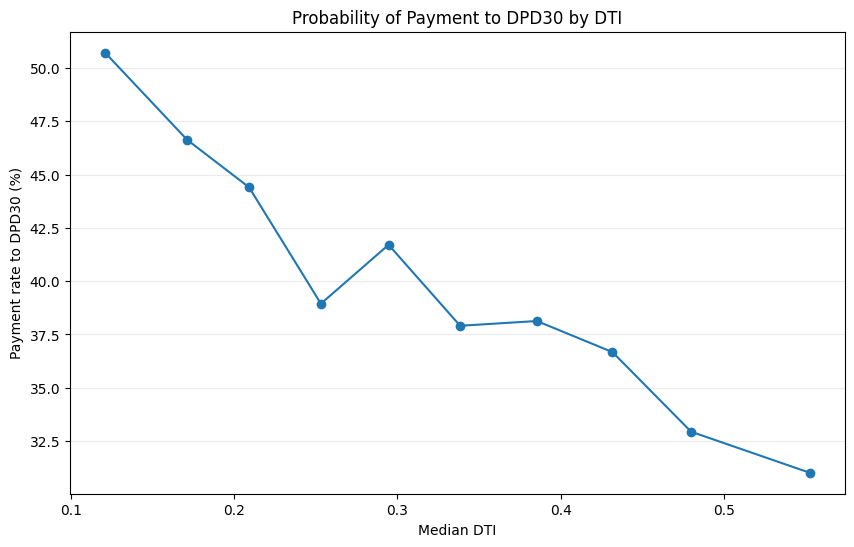

In [84]:
# ============================================================
# DTI DECILES vs PAYMENT PROBABILITY
# ============================================================

analysis = df[
    [
        "customer_id",
        "DTI",
        "pay_to_dpd30"
    ]
].dropna().copy()


# ============================================================
# DTI DECILES
# ============================================================

analysis["dti_decile"] = (
    pd.qcut(
        analysis["DTI"],
        q=10,
        labels=False,
        duplicates="drop"
    )
    + 1
)


# ============================================================
# SUMMARY
# ============================================================

dti_payment = (
    analysis
    .groupby(
        "dti_decile",
        as_index=False
    )
    .agg(

        customers=(
            "customer_id",
            "nunique"
        ),

        min_DTI=(
            "DTI",
            "min"
        ),

        median_DTI=(
            "DTI",
            "median"
        ),

        max_DTI=(
            "DTI",
            "max"
        ),

        payers=(
            "pay_to_dpd30",
            "sum"
        ),

        payment_rate=(
            "pay_to_dpd30",
            "mean"
        )
    )
)


dti_payment["payment_rate_pct"] = (
    100 *
    dti_payment["payment_rate"]
)


print("=" * 100)
print("EMPIRICAL P(PAY TO DPD30 | DTI DECILE)")
print("=" * 100)

display(
    dti_payment[
        [
            "dti_decile",
            "customers",
            "min_DTI",
            "median_DTI",
            "max_DTI",
            "payers",
            "payment_rate_pct"
        ]
    ]
)

import matplotlib.pyplot as plt


plt.figure(figsize=(10, 6))

plt.plot(
    dti_payment["median_DTI"],
    dti_payment["payment_rate_pct"],
    marker="o"
)

plt.xlabel("Median DTI")
plt.ylabel("Payment rate to DPD30 (%)")

plt.title(
    "Probability of Payment to DPD30 by DTI"
)

plt.grid(
    axis="y",
    alpha=0.25
)

plt.show()

In [85]:
# ============================================================
# MODEL 1 — P(PAY TO DPD30 | DTI)
# TEMPORAL DEVELOPMENT BASE
# ============================================================

import pandas as pd
import numpy as np


# ------------------------------------------------------------
# Base canônica
# ------------------------------------------------------------

model_df = base_dpd30.copy()


# Binary target
model_df["pay_to_dpd30"] = (
    model_df["recovery_to_dpd30_brl"] > 0
).astype(int)


# ------------------------------------------------------------
# Recover score_at ONLY for temporal split
# NOT A MODEL FEATURE
# ------------------------------------------------------------

score_dates = (
    customer_base[
        [
            "customer_id",
            "score_at"
        ]
    ]
    .drop_duplicates("customer_id")
)


model_df = model_df.merge(
    score_dates,
    on="customer_id",
    how="left",
    validate="one_to_one"
)


assert model_df["score_at"].notna().all()


model_df["score_month"] = (
    model_df["score_at"]
    .dt.to_period("M")
    .astype(str)
)


print("=" * 90)
print("MATURE POPULATION BY SCORE MONTH")
print("=" * 90)

display(
    model_df
    .groupby("score_month")
    .agg(
        customers=("customer_id", "nunique"),
        payers=("pay_to_dpd30", "sum"),
        payment_rate=("pay_to_dpd30", "mean")
    )
    .reset_index()
)

MATURE POPULATION BY SCORE MONTH


,score_month,customers,payers,payment_rate
0,2026-06,3681,1492,0.41
1,2026-07,4155,1642,0.40
2,2026-08,481,185,0.38


In [86]:
# ============================================================
# TEMPORAL COMPOSITION AUDIT
# ============================================================

composition = (
    model_df
    .groupby("score_month")
    .agg(

        customers=(
            "customer_id",
            "nunique"
        ),

        median_DTI=(
            "DTI",
            "median"
        ),

        mean_DTI=(
            "DTI",
            "mean"
        ),

        median_balance=(
            "outstanding_balance_brl",
            "median"
        ),

        median_salary=(
            "monthly_salary_brl",
            "median"
        ),

        payment_rate=(
            "pay_to_dpd30",
            "mean"
        ),

        mean_recovery=(
            "recovery_to_dpd30_brl",
            "mean"
        )
    )
    .reset_index()
)


composition["payment_rate_pct"] = (
    composition["payment_rate"] * 100
)


print("=" * 100)
print("TEMPORAL POPULATION COMPOSITION")
print("=" * 100)

display(composition)

TEMPORAL POPULATION COMPOSITION


,score_month,customers,median_DTI,mean_DTI,median_balance,median_salary,payment_rate,mean_recovery,payment_rate_pct
0,2026-06,3681,0.31,0.32,752.08,"2,420.00",0.41,291.03,40.53
1,2026-07,4155,0.32,0.33,744.13,"2,390.00",0.40,272.73,39.52
2,2026-08,481,0.30,0.31,725.17,"2,440.00",0.38,240.54,38.46


In [87]:
# ============================================================
# MODEL 1
# P(PAY TO DPD30 | DTI)
#
# TRAIN : June 2026
# OOT   : July 2026
# STRESS: August 2026 mature subset
# ============================================================

import pandas as pd
import numpy as np

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    log_loss,
    brier_score_loss
)

import matplotlib.pyplot as plt


# ============================================================
# 1. SPLITS
# ============================================================

train = model_df[
    model_df["score_month"] == "2026-06"
].copy()

oot = model_df[
    model_df["score_month"] == "2026-07"
].copy()

stress_aug = model_df[
    model_df["score_month"] == "2026-08"
].copy()


# ============================================================
# 2. FEATURES / TARGET
# ============================================================

FEATURES = ["DTI"]
TARGET = "pay_to_dpd30"


X_train = train[FEATURES]
y_train = train[TARGET]

X_oot = oot[FEATURES]
y_oot = oot[TARGET]

X_aug = stress_aug[FEATURES]
y_aug = stress_aug[TARGET]


# ============================================================
# 3. VALIDATIONS
# ============================================================

assert X_train.isna().sum().sum() == 0
assert X_oot.isna().sum().sum() == 0
assert X_aug.isna().sum().sum() == 0

assert train["customer_id"].nunique() == len(train)
assert oot["customer_id"].nunique() == len(oot)

assert set(train["customer_id"]).isdisjoint(
    set(oot["customer_id"])
)


print("=" * 90)
print("TEMPORAL SPLIT")
print("=" * 90)

print(f"TRAIN — June   : {len(train):,}")
print(f"OOT   — July   : {len(oot):,}")
print(f"STRESS — August: {len(stress_aug):,}")

print()
print("TEMPORAL SPLIT: PASS")


# ============================================================
# 4. LOGISTIC REGRESSION
# ============================================================

model_pay_dti = LogisticRegression(
    solver="lbfgs",
    max_iter=1000
)

model_pay_dti.fit(
    X_train,
    y_train
)


# ============================================================
# 5. COEFFICIENTS
# ============================================================

intercept = model_pay_dti.intercept_[0]
beta_dti = model_pay_dti.coef_[0][0]

odds_ratio_01 = np.exp(beta_dti * 0.10)


print()
print("=" * 90)
print("MODEL COEFFICIENT")
print("=" * 90)

print(f"Intercept           : {intercept:.6f}")
print(f"Beta DTI            : {beta_dti:.6f}")
print(f"Odds ratio +0.10 DTI: {odds_ratio_01:.4f}")

if beta_dti < 0:
    print("Direction            : higher DTI -> lower predicted P(Pay)")
else:
    print("Direction            : higher DTI -> higher predicted P(Pay)")


# ============================================================
# 6. PREDICTIONS
# ============================================================

train["p_pay_dti"] = model_pay_dti.predict_proba(
    X_train
)[:, 1]

oot["p_pay_dti"] = model_pay_dti.predict_proba(
    X_oot
)[:, 1]

stress_aug["p_pay_dti"] = model_pay_dti.predict_proba(
    X_aug
)[:, 1]


# ============================================================
# 7. KS FUNCTION
# ============================================================

def calculate_ks(y_true, y_score):

    fpr, tpr, thresholds = roc_curve(
        y_true,
        y_score
    )

    ks_values = tpr - fpr

    return np.max(ks_values)


# ============================================================
# 8. METRICS
# ============================================================

def evaluate(dataset, name):

    y = dataset[TARGET]
    p = dataset["p_pay_dti"]

    return {
        "sample": name,
        "customers": len(dataset),
        "payment_rate": y.mean(),
        "mean_prediction": p.mean(),
        "AUC": roc_auc_score(y, p),
        "KS": calculate_ks(y, p),
        "Brier": brier_score_loss(y, p),
        "LogLoss": log_loss(y, p)
    }


metrics = pd.DataFrame([
    evaluate(train, "TRAIN — June"),
    evaluate(oot, "OOT — July"),
    evaluate(stress_aug, "STRESS — August")
])


print()
print("=" * 100)
print("MODEL PERFORMANCE")
print("=" * 100)

display(metrics)

TEMPORAL SPLIT
TRAIN — June   : 3,681
OOT   — July   : 4,155
STRESS — August: 481

TEMPORAL SPLIT: PASS

MODEL COEFFICIENT
Intercept           : 0.162843
Beta DTI            : -1.699407
Odds ratio +0.10 DTI: 0.8437
Direction            : higher DTI -> lower predicted P(Pay)

MODEL PERFORMANCE


,sample,customers,payment_rate,mean_prediction,AUC,KS,Brier,LogLoss
0,TRAIN — June,3681,0.41,0.41,0.57,0.11,0.24,0.67
1,OOT — July,4155,0.40,0.40,0.56,0.10,0.24,0.67
2,STRESS — August,481,0.38,0.41,0.57,0.14,0.23,0.66


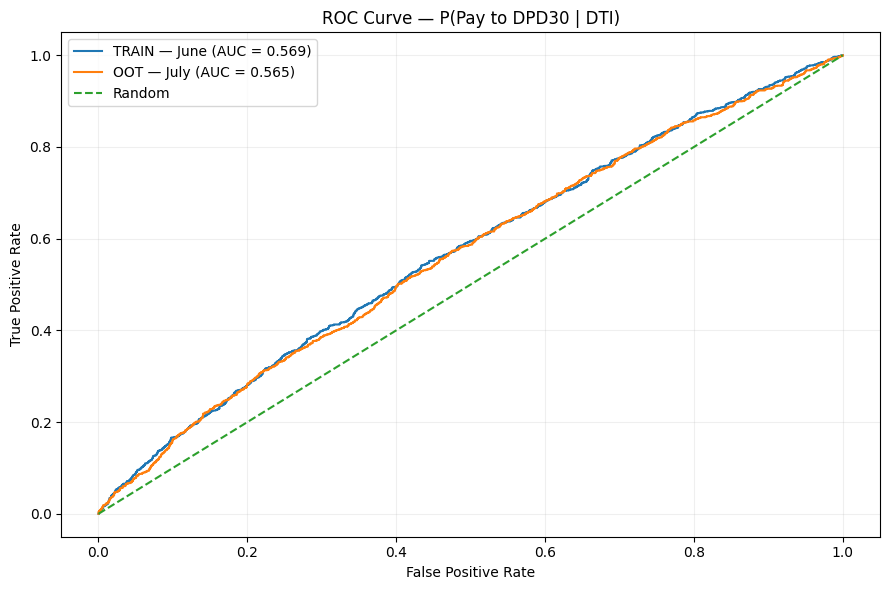

OOT KS
KS                  : 0.0987
KS population point : 44.21%


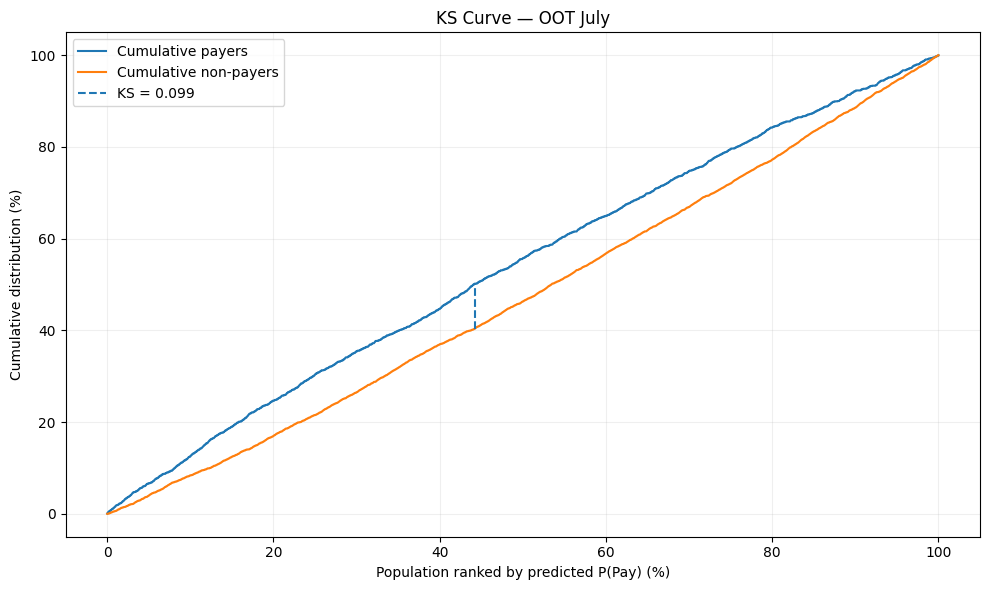


OOT — CUMULATIVE LIFT


,top_population_pct,payers_captured_pct,cumulative_lift
0,10.00,12.48,1.25
1,20.00,24.67,1.23
2,30.00,35.38,1.18
3,40.00,44.70,1.12
4,50.00,55.66,1.11
5,100.00,100.00,1.00


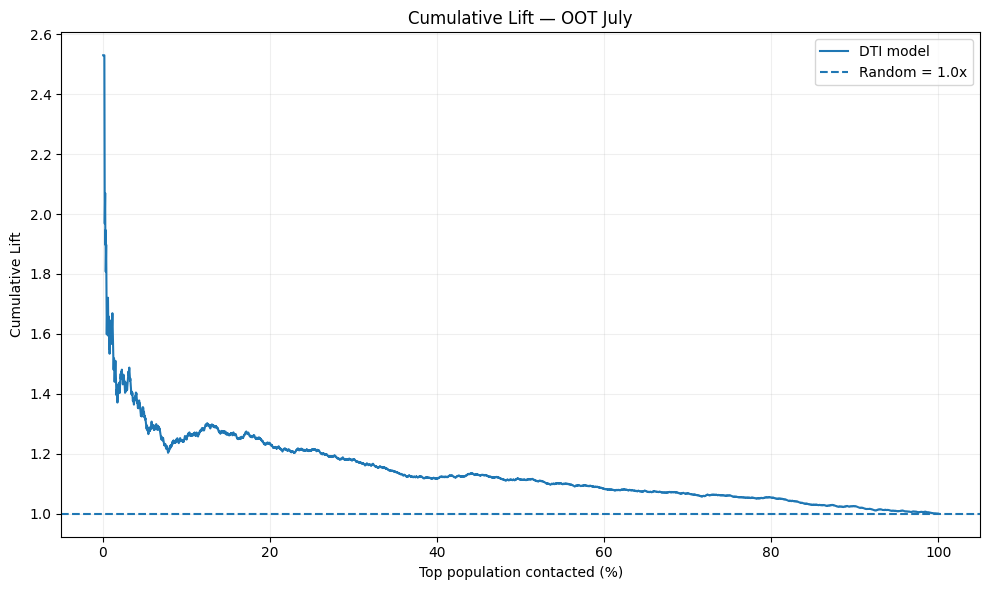


OOT MODEL SUMMARY
AUC : 0.5648
KS  : 0.0987

MODEL DIAGNOSTICS: PASS


In [88]:
# ============================================================
# MODEL 1 — DISCRIMINATION / RANKING CHARTS
# P(PAY TO DPD30 | DTI)
#
# Charts:
# 1. ROC Curve
# 2. KS Curve ("barriga de KS")
# 3. Lift Curve
#
# Primary evaluation = OOT July
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    roc_curve,
    roc_auc_score
)


# ============================================================
# CONFIG
# ============================================================

TARGET = "pay_to_dpd30"
SCORE = "p_pay_dti"


# ============================================================
# 1. ROC CURVE — TRAIN vs OOT
# ============================================================

fpr_train, tpr_train, _ = roc_curve(
    train[TARGET],
    train[SCORE]
)

fpr_oot, tpr_oot, _ = roc_curve(
    oot[TARGET],
    oot[SCORE]
)

auc_train = roc_auc_score(
    train[TARGET],
    train[SCORE]
)

auc_oot = roc_auc_score(
    oot[TARGET],
    oot[SCORE]
)


plt.figure(figsize=(9, 6))

plt.plot(
    fpr_train,
    tpr_train,
    label=f"TRAIN — June (AUC = {auc_train:.3f})"
)

plt.plot(
    fpr_oot,
    tpr_oot,
    label=f"OOT — July (AUC = {auc_oot:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title(
    "ROC Curve — P(Pay to DPD30 | DTI)"
)

plt.legend()
plt.grid(alpha=0.20)

plt.tight_layout()
plt.show()


# ============================================================
# 2. KS CURVE — OOT
#
# Sort customers from highest predicted probability
# to lowest predicted probability.
#
# Compare cumulative distributions:
# payers vs non-payers.
# ============================================================

ks_df = (
    oot[
        [
            "customer_id",
            TARGET,
            SCORE
        ]
    ]
    .sort_values(
        SCORE,
        ascending=False
    )
    .reset_index(drop=True)
)


# Population percentage
ks_df["population_pct"] = (
    np.arange(1, len(ks_df) + 1)
    /
    len(ks_df)
)


# Payer / non-payer flags
ks_df["payer"] = (
    ks_df[TARGET] == 1
).astype(int)

ks_df["nonpayer"] = (
    ks_df[TARGET] == 0
).astype(int)


# Cumulative distributions
ks_df["cum_payers_pct"] = (
    ks_df["payer"].cumsum()
    /
    ks_df["payer"].sum()
)

ks_df["cum_nonpayers_pct"] = (
    ks_df["nonpayer"].cumsum()
    /
    ks_df["nonpayer"].sum()
)


# KS distance
ks_df["ks_distance"] = (
    ks_df["cum_payers_pct"]
    -
    ks_df["cum_nonpayers_pct"]
)


ks_idx = (
    ks_df["ks_distance"]
    .abs()
    .idxmax()
)

ks_value = abs(
    ks_df.loc[
        ks_idx,
        "ks_distance"
    ]
)

ks_population = (
    ks_df.loc[
        ks_idx,
        "population_pct"
    ]
)


print("=" * 90)
print("OOT KS")
print("=" * 90)

print(
    f"KS                  : {ks_value:.4f}"
)

print(
    f"KS population point : {ks_population:.2%}"
)


# ------------------------------------------------------------
# KS PLOT
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

plt.plot(
    ks_df["population_pct"] * 100,
    ks_df["cum_payers_pct"] * 100,
    label="Cumulative payers"
)

plt.plot(
    ks_df["population_pct"] * 100,
    ks_df["cum_nonpayers_pct"] * 100,
    label="Cumulative non-payers"
)


# KS vertical distance
x_ks = ks_population * 100

y_nonpayer = (
    ks_df.loc[
        ks_idx,
        "cum_nonpayers_pct"
    ] * 100
)

y_payer = (
    ks_df.loc[
        ks_idx,
        "cum_payers_pct"
    ] * 100
)


plt.vlines(
    x=x_ks,
    ymin=min(y_nonpayer, y_payer),
    ymax=max(y_nonpayer, y_payer),
    linestyle="--",
    label=f"KS = {ks_value:.3f}"
)


plt.xlabel(
    "Population ranked by predicted P(Pay) (%)"
)

plt.ylabel(
    "Cumulative distribution (%)"
)

plt.title(
    "KS Curve — OOT July"
)

plt.legend()
plt.grid(alpha=0.20)

plt.tight_layout()
plt.show()


# ============================================================
# 3. LIFT CURVE — OOT
#
# Question:
# If I contact the top X% ranked by P(Pay),
# how much better am I than random targeting?
# ============================================================

lift_df = (
    oot[
        [
            "customer_id",
            TARGET,
            SCORE
        ]
    ]
    .sort_values(
        SCORE,
        ascending=False
    )
    .reset_index(drop=True)
)


lift_df["rank"] = (
    np.arange(1, len(lift_df) + 1)
)


lift_df["population_pct"] = (
    lift_df["rank"]
    /
    len(lift_df)
)


# cumulative payers captured
lift_df["cum_payers"] = (
    lift_df[TARGET]
    .cumsum()
)


total_payers = (
    lift_df[TARGET]
    .sum()
)


lift_df["cum_payer_capture"] = (
    lift_df["cum_payers"]
    /
    total_payers
)


# Random targeting would capture X% of payers
# by contacting X% of population.
lift_df["random_capture"] = (
    lift_df["population_pct"]
)


# Cumulative lift
lift_df["cumulative_lift"] = (
    lift_df["cum_payer_capture"]
    /
    lift_df["population_pct"]
)


# ------------------------------------------------------------
# LIFT TABLE AT BUSINESS CUTS
# ------------------------------------------------------------

cuts = [
    0.10,
    0.20,
    0.30,
    0.40,
    0.50,
    1.00
]


lift_summary = []


for cut in cuts:

    idx = int(
        np.ceil(
            len(lift_df) * cut
        )
    ) - 1

    row = lift_df.iloc[idx]

    lift_summary.append(
        {
            "top_population_pct":
                cut * 100,

            "payers_captured_pct":
                row["cum_payer_capture"] * 100,

            "cumulative_lift":
                row["cumulative_lift"]
        }
    )


lift_summary = pd.DataFrame(
    lift_summary
)


print()
print("=" * 90)
print("OOT — CUMULATIVE LIFT")
print("=" * 90)

display(lift_summary)


# ------------------------------------------------------------
# LIFT PLOT
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

plt.plot(
    lift_df["population_pct"] * 100,
    lift_df["cumulative_lift"],
    label="DTI model"
)

plt.axhline(
    y=1,
    linestyle="--",
    label="Random = 1.0x"
)

plt.xlabel(
    "Top population contacted (%)"
)

plt.ylabel(
    "Cumulative Lift"
)

plt.title(
    "Cumulative Lift — OOT July"
)

plt.legend()
plt.grid(alpha=0.20)

plt.tight_layout()
plt.show()


# ============================================================
# FINAL SUMMARY
# ============================================================

print()
print("=" * 90)
print("OOT MODEL SUMMARY")
print("=" * 90)

print(
    f"AUC : {auc_oot:.4f}"
)

print(
    f"KS  : {ks_value:.4f}"
)

print()
print("MODEL DIAGNOSTICS: PASS")

OOT JULY — OBSERVED vs PREDICTED + ERROR


,dti_decile,customers,median_DTI,observed_pct,predicted_pct,calibration_error_pp,absolute_error_pp
0,1,416,0.12,49.28,49.07,-0.21,0.21
1,2,415,0.17,48.19,46.80,-1.39,1.39
2,3,416,0.21,42.31,45.02,2.71,2.71
3,4,415,0.26,36.87,43.21,6.34,6.34
4,5,416,0.30,43.27,41.47,-1.80,1.80
5,6,415,0.34,36.87,39.69,2.82,2.82
6,7,415,0.39,38.55,37.85,-0.71,0.71
7,8,416,0.43,37.50,36.00,-1.50,1.50
8,9,415,0.48,31.33,34.19,2.86,2.86
9,10,416,0.55,31.01,30.96,-0.05,0.05


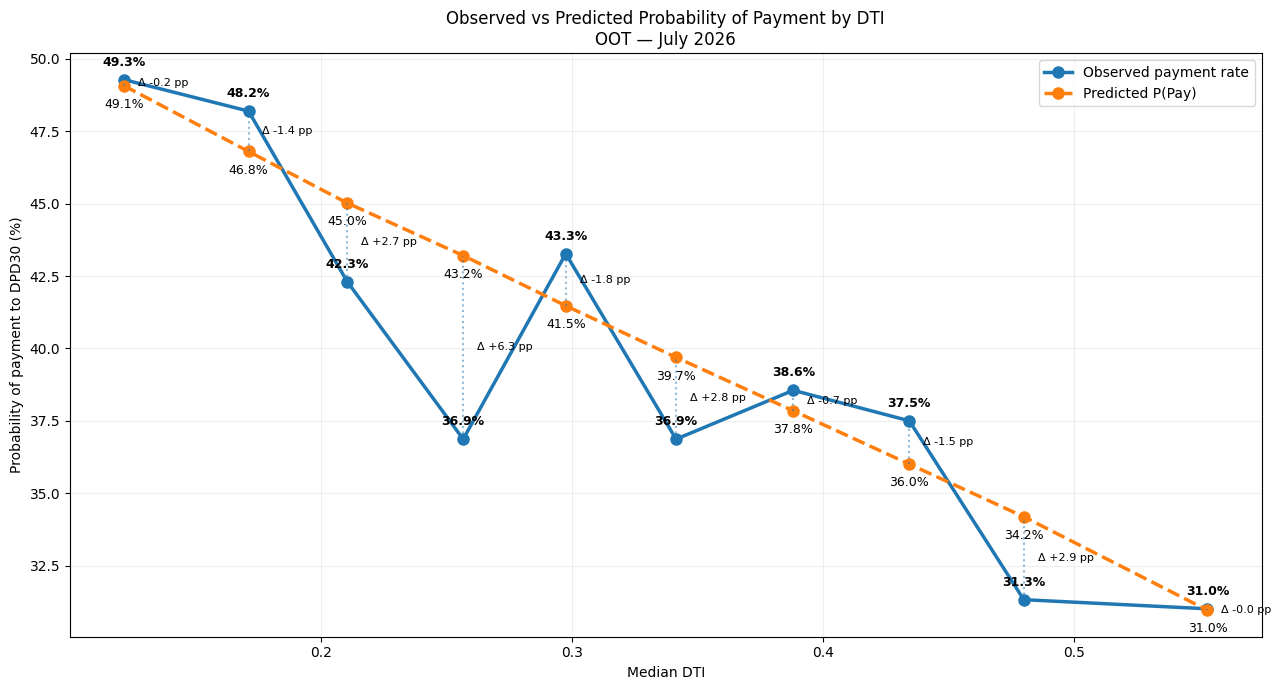


DECILE CALIBRATION ERROR — OOT
Mean absolute error : 2.04 pp
Maximum error       : 6.34 pp
Mean bias           : +0.91 pp


In [89]:
# ============================================================
# OOT JULY — OBSERVED vs PREDICTED + CALIBRATION ERROR
#
# Error = Predicted P(Pay) - Observed Payment Rate
#
# Positive error -> model overestimates payment
# Negative error -> model underestimates payment
# ============================================================

import matplotlib.pyplot as plt
import numpy as np


# ============================================================
# 1. CALIBRATION ERROR
# ============================================================

dti_curve["calibration_error_pp"] = (
    dti_curve["predicted_pct"]
    - dti_curve["observed_pct"]
)

dti_curve["absolute_error_pp"] = (
    dti_curve["calibration_error_pp"].abs()
)


print("=" * 100)
print("OOT JULY — OBSERVED vs PREDICTED + ERROR")
print("=" * 100)

display(
    dti_curve[
        [
            "dti_decile",
            "customers",
            "median_DTI",
            "observed_pct",
            "predicted_pct",
            "calibration_error_pp",
            "absolute_error_pp"
        ]
    ]
)


# ============================================================
# 2. GRAPH
# ============================================================

fig, ax = plt.subplots(figsize=(13, 7))


# ------------------------------------------------------------
# OBSERVED
# ------------------------------------------------------------

ax.plot(
    dti_curve["median_DTI"],
    dti_curve["observed_pct"],
    marker="o",
    linewidth=2.5,
    markersize=8,
    label="Observed payment rate"
)


# ------------------------------------------------------------
# PREDICTED
# ------------------------------------------------------------

ax.plot(
    dti_curve["median_DTI"],
    dti_curve["predicted_pct"],
    marker="o",
    linewidth=2.5,
    markersize=8,
    linestyle="--",
    label="Predicted P(Pay)"
)


# ============================================================
# 3. CONNECT OBSERVED AND PREDICTED
#    This visually represents the calibration error
# ============================================================

for _, row in dti_curve.iterrows():

    ax.vlines(
        x=row["median_DTI"],
        ymin=min(
            row["observed_pct"],
            row["predicted_pct"]
        ),
        ymax=max(
            row["observed_pct"],
            row["predicted_pct"]
        ),
        linestyle=":",
        alpha=0.5
    )


# ============================================================
# 4. OBSERVED LABEL
# ============================================================

for _, row in dti_curve.iterrows():

    ax.annotate(
        f"{row['observed_pct']:.1f}%",
        (
            row["median_DTI"],
            row["observed_pct"]
        ),
        textcoords="offset points",
        xytext=(0, 10),
        ha="center",
        fontsize=9,
        fontweight="bold"
    )


# ============================================================
# 5. PREDICTED LABEL
# ============================================================

for _, row in dti_curve.iterrows():

    ax.annotate(
        f"{row['predicted_pct']:.1f}%",
        (
            row["median_DTI"],
            row["predicted_pct"]
        ),
        textcoords="offset points",
        xytext=(0, -16),
        ha="center",
        fontsize=9
    )


# ============================================================
# 6. ERROR LABEL
#
# Midpoint between observed and predicted
# ============================================================

for _, row in dti_curve.iterrows():

    midpoint = (
        row["observed_pct"]
        + row["predicted_pct"]
    ) / 2

    error = row["calibration_error_pp"]

    sign = "+" if error > 0 else ""

    ax.annotate(
        f"Δ {sign}{error:.1f} pp",
        (
            row["median_DTI"],
            midpoint
        ),
        textcoords="offset points",
        xytext=(10, 0),
        ha="left",
        va="center",
        fontsize=8
    )


# ============================================================
# 7. FORMATTING
# ============================================================

ax.set_xlabel(
    "Median DTI"
)

ax.set_ylabel(
    "Probability of payment to DPD30 (%)"
)

ax.set_title(
    "Observed vs Predicted Probability of Payment by DTI\n"
    "OOT — July 2026"
)

ax.legend()

ax.grid(
    alpha=0.20
)

plt.tight_layout()
plt.show()


# ============================================================
# 8. GLOBAL CALIBRATION ERROR
# ============================================================

mae_decile = (
    dti_curve["absolute_error_pp"].mean()
)

max_error = (
    dti_curve["absolute_error_pp"].max()
)

bias = (
    dti_curve["calibration_error_pp"].mean()
)


print()
print("=" * 80)
print("DECILE CALIBRATION ERROR — OOT")
print("=" * 80)

print(
    f"Mean absolute error : {mae_decile:.2f} pp"
)

print(
    f"Maximum error       : {max_error:.2f} pp"
)

print(
    f"Mean bias           : {bias:+.2f} pp"
)

OOT JULY — PAYMENT BY PREDICTED PROBABILITY BAND


,probability_band,customers,payers,mean_predicted_probability_pct,observed_payment_rate_pct
0,30–35%,694,216,33.06,31.12
1,35–40%,1142,431,37.46,37.74
2,40–45%,1157,456,42.45,39.41
3,45–50%,989,468,47.15,47.32
4,50–55%,72,39,50.56,54.17
5,55–60%,0,0,NaN,NaN


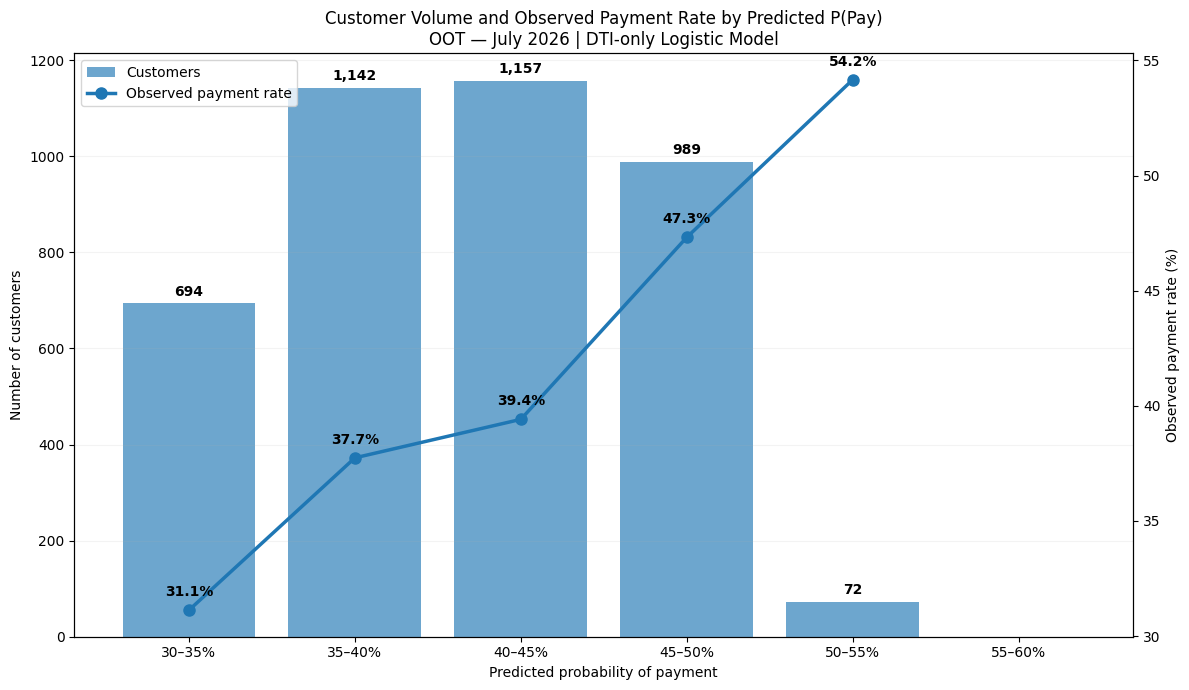

In [90]:
# ============================================================
# PAYMENT RATE BY PREDICTED PROBABILITY BAND — OOT JULY
#
# X    = Predicted P(Pay), bands of 5pp from 30% to 60%
# BAR  = Number of customers
# LINE = Observed payment rate
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


TARGET = "pay_to_dpd30"
SCORE = "p_pay_dti"


# ============================================================
# 1. BASE
# ============================================================

plot_df = oot[
    [
        "customer_id",
        SCORE,
        TARGET
    ]
].copy()


# ============================================================
# 2. PROBABILITY BANDS — 5pp
# ============================================================

bins = [
    0.30,
    0.35,
    0.40,
    0.45,
    0.50,
    0.55,
    0.60
]

labels = [
    "30–35%",
    "35–40%",
    "40–45%",
    "45–50%",
    "50–55%",
    "55–60%"
]


plot_df["probability_band"] = pd.cut(
    plot_df[SCORE],
    bins=bins,
    labels=labels,
    include_lowest=True,
    right=False
)


# ============================================================
# 3. AGGREGATION
# ============================================================

probability_summary_5pp = (
    plot_df
    .dropna(subset=["probability_band"])
    .groupby(
        "probability_band",
        observed=False
    )
    .agg(
        customers=(
            "customer_id",
            "nunique"
        ),

        payers=(
            TARGET,
            "sum"
        ),

        mean_predicted_probability=(
            SCORE,
            "mean"
        ),

        observed_payment_rate=(
            TARGET,
            "mean"
        )
    )
    .reset_index()
)


probability_summary_5pp["observed_payment_rate_pct"] = (
    probability_summary_5pp["observed_payment_rate"]
    * 100
)

probability_summary_5pp["mean_predicted_probability_pct"] = (
    probability_summary_5pp["mean_predicted_probability"]
    * 100
)


# ============================================================
# 4. TABLE
# ============================================================

print("=" * 100)
print("OOT JULY — PAYMENT BY PREDICTED PROBABILITY BAND")
print("=" * 100)

display(
    probability_summary_5pp[
        [
            "probability_band",
            "customers",
            "payers",
            "mean_predicted_probability_pct",
            "observed_payment_rate_pct"
        ]
    ]
)


# ============================================================
# 5. CHART
# ============================================================

fig, ax1 = plt.subplots(
    figsize=(12, 7)
)

x = np.arange(
    len(probability_summary_5pp)
)


# ============================================================
# BARS — CUSTOMER VOLUME
# ============================================================

bars = ax1.bar(
    x,
    probability_summary_5pp["customers"],
    alpha=0.65,
    label="Customers"
)

ax1.set_xlabel(
    "Predicted probability of payment"
)

ax1.set_ylabel(
    "Number of customers"
)

ax1.set_xticks(x)

ax1.set_xticklabels(
    probability_summary_5pp["probability_band"]
)


# ============================================================
# CUSTOMER LABELS
# ============================================================

for bar, n in zip(
    bars,
    probability_summary_5pp["customers"]
):

    if n > 0:

        ax1.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 10,
            f"{int(n):,}",
            ha="center",
            va="bottom",
            fontsize=10,
            fontweight="bold"
        )


# ============================================================
# LINE — OBSERVED PAYMENT RATE
# ============================================================

ax2 = ax1.twinx()

ax2.plot(
    x,
    probability_summary_5pp["observed_payment_rate_pct"],
    marker="o",
    linewidth=2.5,
    markersize=8,
    label="Observed payment rate"
)

ax2.set_ylabel(
    "Observed payment rate (%)"
)


# ============================================================
# PAYMENT RATE LABELS
# ============================================================

for i, row in probability_summary_5pp.iterrows():

    if row["customers"] > 0:

        ax2.annotate(
            f"{row['observed_payment_rate_pct']:.1f}%",
            (
                i,
                row["observed_payment_rate_pct"]
            ),
            textcoords="offset points",
            xytext=(0, 10),
            ha="center",
            fontsize=10,
            fontweight="bold"
        )


# ============================================================
# TITLE
# ============================================================

plt.title(
    "Customer Volume and Observed Payment Rate by Predicted P(Pay)\n"
    "OOT — July 2026 | DTI-only Logistic Model"
)


# ============================================================
# LEGEND
# ============================================================

h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()

ax1.legend(
    h1 + h2,
    l1 + l2,
    loc="upper left"
)

ax1.grid(
    axis="y",
    alpha=0.15
)

plt.tight_layout()
plt.show()

In [91]:
# ============================================================
# STAGE 2 — CONDITIONAL EXPECTED RECOVERY
#
# Target:
# E[Recovery to DPD30 | Pay > 0, X]
#
# Population:
# PAYERS ONLY
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# 1. PAYERS ONLY
# ============================================================

recovery_df = base_dpd30[
    base_dpd30["recovery_to_dpd30_brl"] > 0
].copy()


print("=" * 90)
print("STAGE 2 — CONDITIONAL RECOVERY POPULATION")
print("=" * 90)

print(f"Customers : {len(recovery_df):,}")

print(
    f"Recovery mean   : "
    f"R$ {recovery_df['recovery_to_dpd30_brl'].mean():,.2f}"
)

print(
    f"Recovery median : "
    f"R$ {recovery_df['recovery_to_dpd30_brl'].median():,.2f}"
)

print()


# ============================================================
# 2. DTI DECILES
# ============================================================

recovery_df["dti_decile"] = (
    pd.qcut(
        recovery_df["DTI"],
        q=10,
        labels=False,
        duplicates="drop"
    )
    + 1
)


# ============================================================
# 3. SUMMARY
# ============================================================

recovery_dti_summary = (
    recovery_df
    .groupby(
        "dti_decile",
        as_index=False
    )
    .agg(
        customers=(
            "customer_id",
            "nunique"
        ),

        min_DTI=(
            "DTI",
            "min"
        ),

        median_DTI=(
            "DTI",
            "median"
        ),

        max_DTI=(
            "DTI",
            "max"
        ),

        median_balance=(
            "outstanding_balance_brl",
            "median"
        ),

        mean_recovery=(
            "recovery_to_dpd30_brl",
            "mean"
        ),

        median_recovery=(
            "recovery_to_dpd30_brl",
            "median"
        )
    )
)


display(recovery_dti_summary)

STAGE 2 — CONDITIONAL RECOVERY POPULATION
Customers : 3,319
Recovery mean   : R$ 699.06
Recovery median : R$ 570.04



,dti_decile,customers,min_DTI,median_DTI,max_DTI,median_balance,mean_recovery,median_recovery
0,1,332,0.06,0.11,0.14,266.92,293.13,250.83
1,2,332,0.14,0.16,0.18,332.07,366.15,282.75
2,3,332,0.18,0.19,0.21,406.71,396.09,310.47
3,4,332,0.21,0.23,0.25,569.16,584.53,487.33
4,5,332,0.25,0.27,0.29,664.48,667.67,589.62
5,6,331,0.29,0.31,0.34,791.28,760.94,671.09
6,7,332,0.34,0.36,0.39,852.31,848.08,768.23
7,8,332,0.39,0.41,0.43,"1,045.81",960.81,903.60
8,9,332,0.43,0.46,0.50,"1,146.99","1,049.33",978.10
9,10,332,0.50,0.54,0.78,"1,192.94","1,064.05",993.55


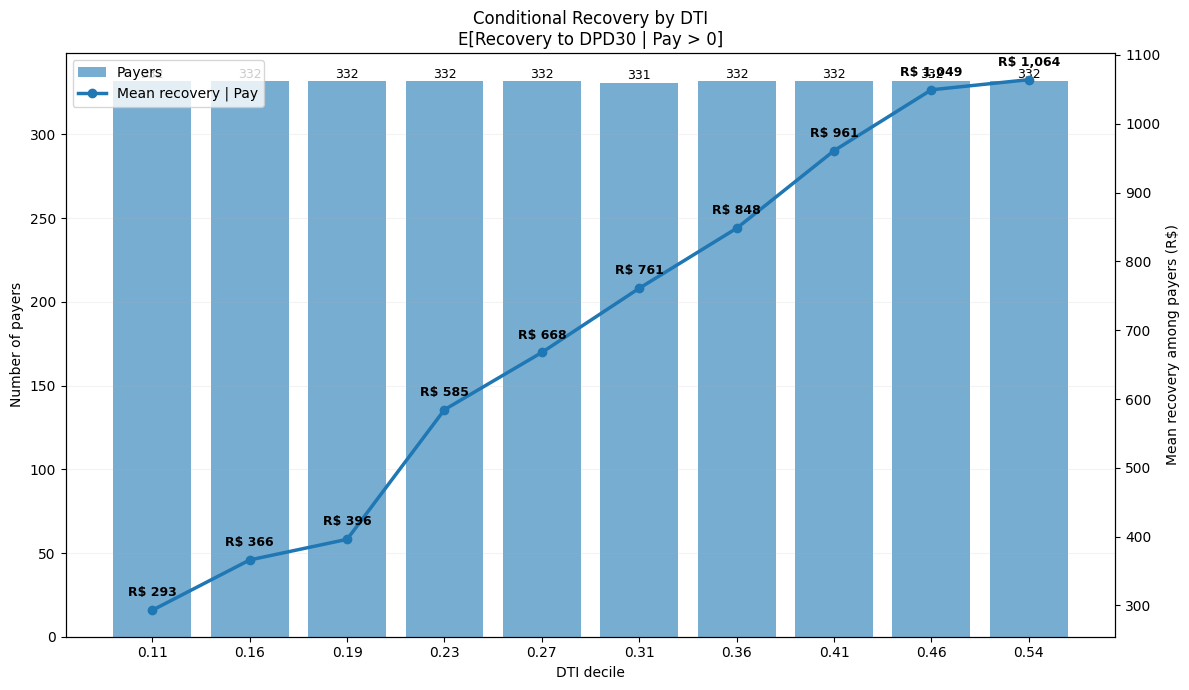

In [92]:
# ============================================================
# CONDITIONAL RECOVERY BY DTI DECILE
# ============================================================

fig, ax1 = plt.subplots(
    figsize=(12, 7)
)

x = np.arange(
    len(recovery_dti_summary)
)


# ============================================================
# BARS — CUSTOMERS
# ============================================================

bars = ax1.bar(
    x,
    recovery_dti_summary["customers"],
    alpha=0.60,
    label="Payers"
)

ax1.set_ylabel(
    "Number of payers"
)

ax1.set_xlabel(
    "DTI decile"
)

ax1.set_xticks(x)

ax1.set_xticklabels(
    [
        f"{x:.2f}"
        for x in recovery_dti_summary["median_DTI"]
    ]
)


for bar, n in zip(
    bars,
    recovery_dti_summary["customers"]
):

    ax1.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 2,
        f"{int(n):,}",
        ha="center",
        fontsize=9
    )


# ============================================================
# LINE — MEAN CONDITIONAL RECOVERY
# ============================================================

ax2 = ax1.twinx()

ax2.plot(
    x,
    recovery_dti_summary["mean_recovery"],
    marker="o",
    linewidth=2.5,
    label="Mean recovery | Pay"
)

ax2.set_ylabel(
    "Mean recovery among payers (R$)"
)


# ============================================================
# LABELS
# ============================================================

for i, row in recovery_dti_summary.iterrows():

    ax2.annotate(
        f"R$ {row['mean_recovery']:,.0f}",
        (
            i,
            row["mean_recovery"]
        ),
        textcoords="offset points",
        xytext=(0, 10),
        ha="center",
        fontsize=9,
        fontweight="bold"
    )


# ============================================================
# TITLE
# ============================================================

plt.title(
    "Conditional Recovery by DTI\n"
    "E[Recovery to DPD30 | Pay > 0]"
)


h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()

ax1.legend(
    h1 + h2,
    l1 + l2,
    loc="upper left"
)

ax1.grid(
    axis="y",
    alpha=0.15
)

plt.tight_layout()
plt.show()

In [93]:
recovery_df["recovery_rate"] = (
    recovery_df["recovery_to_dpd30_brl"]
    / recovery_df["outstanding_balance_brl"]
)

recovery_rate_dti = (
    recovery_df
    .groupby(
        "dti_decile",
        as_index=False
    )
    .agg(
        customers=("customer_id", "nunique"),

        median_DTI=("DTI", "median"),

        median_balance=(
            "outstanding_balance_brl",
            "median"
        ),

        mean_recovery=(
            "recovery_to_dpd30_brl",
            "mean"
        ),

        mean_recovery_rate=(
            "recovery_rate",
            "mean"
        ),

        median_recovery_rate=(
            "recovery_rate",
            "median"
        )
    )
)

recovery_rate_dti["mean_recovery_rate_pct"] = (
    recovery_rate_dti["mean_recovery_rate"] * 100
)

recovery_rate_dti["median_recovery_rate_pct"] = (
    recovery_rate_dti["median_recovery_rate"] * 100
)

display(
    recovery_rate_dti[
        [
            "dti_decile",
            "customers",
            "median_DTI",
            "median_balance",
            "mean_recovery",
            "mean_recovery_rate_pct",
            "median_recovery_rate_pct"
        ]
    ]
)

,dti_decile,customers,median_DTI,median_balance,mean_recovery,mean_recovery_rate_pct,median_recovery_rate_pct
0,1,332,0.11,266.92,293.13,87.51,100.00
1,2,332,0.16,332.07,366.15,89.26,100.00
2,3,332,0.19,406.71,396.09,86.05,100.00
3,4,332,0.23,569.16,584.53,87.29,100.00
4,5,332,0.27,664.48,667.67,86.56,100.00
5,6,331,0.31,791.28,760.94,86.48,100.00
6,7,332,0.36,852.31,848.08,87.12,100.00
7,8,332,0.41,"1,045.81",960.81,86.08,100.00
8,9,332,0.46,"1,146.99","1,049.33",85.48,100.00
9,10,332,0.54,"1,192.94","1,064.05",85.28,100.00


DTI alto significa que, dado que pagou, ele recupera uma proporção maior da dívida? Ou simplesmente recupera mais R$ porque devia mais?

ECONOMIC PRIORITY SCORE — OOT JULY
Customers       : 4,155
Actual recovery : R$ 1,133,207.55
Mean score      : R$ 324.46
Median score    : R$ 286.17

RANKING PERFORMANCE BY DECILE
Decile 1 = Highest P(Pay) × Balance


,rank_decile,customers,mean_p_pay,mean_balance,payment_rate_pct,actual_recovery,recovery_per_customer,recovery_share_pct,cumulative_recovery_pct,cumulative_lift
0,1,416,0.38,"1,830.77",38.70,"252,875.13",607.87,22.31,22.31,2.23
1,2,415,0.37,"1,373.54",33.73,"163,555.22",394.11,14.43,36.75,1.84
2,3,416,0.38,"1,130.18",40.14,"161,160.87",387.41,14.22,50.97,1.70
3,4,415,0.39,936.11,36.39,"114,093.37",274.92,10.07,61.04,1.53
4,5,416,0.39,801.10,35.58,"101,564.74",244.15,8.96,70.00,1.40
5,6,415,0.40,684.88,40.72,"96,720.09",233.06,8.54,78.54,1.31
6,7,415,0.40,585.92,35.18,"73,312.73",176.66,6.47,85.00,1.21
7,8,416,0.42,480.01,41.11,"67,279.97",161.73,5.94,90.94,1.14
8,9,415,0.45,349.32,44.82,"56,908.40",137.13,5.02,95.96,1.07
9,10,416,0.47,253.50,48.80,"45,737.03",109.94,4.04,100.00,1.00



TOP-K RECOVERY CAPTURE


,rank_decile,customers_contacted_pct,recovery_captured_pct,lift_vs_random
0,1,10.01,22.31,2.23
1,2,20.00,36.75,1.84
2,3,30.01,50.97,1.70
3,4,40.00,61.04,1.53
4,5,50.01,70.00,1.40
5,6,60.00,78.54,1.31
6,7,69.99,85.00,1.21
7,8,80.00,90.94,1.14
8,9,89.99,95.96,1.07
9,10,100.00,100.00,1.00


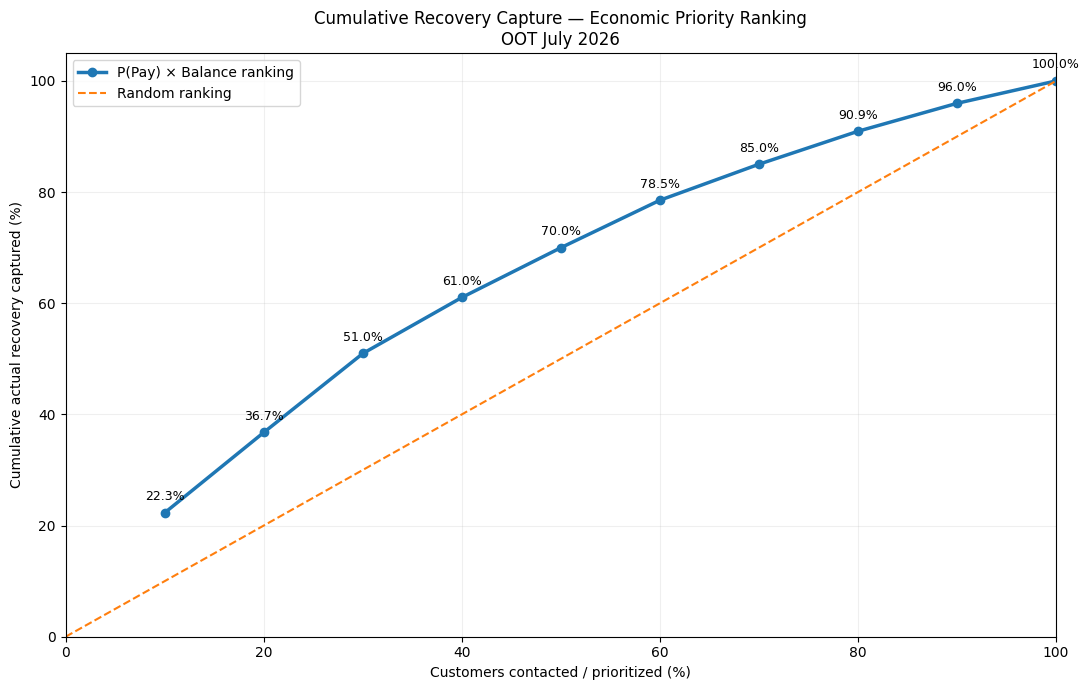

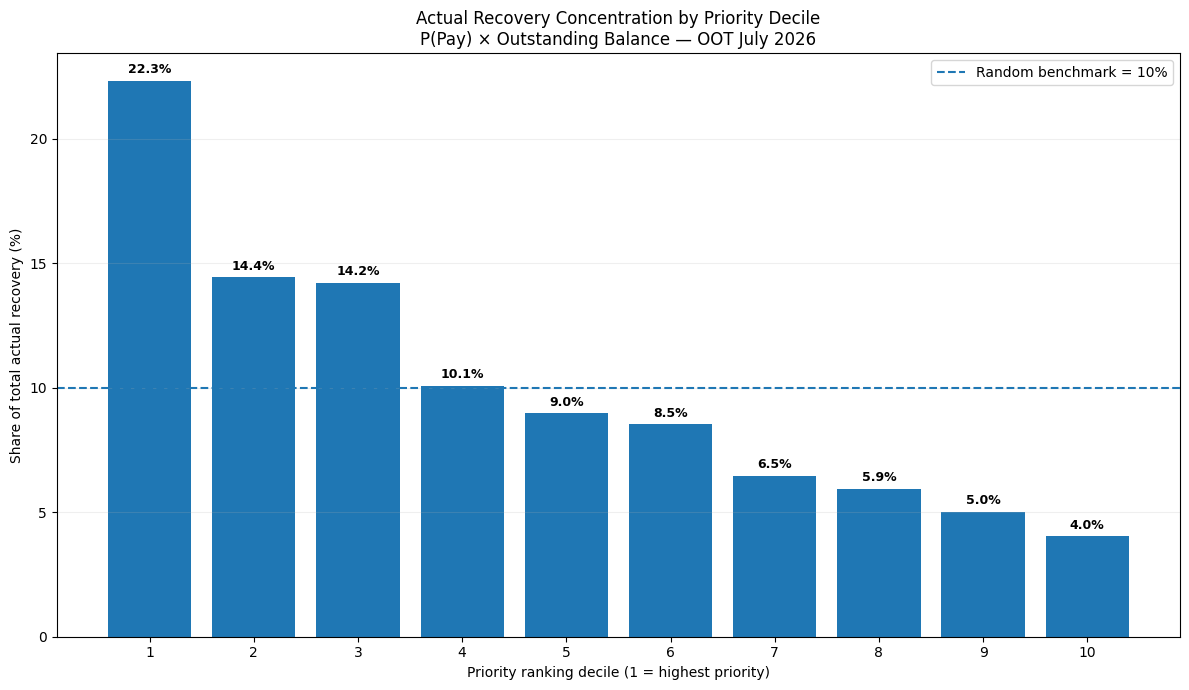

In [94]:
# ============================================================
# ECONOMIC PRIORITY RANKING — OOT JULY
#
# Priority Score = P(Pay | DTI) × Outstanding Balance
#
# Goal:
# Does the score concentrate ACTUAL recovery at the top?
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# 1. BUILD ECONOMIC SCORE
# ============================================================

rank_oot = oot.copy()

rank_oot["priority_score"] = (
    rank_oot["p_pay_dti"]
    * rank_oot["outstanding_balance_brl"]
)


# ============================================================
# 2. BASIC VALIDATIONS
# ============================================================

assert rank_oot["customer_id"].is_unique
assert rank_oot["priority_score"].notna().all()
assert (rank_oot["priority_score"] >= 0).all()
assert (rank_oot["recovery_to_dpd30_brl"] >= 0).all()

print("=" * 90)
print("ECONOMIC PRIORITY SCORE — OOT JULY")
print("=" * 90)

print(f"Customers       : {len(rank_oot):,}")
print(
    f"Actual recovery : "
    f"R$ {rank_oot['recovery_to_dpd30_brl'].sum():,.2f}"
)

print(
    f"Mean score      : "
    f"R$ {rank_oot['priority_score'].mean():,.2f}"
)

print(
    f"Median score    : "
    f"R$ {rank_oot['priority_score'].median():,.2f}"
)


# ============================================================
# 3. SORT BY ECONOMIC SCORE
# ============================================================

rank_oot = (
    rank_oot
    .sort_values(
        "priority_score",
        ascending=False
    )
    .reset_index(drop=True)
)


# ============================================================
# 4. CREATE 10 EQUAL-POPULATION RANKING DECILES
#
# Decile 1 = highest priority
# Decile 10 = lowest priority
# ============================================================

rank_oot["rank_decile"] = (
    pd.qcut(
        np.arange(len(rank_oot)),
        q=10,
        labels=False
    )
    + 1
)


# ============================================================
# 5. DECILE PERFORMANCE
# ============================================================

ranking_summary = (
    rank_oot
    .groupby(
        "rank_decile",
        as_index=False
    )
    .agg(
        customers=("customer_id", "nunique"),

        mean_priority_score=(
            "priority_score",
            "mean"
        ),

        mean_p_pay=(
            "p_pay_dti",
            "mean"
        ),

        mean_balance=(
            "outstanding_balance_brl",
            "mean"
        ),

        payers=(
            "pay_to_dpd30",
            "sum"
        ),

        actual_recovery=(
            "recovery_to_dpd30_brl",
            "sum"
        )
    )
)


# ============================================================
# 6. DERIVED METRICS
# ============================================================

ranking_summary["payment_rate_pct"] = (
    ranking_summary["payers"]
    / ranking_summary["customers"]
    * 100
)

ranking_summary["recovery_per_customer"] = (
    ranking_summary["actual_recovery"]
    / ranking_summary["customers"]
)

TOTAL_RECOVERY = (
    ranking_summary["actual_recovery"].sum()
)

ranking_summary["recovery_share_pct"] = (
    ranking_summary["actual_recovery"]
    / TOTAL_RECOVERY
    * 100
)

ranking_summary["cumulative_recovery_pct"] = (
    ranking_summary["recovery_share_pct"]
    .cumsum()
)

ranking_summary["cumulative_customers_pct"] = (
    ranking_summary["customers"]
    .cumsum()
    / ranking_summary["customers"].sum()
    * 100
)


# Random benchmark:
# top 10% customers -> 10% recovery
ranking_summary["random_recovery_pct"] = (
    ranking_summary["cumulative_customers_pct"]
)


# ============================================================
# 7. LIFT VS RANDOM
# ============================================================

ranking_summary["cumulative_lift"] = (
    ranking_summary["cumulative_recovery_pct"]
    / ranking_summary["cumulative_customers_pct"]
)


# ============================================================
# 8. DISPLAY
# ============================================================

print()
print("=" * 120)
print("RANKING PERFORMANCE BY DECILE")
print("Decile 1 = Highest P(Pay) × Balance")
print("=" * 120)

display(
    ranking_summary[
        [
            "rank_decile",
            "customers",
            "mean_p_pay",
            "mean_balance",
            "payment_rate_pct",
            "actual_recovery",
            "recovery_per_customer",
            "recovery_share_pct",
            "cumulative_recovery_pct",
            "cumulative_lift"
        ]
    ].round(2)
)


# ============================================================
# 9. TOP-K SUMMARY
# ============================================================

top_k = ranking_summary[
    [
        "rank_decile",
        "cumulative_customers_pct",
        "cumulative_recovery_pct",
        "cumulative_lift"
    ]
].copy()

top_k = top_k.rename(
    columns={
        "cumulative_customers_pct": "customers_contacted_pct",
        "cumulative_recovery_pct": "recovery_captured_pct",
        "cumulative_lift": "lift_vs_random"
    }
)

print()
print("=" * 90)
print("TOP-K RECOVERY CAPTURE")
print("=" * 90)

display(top_k.round(2))


# ============================================================
# 10. CUMULATIVE RECOVERY CAPTURE CURVE
# ============================================================

fig, ax = plt.subplots(
    figsize=(11, 7)
)


# MODEL
ax.plot(
    ranking_summary["cumulative_customers_pct"],
    ranking_summary["cumulative_recovery_pct"],
    marker="o",
    linewidth=2.5,
    label="P(Pay) × Balance ranking"
)


# RANDOM
ax.plot(
    [0, 100],
    [0, 100],
    linestyle="--",
    linewidth=1.5,
    label="Random ranking"
)


# ============================================================
# LABEL TOP-K POINTS
# ============================================================

for _, row in ranking_summary.iterrows():

    ax.annotate(
        f"{row['cumulative_recovery_pct']:.1f}%",
        (
            row["cumulative_customers_pct"],
            row["cumulative_recovery_pct"]
        ),
        textcoords="offset points",
        xytext=(0, 9),
        ha="center",
        fontsize=9
    )


ax.set_xlabel(
    "Customers contacted / prioritized (%)"
)

ax.set_ylabel(
    "Cumulative actual recovery captured (%)"
)

ax.set_title(
    "Cumulative Recovery Capture — Economic Priority Ranking\n"
    "OOT July 2026"
)

ax.set_xlim(0, 100)
ax.set_ylim(0, 105)

ax.legend()
ax.grid(alpha=0.20)

plt.tight_layout()
plt.show()


# ============================================================
# 11. RECOVERY BY RANKING DECILE
# ============================================================

fig, ax = plt.subplots(
    figsize=(12, 7)
)

bars = ax.bar(
    ranking_summary["rank_decile"].astype(str),
    ranking_summary["recovery_share_pct"]
)


for bar, value in zip(
    bars,
    ranking_summary["recovery_share_pct"]
):

    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.3,
        f"{value:.1f}%",
        ha="center",
        fontsize=9,
        fontweight="bold"
    )


ax.axhline(
    y=10,
    linestyle="--",
    linewidth=1.5,
    label="Random benchmark = 10%"
)

ax.set_xlabel(
    "Priority ranking decile (1 = highest priority)"
)

ax.set_ylabel(
    "Share of total actual recovery (%)"
)

ax.set_title(
    "Actual Recovery Concentration by Priority Decile\n"
    "P(Pay) × Outstanding Balance — OOT July 2026"
)

ax.legend()
ax.grid(
    axis="y",
    alpha=0.20
)

plt.tight_layout()
plt.show()

30% dos clientes concentram 51% de toda a recuperação observada.  
Para capturar aproximadamente metade do recovery potencial, o ranking concentra ~51% da recuperação nos primeiros 30%.

Chance de 38% sobre R$1831     

Chance de 47% sobre R$254  

E economicamente isso faz sentido para maximização de R$ recuperados


Modelo : DTI + outstanding balance + uf + age

In [95]:
# ============================================================
# PAYMENT MODEL — OPTIMAL BINNING + WOE + LOGISTIC REGRESSION
#
# TARGET:
#   1 = ANY PAYMENT > R$0 até DPD30
#   0 = ZERO recovery até DPD30
#
# TRAIN = June 2026
# OOT   = July 2026
#
# Features:
#   - DTI at score
#   - Outstanding balance at score
#   - Account age
#   - UF
#
# IMPORTANT:
# - Optimal binning learned ONLY on TRAIN
# - WoE learned ONLY on TRAIN
# - OOT completely untouched
# ============================================================

import pandas as pd
import numpy as np

from optbinning import OptimalBinning

from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    accuracy_score,
    precision_score,
    recall_score,
    confusion_matrix,
    roc_curve
)


# ============================================================
# 1. TARGET
# ============================================================

TARGET = "pay_to_dpd30"

model_base[TARGET] = (
    model_base["recovery_to_dpd30_brl"] > 0
).astype(int)


# ============================================================
# 2. FEATURES
# ============================================================

NUMERIC_FEATURES = [
    "dti_at_score",
    "balance_at_score",
    "account_age_months"
]

CATEGORICAL_FEATURES = [
    "state_uf"
]


# ============================================================
# 3. TEMPORAL SPLIT
# ============================================================

dev = model_base.copy()

dev["score_month"] = (
    pd.to_datetime(dev["score_at"])
    .dt.to_period("M")
    .astype(str)
)


train = dev[
    dev["score_month"] == "2026-06"
].copy()


oot = dev[
    dev["score_month"] == "2026-07"
].copy()


print("=" * 100)
print("TEMPORAL SPLIT")
print("=" * 100)

print(
    f"TRAIN : {len(train):,} | "
    f"Payment rate = {train[TARGET].mean():.2%}"
)

print(
    f"OOT   : {len(oot):,} | "
    f"Payment rate = {oot[TARGET].mean():.2%}"
)


# ============================================================
# 4. OPTIMAL BINNING
#
# IMPORTANT:
# Target is now PAYMENT.
#
# DTI:
# Higher DTI historically -> LOWER payment probability.
# Therefore monotonic trend = descending.
#
# Balance:
# no monotonic restriction.
#
# Account age:
# non-monotonic / U-shaped behavior.
# ============================================================

binning_models_pay = {}


# ------------------------------------------------------------
# DTI
# ------------------------------------------------------------

binning_models_pay["dti_at_score"] = OptimalBinning(
    name="dti_at_score",
    dtype="numerical",
    solver="cp",

    # Higher DTI -> lower payment rate
    monotonic_trend="descending",

    min_bin_size=0.05,
    max_n_bins=6
)


# ------------------------------------------------------------
# BALANCE
# ------------------------------------------------------------

binning_models_pay["balance_at_score"] = OptimalBinning(
    name="balance_at_score",
    dtype="numerical",
    solver="cp",

    monotonic_trend=None,

    min_bin_size=0.05,
    max_n_bins=6
)


# ------------------------------------------------------------
# ACCOUNT AGE
# ------------------------------------------------------------

binning_models_pay["account_age_months"] = OptimalBinning(
    name="account_age_months",
    dtype="numerical",
    solver="cp",

    # Non-monotonic relationship
    monotonic_trend=None,

    min_bin_size=0.05,
    max_n_bins=6
)


# ============================================================
# 5. FIT BINNING — TRAIN ONLY
# ============================================================

y_train = (
    train[TARGET]
    .astype(int)
    .values
)


for variable in NUMERIC_FEATURES:

    print()
    print("=" * 100)
    print(
        f"FITTING OPTIMAL BINNING — "
        f"{variable.upper()}"
    )
    print("=" * 100)

    x_train = (
        train[variable]
        .astype(float)
        .values
    )

    binning_models_pay[
        variable
    ].fit(
        x_train,
        y_train
    )

    print(
        "Status:",
        binning_models_pay[
            variable
        ].status
    )

    print(
        "Splits:",
        binning_models_pay[
            variable
        ].splits
    )


# ============================================================
# 6. BINNING TABLES
# ============================================================

binning_tables_pay = {}


for variable in NUMERIC_FEATURES:

    print()
    print("=" * 120)
    print(
        f"OPTIMAL BINNING TABLE — "
        f"{variable.upper()}"
    )
    print("=" * 120)

    table = (
        binning_models_pay[
            variable
        ]
        .binning_table
        .build()
    )

    binning_tables_pay[
        variable
    ] = table

    print(
        table.to_string()
    )


# ============================================================
# 7. INFORMATION VALUE
# ============================================================

iv_rows = []


for variable in NUMERIC_FEATURES:

    iv = (
        binning_models_pay[
            variable
        ]
        .binning_table
        .iv
    )

    iv_rows.append({
        "feature": variable,
        "iv": iv
    })


iv_table_pay = (
    pd.DataFrame(iv_rows)
    .sort_values(
        "iv",
        ascending=False
    )
)


print()
print("=" * 100)
print("INFORMATION VALUE — TRAIN")
print("=" * 100)

print(
    iv_table_pay.to_string(
        index=False,
        formatters={
            "iv": lambda x: f"{x:.4f}"
        }
    )
)


# ============================================================
# 8. WOE TRANSFORMATION
#
# Learned on TRAIN.
# Same mapping applied to OOT.
# ============================================================

train_woe = pd.DataFrame(
    index=train.index
)

oot_woe = pd.DataFrame(
    index=oot.index
)


for variable in NUMERIC_FEATURES:

    train_woe[
        f"{variable}_woe"
    ] = (
        binning_models_pay[
            variable
        ]
        .transform(
            train[variable].values,
            metric="woe"
        )
    )


    oot_woe[
        f"{variable}_woe"
    ] = (
        binning_models_pay[
            variable
        ]
        .transform(
            oot[variable].values,
            metric="woe"
        )
    )


# ============================================================
# 9. SAVE BIN LABELS FOR AUDIT
# ============================================================

for variable in NUMERIC_FEATURES:

    train_woe[
        f"{variable}_bin"
    ] = (
        binning_models_pay[
            variable
        ]
        .transform(
            train[variable].values,
            metric="bins"
        )
    )


    oot_woe[
        f"{variable}_bin"
    ] = (
        binning_models_pay[
            variable
        ]
        .transform(
            oot[variable].values,
            metric="bins"
        )
    )


# ============================================================
# 10. UF — ONE HOT ENCODING
# ============================================================

uf_encoder_pay = OneHotEncoder(
    handle_unknown="ignore",
    drop="first",
    sparse_output=False
)


train_uf = uf_encoder_pay.fit_transform(
    train[
        CATEGORICAL_FEATURES
    ]
)


oot_uf = uf_encoder_pay.transform(
    oot[
        CATEGORICAL_FEATURES
    ]
)


uf_names = (
    uf_encoder_pay
    .get_feature_names_out(
        CATEGORICAL_FEATURES
    )
)


train_uf = pd.DataFrame(
    train_uf,
    columns=uf_names,
    index=train.index
)


oot_uf = pd.DataFrame(
    oot_uf,
    columns=uf_names,
    index=oot.index
)


# ============================================================
# 11. FINAL MODEL MATRIX
# ============================================================

WOE_FEATURES = [
    f"{variable}_woe"
    for variable in NUMERIC_FEATURES
]


X_train = pd.concat(
    [
        train_woe[
            WOE_FEATURES
        ],
        train_uf
    ],
    axis=1
)


X_oot = pd.concat(
    [
        oot_woe[
            WOE_FEATURES
        ],
        oot_uf
    ],
    axis=1
)


y_train = train[TARGET]
y_oot = oot[TARGET]


print()
print("=" * 100)
print("FINAL MODEL MATRIX")
print("=" * 100)

print(
    f"TRAIN shape : {X_train.shape}"
)

print(
    f"OOT shape   : {X_oot.shape}"
)

print(
    f"Features    : {X_train.shape[1]}"
)


# ============================================================
# 12. LOGISTIC REGRESSION
# ============================================================

model_pay_optbin = LogisticRegression(
    max_iter=2000
)


model_pay_optbin.fit(
    X_train,
    y_train
)


# ============================================================
# 13. PREDICTIONS
# ============================================================

train["p_pay"] = (
    model_pay_optbin
    .predict_proba(
        X_train
    )[:, 1]
)


oot["p_pay"] = (
    model_pay_optbin
    .predict_proba(
        X_oot
    )[:, 1]
)


p = oot["p_pay"]


# ============================================================
# 14. OOT PERFORMANCE
# ============================================================

roc_auc = roc_auc_score(
    y_oot,
    p
)


pr_auc = average_precision_score(
    y_oot,
    p
)


fpr, tpr, _ = roc_curve(
    y_oot,
    p
)


ks = np.max(
    tpr - fpr
)


pred_050 = (
    p >= 0.50
).astype(int)


accuracy = accuracy_score(
    y_oot,
    pred_050
)


precision = precision_score(
    y_oot,
    pred_050,
    zero_division=0
)


recall = recall_score(
    y_oot,
    pred_050,
    zero_division=0
)


print()
print("=" * 100)
print("OOT PERFORMANCE — P(PAYMENT > 0 | X)")
print("=" * 100)

print(
    f"Customers        : {len(oot):,}"
)

print(
    f"Payers           : {y_oot.sum():,}"
)

print(
    f"Payment rate     : {y_oot.mean():.2%}"
)

print()

print(
    f"ROC AUC          : {roc_auc:.4f}"
)

print(
    f"PR AUC           : {pr_auc:.4f}"
)

print(
    f"KS               : {ks:.4f}"
)

print()

print(
    f"Accuracy @ 0.50  : {accuracy:.4f}"
)

print(
    f"Precision @ 0.50 : {precision:.4f}"
)

print(
    f"Recall @ 0.50    : {recall:.4f}"
)


# ============================================================
# 15. CONFUSION MATRIX
#
# POSITIVE CLASS = PAYER
# ============================================================

tn, fp, fn, tp = confusion_matrix(
    y_oot,
    pred_050
).ravel()


print()
print("=" * 100)
print("CONFUSION MATRIX @ 0.50")
print("=" * 100)

print(
    f"TN — zero correctly classified     : {tn:,}"
)

print(
    f"FP — zero predicted as payer       : {fp:,}"
)

print(
    f"FN — payer predicted as zero       : {fn:,}"
)

print(
    f"TP — payer correctly classified    : {tp:,}"
)


# ============================================================
# 16. COEFFICIENTS
# ============================================================

coef_table_pay = pd.DataFrame({

    "feature":
        X_train.columns,

    "beta":
        model_pay_optbin.coef_[0]
})


coef_table_pay[
    "odds_ratio"
] = np.exp(
    coef_table_pay["beta"]
)


coef_table_pay[
    "abs_beta"
] = (
    coef_table_pay["beta"]
    .abs()
)


coef_table_pay = (
    coef_table_pay
    .sort_values(
        "abs_beta",
        ascending=False
    )
)


print()
print("=" * 100)
print("MODEL COEFFICIENTS — PAYMENT MODEL")
print("=" * 100)

print(
    coef_table_pay[
        [
            "feature",
            "beta",
            "odds_ratio"
        ]
    ]
    .to_string(
        index=False,

        formatters={

            "beta":
                lambda x: f"{x:.4f}",

            "odds_ratio":
                lambda x: f"{x:.4f}"
        }
    )
)


# ============================================================
# 17. PAYMENT RANKING
#
# Highest P(PAY) first.
# ============================================================

ranked = (
    oot
    .sort_values(
        "p_pay",
        ascending=False
    )
    .reset_index(drop=True)
)


coverage_levels = [
    .01,
    .02,
    .05,
    .10,
    .15,
    .20,
    .25,
    .30,
    .40,
    .50
]


rows = []


total_recovery = (
    oot[
        "recovery_to_dpd30_brl"
    ].sum()
)


total_payers = (
    oot[TARGET].sum()
)


for coverage in coverage_levels:

    n = int(
        np.ceil(
            len(ranked)
            *
            coverage
        )
    )


    group = ranked.iloc[:n]


    payers = (
        group[TARGET] == 1
    ).sum()


    recovery = (
        group[
            "recovery_to_dpd30_brl"
        ].sum()
    )


    rows.append({

        "contact_pct":
            100 * coverage,

        "customers_contacted":
            n,

        "payers_captured":
            payers,

        "precision_pay_pct":
            100 * payers / n,

        "payer_capture_pct":
            100 * payers / total_payers,

        "recovery_captured_brl":
            recovery,

        "recovery_capture_pct":
            100 * recovery / total_recovery,

        "recovery_per_customer":
            recovery / n
    })


payment_ranking = pd.DataFrame(
    rows
)


# ============================================================
# 18. LIFT VS RANDOM
# ============================================================

baseline_payment_rate = (
    y_oot.mean()
)


payment_ranking[
    "lift_vs_random"
] = (
    payment_ranking[
        "precision_pay_pct"
    ]
    / 100
    / baseline_payment_rate
)


print()
print("=" * 125)
print("PAYMENT RANKING — OOT")
print("=" * 125)


print(
    payment_ranking.to_string(

        index=False,

        formatters={

            "contact_pct":
                lambda x: f"{x:.0f}%",

            "precision_pay_pct":
                lambda x: f"{x:.2f}%",

            "payer_capture_pct":
                lambda x: f"{x:.2f}%",

            "recovery_captured_brl":
                lambda x: f"R$ {x:,.2f}",

            "recovery_capture_pct":
                lambda x: f"{x:.2f}%",

            "recovery_per_customer":
                lambda x: f"R$ {x:,.2f}",

            "lift_vs_random":
                lambda x: f"{x:.2f}x"
        }
    )
)


print()
print("=" * 100)
print("PAYMENT MODEL: COMPLETE")
print("=" * 100)

TEMPORAL SPLIT
TRAIN : 3,681 | Payment rate = 40.53%
OOT   : 4,155 | Payment rate = 39.52%

FITTING OPTIMAL BINNING — DTI_AT_SCORE
Status: OPTIMAL
Splits: [0.13198484 0.16165021 0.24033064 0.30308789 0.47132373]

FITTING OPTIMAL BINNING — BALANCE_AT_SCORE
Status: OPTIMAL
Splits: [ 254.20000458  900.45498657 1276.77502441 1509.01000977 1935.69000244]

FITTING OPTIMAL BINNING — ACCOUNT_AGE_MONTHS
Status: OPTIMAL
Splits: [ 2.5  7.5  9.5 15.5 19.5]

OPTIMAL BINNING TABLE — DTI_AT_SCORE
                 Bin  Count  Count (%)  Non-event  Event  Event rate   WoE   IV   JS
0       (-inf, 0.13)    258       0.07        115    143        0.55 -0.60 0.03 0.00
1       [0.13, 0.16)    204       0.06         99    105        0.51 -0.44 0.01 0.00
2       [0.16, 0.24)    721       0.20        400    321        0.45 -0.16 0.01 0.00
3       [0.24, 0.30)    576       0.16        336    240        0.42 -0.05 0.00 0.00
4       [0.30, 0.47)   1304       0.35        810    494        0.38  0.11 0.00 0.00
5  

In [96]:
# ============================================================
# REGULARIZED LOGISTIC — L1 FEATURE SELECTION
#
# Uses the SAME:
#   X_train
#   X_oot
#   y_train
#   y_oot
#
# from the Optimal Binning model.
#
# C selected ONLY inside TRAIN.
# OOT remains untouched.
# ============================================================

import numpy as np
import pandas as pd

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    roc_curve
)


# ============================================================
# 1. GRID OF REGULARIZATION STRENGTHS
#
# Smaller C = stronger regularization
# Larger C  = weaker regularization
# ============================================================

C_GRID = np.logspace(
    -3,
    2,
    30
)


# ============================================================
# 2. CROSS VALIDATION — TRAIN ONLY
# ============================================================

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)


base_l1 = LogisticRegression(
    penalty="l1",
    solver="liblinear",
    max_iter=5000
)


grid_l1 = GridSearchCV(
    estimator=base_l1,

    param_grid={
        "C": C_GRID
    },

    scoring="roc_auc",

    cv=cv,

    n_jobs=-1,

    refit=True
)


grid_l1.fit(
    X_train,
    y_train
)


best_l1 = grid_l1.best_estimator_


print("=" * 100)
print("L1 REGULARIZATION — TRAIN CV")
print("=" * 100)

print(
    f"Best C       : {grid_l1.best_params_['C']:.6f}"
)

print(
    f"Best CV AUC  : {grid_l1.best_score_:.4f}"
)


# ============================================================
# 3. COEFFICIENTS / FEATURE SELECTION
# ============================================================

coef_l1 = pd.DataFrame({
    "feature": X_train.columns,
    "beta": best_l1.coef_[0]
})


coef_l1["odds_ratio"] = np.exp(
    coef_l1["beta"]
)


coef_l1["selected"] = (
    np.abs(coef_l1["beta"]) > 1e-10
)


coef_l1["abs_beta"] = (
    coef_l1["beta"].abs()
)


coef_l1 = (
    coef_l1
    .sort_values(
        "abs_beta",
        ascending=False
    )
)


n_total = len(coef_l1)

n_selected = (
    coef_l1["selected"].sum()
)

n_removed = (
    n_total - n_selected
)


print()
print("=" * 100)
print("FEATURE SELECTION")
print("=" * 100)

print(
    f"Total features    : {n_total}"
)

print(
    f"Selected          : {n_selected}"
)

print(
    f"Zeroed by L1      : {n_removed}"
)


print()
print("=" * 100)
print("COEFFICIENTS")
print("=" * 100)

print(
    coef_l1[
        [
            "feature",
            "beta",
            "odds_ratio",
            "selected"
        ]
    ].to_string(
        index=False,
        formatters={
            "beta":
                lambda x: f"{x:.4f}",

            "odds_ratio":
                lambda x: f"{x:.4f}"
        }
    )
)


# ============================================================
# 4. WHICH UFs SURVIVED?
# ============================================================

uf_selection = (
    coef_l1[
        coef_l1["feature"]
        .str.startswith("state_uf_")
    ]
    .copy()
)


print()
print("=" * 100)
print("UF SELECTION — L1")
print("=" * 100)

print(
    uf_selection[
        [
            "feature",
            "beta",
            "selected"
        ]
    ].to_string(
        index=False,
        formatters={
            "beta":
                lambda x: f"{x:.4f}"
        }
    )
)


# ============================================================
# 5. OOT PREDICTIONS
# ============================================================

oot["p_pay_l1"] = (
    best_l1
    .predict_proba(
        X_oot
    )[:, 1]
)


p_l1 = oot[
    "p_pay_l1"
]


# ============================================================
# 6. OOT PERFORMANCE
# ============================================================

auc_l1 = roc_auc_score(
    y_oot,
    p_l1
)


pr_auc_l1 = average_precision_score(
    y_oot,
    p_l1
)


fpr, tpr, _ = roc_curve(
    y_oot,
    p_l1
)


ks_l1 = np.max(
    tpr - fpr
)


print()
print("=" * 100)
print("OOT PERFORMANCE — L1")
print("=" * 100)

print(
    f"ROC AUC : {auc_l1:.4f}"
)

print(
    f"PR AUC  : {pr_auc_l1:.4f}"
)

print(
    f"KS      : {ks_l1:.4f}"
)


# ============================================================
# 7. DIRECT COMPARISON WITH CURRENT MODEL
# ============================================================

print()
print("=" * 100)
print("CURRENT MODEL vs L1")
print("=" * 100)

print(
    f"{'Metric':<15}"
    f"{'Current':>12}"
    f"{'L1':>12}"
    f"{'Delta':>12}"
)

print("-" * 51)

print(
    f"{'ROC AUC':<15}"
    f"{0.5801:>12.4f}"
    f"{auc_l1:>12.4f}"
    f"{auc_l1 - 0.5801:>+12.4f}"
)

print(
    f"{'PR AUC':<15}"
    f"{0.4648:>12.4f}"
    f"{pr_auc_l1:>12.4f}"
    f"{pr_auc_l1 - 0.4648:>+12.4f}"
)

print(
    f"{'KS':<15}"
    f"{0.1169:>12.4f}"
    f"{ks_l1:>12.4f}"
    f"{ks_l1 - 0.1169:>+12.4f}"
)


# ============================================================
# 8. PAYMENT RANKING — L1
# ============================================================

ranked_l1 = (
    oot
    .sort_values(
        "p_pay_l1",
        ascending=False
    )
    .reset_index(drop=True)
)


coverage_levels = [
    .01,
    .02,
    .05,
    .10,
    .15,
    .20,
    .25,
    .30,
    .40,
    .50
]


total_payers = (
    oot[TARGET].sum()
)


total_recovery = (
    oot[
        "recovery_to_dpd30_brl"
    ].sum()
)


rows = []


for coverage in coverage_levels:

    n = int(
        np.ceil(
            len(ranked_l1)
            *
            coverage
        )
    )

    group = ranked_l1.iloc[:n]

    payers = (
        group[TARGET].sum()
    )

    recovery = (
        group[
            "recovery_to_dpd30_brl"
        ].sum()
    )

    rows.append({

        "contact_pct":
            100 * coverage,

        "customers":
            n,

        "payers":
            payers,

        "precision_pay_pct":
            100 * payers / n,

        "payer_capture_pct":
            100 * payers / total_payers,

        "recovery_brl":
            recovery,

        "recovery_capture_pct":
            100 * recovery / total_recovery,

        "recovery_per_customer":
            recovery / n
    })


ranking_l1 = pd.DataFrame(
    rows
)


ranking_l1[
    "lift_vs_random"
] = (
    ranking_l1[
        "precision_pay_pct"
    ]
    / 100
    / y_oot.mean()
)


print()
print("=" * 120)
print("PAYMENT RANKING — L1 — OOT")
print("=" * 120)

print(
    ranking_l1.to_string(
        index=False,

        formatters={

            "contact_pct":
                lambda x: f"{x:.0f}%",

            "precision_pay_pct":
                lambda x: f"{x:.2f}%",

            "payer_capture_pct":
                lambda x: f"{x:.2f}%",

            "recovery_brl":
                lambda x: f"R$ {x:,.2f}",

            "recovery_capture_pct":
                lambda x: f"{x:.2f}%",

            "recovery_per_customer":
                lambda x: f"R$ {x:,.2f}",

            "lift_vs_random":
                lambda x: f"{x:.2f}x"
        }
    )
)

L1 REGULARIZATION — TRAIN CV
Best C       : 0.078805
Best CV AUC  : 0.6341

FEATURE SELECTION
Total features    : 29
Selected          : 3
Zeroed by L1      : 26

COEFFICIENTS
               feature    beta odds_ratio  selected
account_age_months_woe -0.8897     0.4108      True
      dti_at_score_woe -0.6329     0.5310      True
  balance_at_score_woe -0.4195     0.6573      True
           state_uf_AL  0.0000     1.0000     False
           state_uf_AM  0.0000     1.0000     False
           state_uf_AP  0.0000     1.0000     False
           state_uf_BA  0.0000     1.0000     False
           state_uf_CE  0.0000     1.0000     False
           state_uf_DF  0.0000     1.0000     False
           state_uf_ES  0.0000     1.0000     False
           state_uf_GO  0.0000     1.0000     False
           state_uf_MA  0.0000     1.0000     False
           state_uf_MG  0.0000     1.0000     False
           state_uf_MS  0.0000     1.0000     False
           state_uf_MT  0.0000     1.0000   


GLOBAL OOT PERFORMANCE
                     model roc_auc pr_auc     ks
                  DTI only  0.5648 0.4577 0.0987
Optimal Binning + WoE + L1  0.5845 0.4676 0.1198

PERFORMANCE GAIN
 metric DTI_only Optimal_Binning_L1 absolute_gain relative_gain_pct
ROC AUC   0.5648             0.5845       +0.0197            +3.49%
 PR AUC   0.4577             0.4676       +0.0099            +2.17%
     KS   0.0987             0.1198       +0.0211           +21.32%


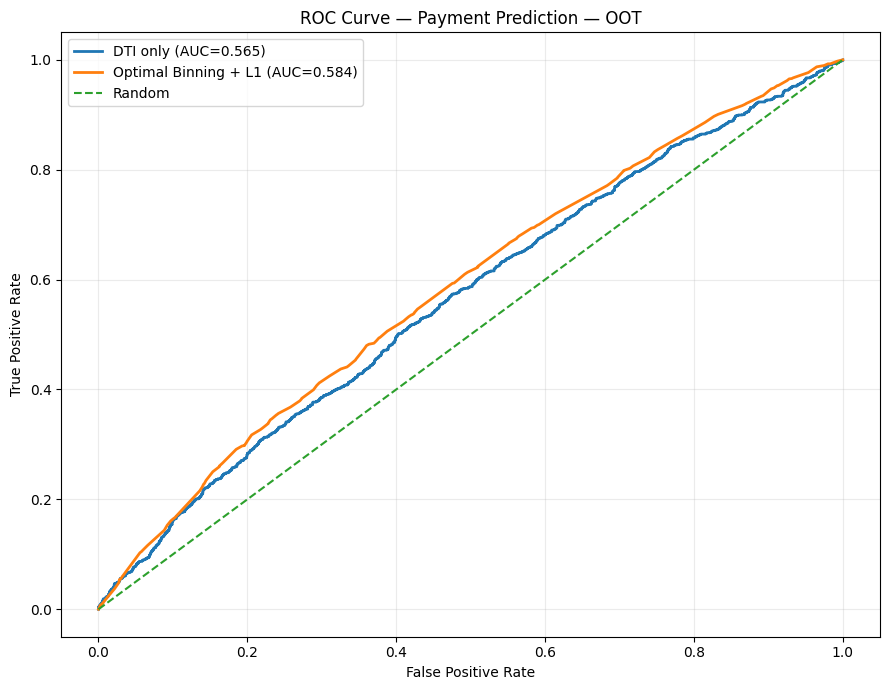

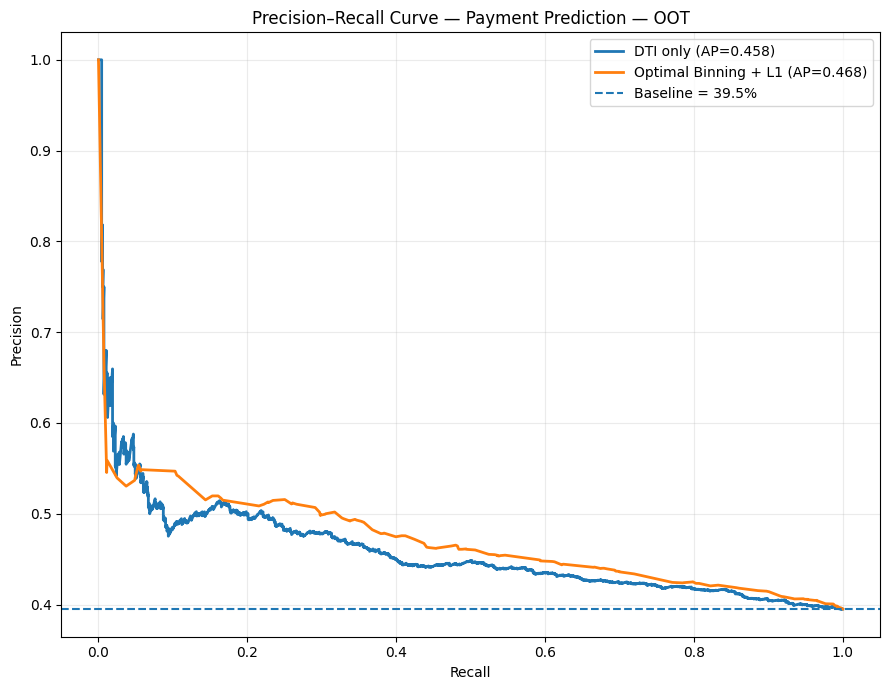

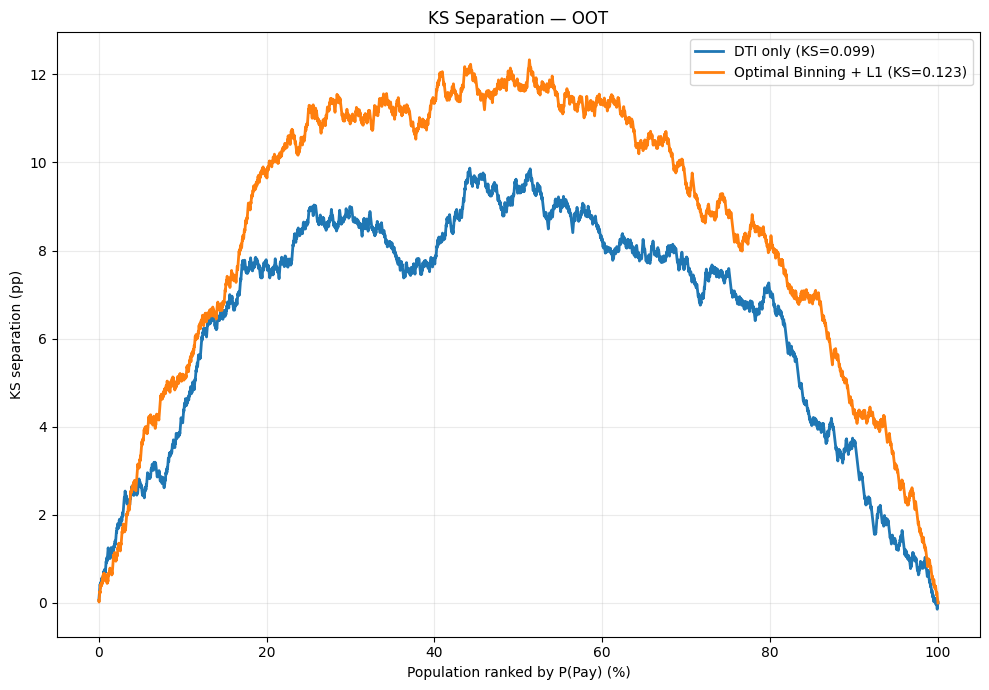


RANKING GAIN — L1 vs DTI ONLY
contact_pct payment_rate_DTI payment_rate_L1 payer_capture_DTI payer_capture_L1 recovery_capture_DTI recovery_capture_L1    recovery_DTI     recovery_L1  extra_payers extra_recovery_brl payment_rate_gain_pp
         1%           61.90%          50.00%             1.58%            1.28%                0.56%               0.49%     R$ 6,401.78     R$ 5,585.10            -5         R$ -816.68            -11.90 pp
         2%           55.95%          51.19%             2.86%            2.62%                1.10%               1.01%    R$ 12,445.55    R$ 11,428.16            -4       R$ -1,017.39             -4.76 pp
         5%           52.40%          55.29%             6.64%            7.00%                2.74%               3.75%    R$ 31,004.76    R$ 42,497.07             6      R$ +11,492.31             +2.88 pp
        10%           49.28%          51.92%            12.48%           13.15%                5.46%               8.54%    R$ 61,842.49    R

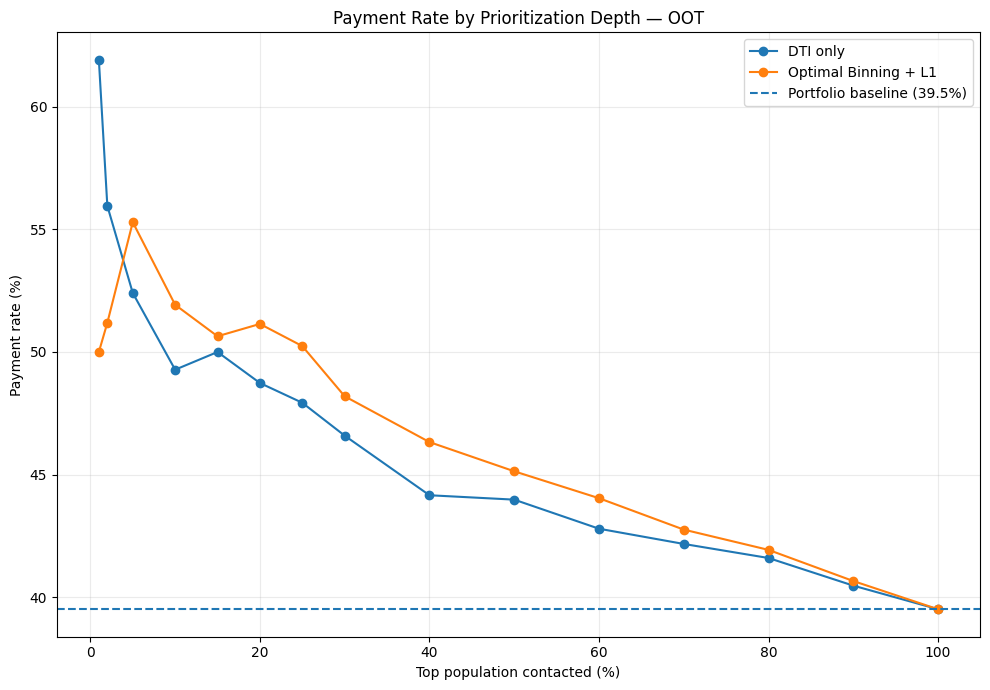

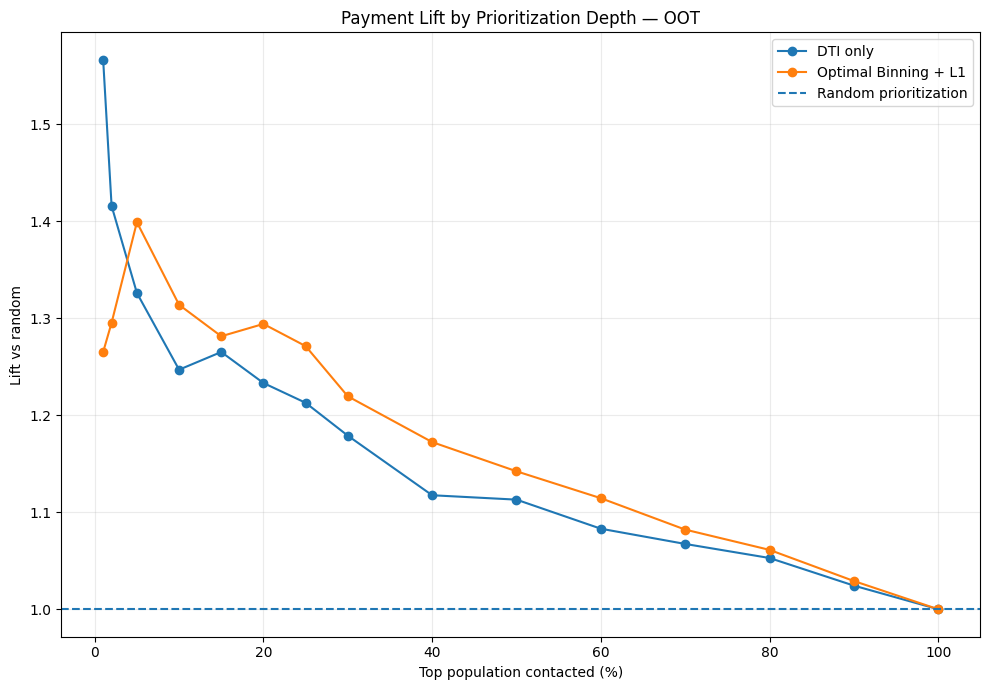

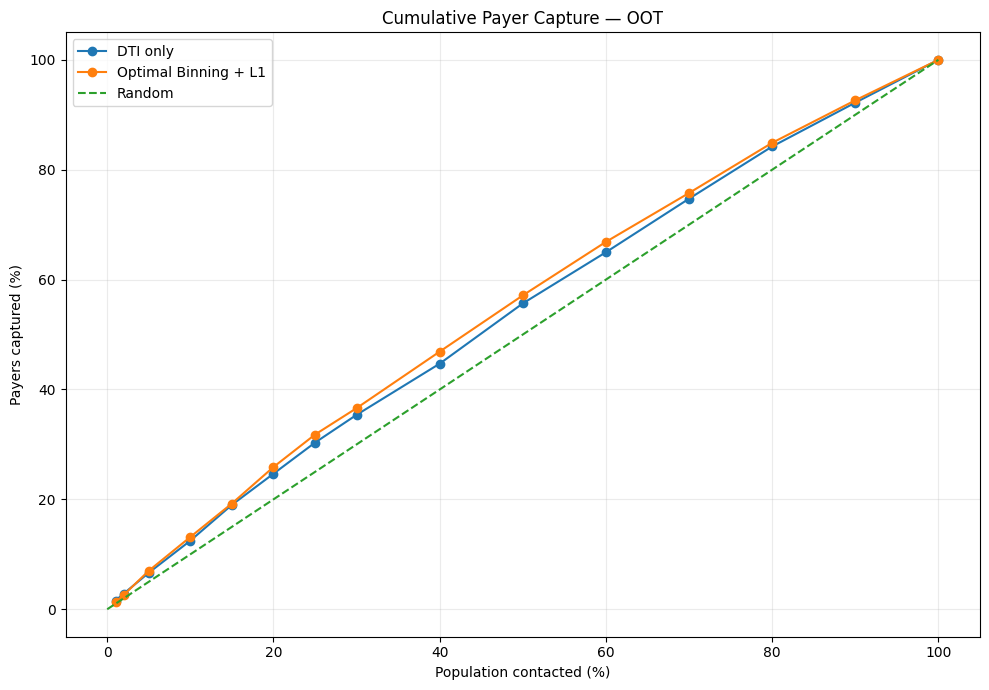

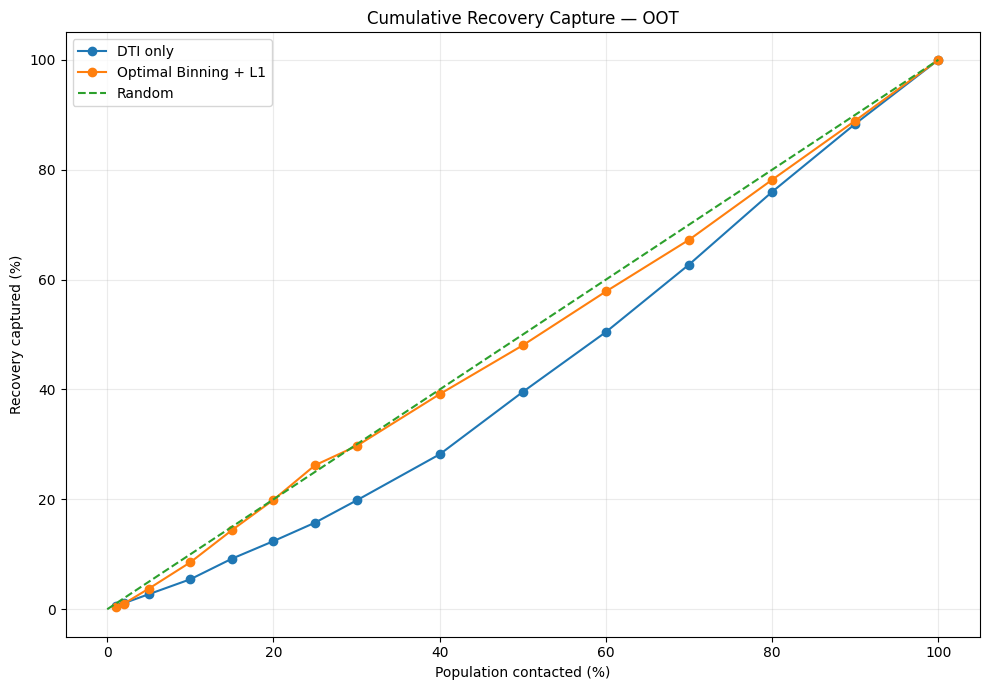

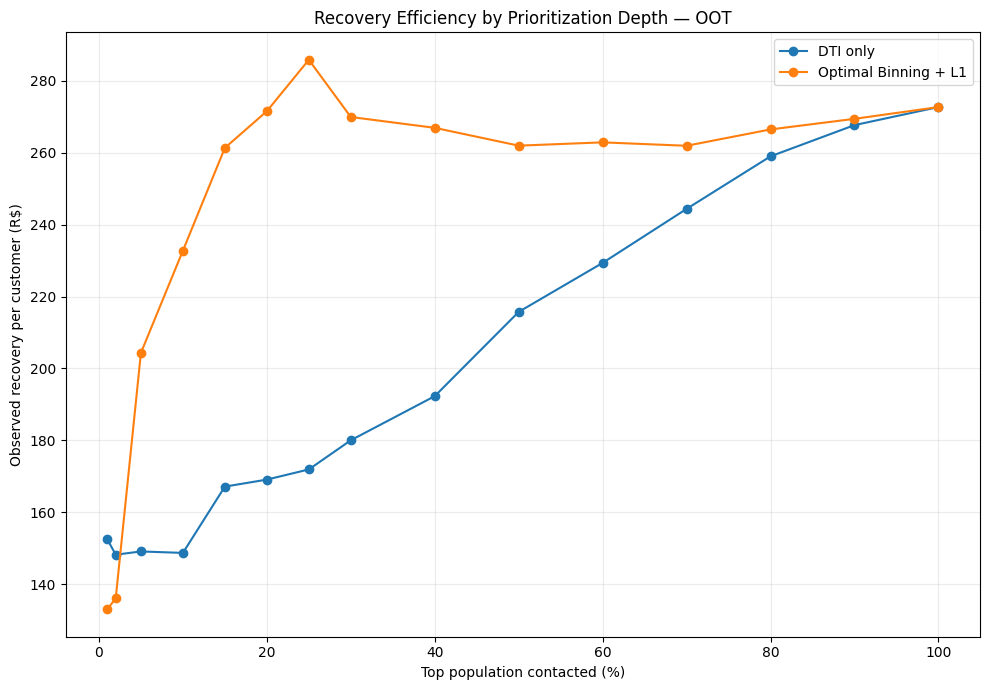

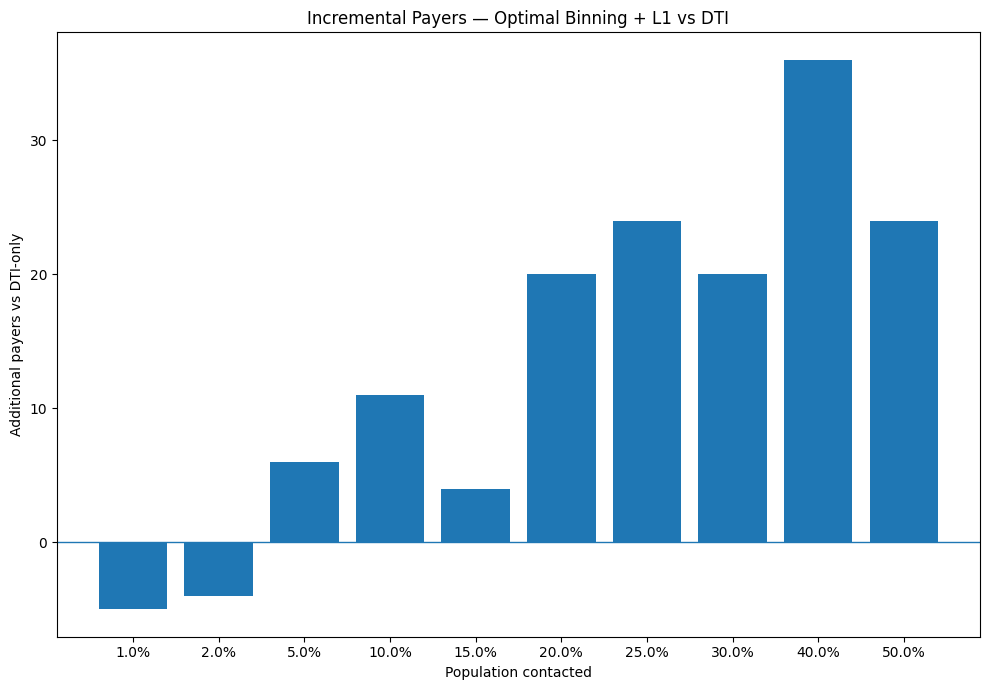

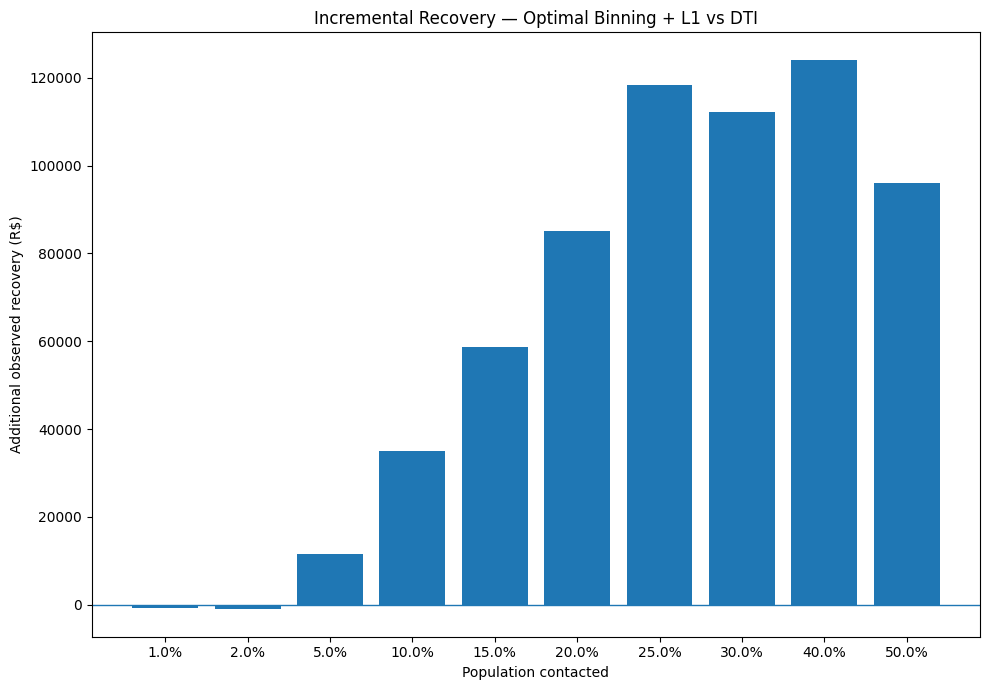

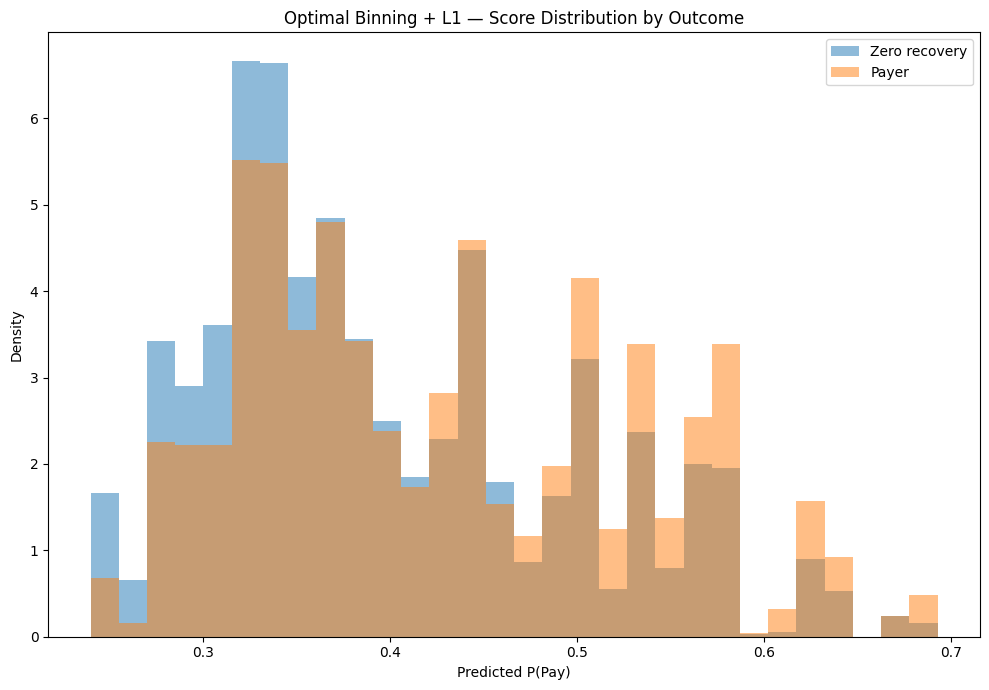


FINAL MODEL COMPARISON

DTI ONLY
AUC    : 0.5648
PR AUC : 0.4577
KS     : 0.0987

OPTIMAL BINNING + WOE + L1
AUC    : 0.5845
PR AUC : 0.4676
KS     : 0.1233



In [97]:
# ============================================================
# MODEL COMPARISON
#
# MODEL 1: DTI ONLY — Logistic Regression
# MODEL 2: Optimal Binning + WoE + L1
#
# TARGET:
#   1 = ANY PAYMENT > 0 até DPD30
#   0 = ZERO recovery até DPD30
#
# SAME:
#   TRAIN = June
#   OOT   = July
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve
)


# ============================================================
# 0. TARGET / DATA
# ============================================================

TARGET = "pay_to_dpd30"

# We already have:
# train
# oot
# X_train
# X_oot
# best_l1
#
# from previous steps.


# ============================================================
# 1. DTI-ONLY MODEL
# ============================================================

X_train_dti = train[
    ["dti_at_score"]
].copy()

X_oot_dti = oot[
    ["dti_at_score"]
].copy()

y_train = train[TARGET].astype(int)
y_oot = oot[TARGET].astype(int)


model_dti = LogisticRegression(
    max_iter=2000
)

model_dti.fit(
    X_train_dti,
    y_train
)


train["p_pay_dti"] = (
    model_dti
    .predict_proba(X_train_dti)[:, 1]
)

oot["p_pay_dti"] = (
    model_dti
    .predict_proba(X_oot_dti)[:, 1]
)


# L1 predictions — guarantee same OOT
oot["p_pay_l1"] = (
    best_l1
    .predict_proba(X_oot)[:, 1]
)


# ============================================================
# 2. FUNCTION — GLOBAL METRICS
# ============================================================

def model_metrics(y, p, model_name):

    auc = roc_auc_score(y, p)

    pr_auc = average_precision_score(
        y,
        p
    )

    fpr, tpr, thresholds = roc_curve(
        y,
        p
    )

    ks = np.max(
        tpr - fpr
    )

    return {
        "model": model_name,
        "roc_auc": auc,
        "pr_auc": pr_auc,
        "ks": ks
    }


metrics_comparison = pd.DataFrame([
    
    model_metrics(
        y_oot,
        oot["p_pay_dti"],
        "DTI only"
    ),
    
    model_metrics(
        y_oot,
        oot["p_pay_l1"],
        "Optimal Binning + WoE + L1"
    )
])


print()
print("=" * 90)
print("GLOBAL OOT PERFORMANCE")
print("=" * 90)

print(
    metrics_comparison.to_string(
        index=False,
        formatters={
            "roc_auc": lambda x: f"{x:.4f}",
            "pr_auc": lambda x: f"{x:.4f}",
            "ks": lambda x: f"{x:.4f}"
        }
    )
)


# ============================================================
# 3. DELTA TABLE
# ============================================================

dti_metrics = (
    metrics_comparison
    .iloc[0]
)

l1_metrics = (
    metrics_comparison
    .iloc[1]
)


delta_metrics = pd.DataFrame({

    "metric": [
        "ROC AUC",
        "PR AUC",
        "KS"
    ],

    "DTI_only": [
        dti_metrics["roc_auc"],
        dti_metrics["pr_auc"],
        dti_metrics["ks"]
    ],

    "Optimal_Binning_L1": [
        l1_metrics["roc_auc"],
        l1_metrics["pr_auc"],
        l1_metrics["ks"]
    ]
})


delta_metrics["absolute_gain"] = (
    delta_metrics["Optimal_Binning_L1"]
    -
    delta_metrics["DTI_only"]
)


delta_metrics["relative_gain_pct"] = (
    100
    *
    delta_metrics["absolute_gain"]
    /
    delta_metrics["DTI_only"]
)


print()
print("=" * 100)
print("PERFORMANCE GAIN")
print("=" * 100)

print(
    delta_metrics.to_string(
        index=False,

        formatters={
            "DTI_only":
                lambda x: f"{x:.4f}",

            "Optimal_Binning_L1":
                lambda x: f"{x:.4f}",

            "absolute_gain":
                lambda x: f"{x:+.4f}",

            "relative_gain_pct":
                lambda x: f"{x:+.2f}%"
        }
    )
)


# ============================================================
# 4. ROC CURVE
# ============================================================

fpr_dti, tpr_dti, _ = roc_curve(
    y_oot,
    oot["p_pay_dti"]
)

fpr_l1, tpr_l1, _ = roc_curve(
    y_oot,
    oot["p_pay_l1"]
)


plt.figure(
    figsize=(9, 7)
)

plt.plot(
    fpr_dti,
    tpr_dti,
    linewidth=2,
    label=(
        f"DTI only "
        f"(AUC={roc_auc_score(y_oot, oot['p_pay_dti']):.3f})"
    )
)

plt.plot(
    fpr_l1,
    tpr_l1,
    linewidth=2,
    label=(
        f"Optimal Binning + L1 "
        f"(AUC={roc_auc_score(y_oot, oot['p_pay_l1']):.3f})"
    )
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random"
)

plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.title(
    "ROC Curve — Payment Prediction — OOT"
)

plt.legend()

plt.grid(
    alpha=0.25
)

plt.tight_layout()

plt.show()


# ============================================================
# 5. PRECISION-RECALL CURVE
# ============================================================

precision_dti, recall_dti, _ = (
    precision_recall_curve(
        y_oot,
        oot["p_pay_dti"]
    )
)

precision_l1, recall_l1, _ = (
    precision_recall_curve(
        y_oot,
        oot["p_pay_l1"]
    )
)


baseline_payment_rate = (
    y_oot.mean()
)


plt.figure(
    figsize=(9, 7)
)

plt.plot(
    recall_dti,
    precision_dti,
    linewidth=2,
    label=(
        f"DTI only "
        f"(AP={average_precision_score(y_oot, oot['p_pay_dti']):.3f})"
    )
)

plt.plot(
    recall_l1,
    precision_l1,
    linewidth=2,
    label=(
        f"Optimal Binning + L1 "
        f"(AP={average_precision_score(y_oot, oot['p_pay_l1']):.3f})"
    )
)

plt.axhline(
    baseline_payment_rate,
    linestyle="--",
    label=(
        f"Baseline = "
        f"{baseline_payment_rate:.1%}"
    )
)

plt.xlabel(
    "Recall"
)

plt.ylabel(
    "Precision"
)

plt.title(
    "Precision–Recall Curve — Payment Prediction — OOT"
)

plt.legend()

plt.grid(
    alpha=0.25
)

plt.tight_layout()

plt.show()


# ============================================================
# 6. KS CURVE
# ============================================================

def ks_curve_data(y, p):

    df = pd.DataFrame({
        "y": np.asarray(y),
        "p": np.asarray(p)
    })

    df = (
        df
        .sort_values(
            "p",
            ascending=False
        )
        .reset_index(drop=True)
    )

    total_pos = (
        df["y"].sum()
    )

    total_neg = (
        (1 - df["y"]).sum()
    )

    df["cum_positive"] = (
        df["y"].cumsum()
        /
        total_pos
    )

    df["cum_negative"] = (
        (1 - df["y"]).cumsum()
        /
        total_neg
    )

    df["population_pct"] = (
        (np.arange(len(df)) + 1)
        /
        len(df)
    )

    df["ks_gap"] = (
        df["cum_positive"]
        -
        df["cum_negative"]
    )

    return df


ks_dti = ks_curve_data(
    y_oot,
    oot["p_pay_dti"]
)

ks_l1 = ks_curve_data(
    y_oot,
    oot["p_pay_l1"]
)


plt.figure(
    figsize=(10, 7)
)

plt.plot(
    ks_dti["population_pct"] * 100,
    ks_dti["ks_gap"] * 100,
    linewidth=2,
    label=(
        f"DTI only "
        f"(KS={ks_dti['ks_gap'].max():.3f})"
    )
)

plt.plot(
    ks_l1["population_pct"] * 100,
    ks_l1["ks_gap"] * 100,
    linewidth=2,
    label=(
        f"Optimal Binning + L1 "
        f"(KS={ks_l1['ks_gap'].max():.3f})"
    )
)

plt.xlabel(
    "Population ranked by P(Pay) (%)"
)

plt.ylabel(
    "KS separation (pp)"
)

plt.title(
    "KS Separation — OOT"
)

plt.legend()

plt.grid(
    alpha=0.25
)

plt.tight_layout()

plt.show()


# ============================================================
# 7. RANKING FUNCTION
# ============================================================

def ranking_table(
    df,
    probability_column,
    target_column,
    recovery_column,
    model_name
):

    ranked = (
        df
        .sort_values(
            probability_column,
            ascending=False
        )
        .reset_index(drop=True)
    )

    coverage_levels = [
        .01,
        .02,
        .05,
        .10,
        .15,
        .20,
        .25,
        .30,
        .40,
        .50,
        .60,
        .70,
        .80,
        .90,
        1.00
    ]

    total_payers = (
        ranked[
            target_column
        ].sum()
    )

    total_recovery = (
        ranked[
            recovery_column
        ].sum()
    )

    baseline = (
        ranked[
            target_column
        ].mean()
    )

    rows = []

    for coverage in coverage_levels:

        n = int(
            np.ceil(
                len(ranked)
                *
                coverage
            )
        )

        group = (
            ranked
            .iloc[:n]
        )

        payers = (
            group[
                target_column
            ].sum()
        )

        recovery = (
            group[
                recovery_column
            ].sum()
        )

        precision = (
            payers / n
        )

        rows.append({

            "model":
                model_name,

            "contact_pct":
                coverage * 100,

            "customers":
                n,

            "payers":
                payers,

            "payment_rate_pct":
                precision * 100,

            "payer_capture_pct":
                payers
                / total_payers
                * 100,

            "recovery_brl":
                recovery,

            "recovery_capture_pct":
                recovery
                / total_recovery
                * 100,

            "recovery_per_customer":
                recovery / n,

            "lift":
                precision
                / baseline
        })

    return pd.DataFrame(
        rows
    )


ranking_dti = ranking_table(
    oot,
    "p_pay_dti",
    TARGET,
    "recovery_to_dpd30_brl",
    "DTI only"
)


ranking_l1_compare = ranking_table(
    oot,
    "p_pay_l1",
    TARGET,
    "recovery_to_dpd30_brl",
    "Optimal Binning + WoE + L1"
)


ranking_compare = pd.concat(
    [
        ranking_dti,
        ranking_l1_compare
    ],
    ignore_index=True
)


# ============================================================
# 8. RANKING COMPARISON TABLE
# ============================================================

rank_dti_wide = (
    ranking_dti
    .set_index("contact_pct")
)

rank_l1_wide = (
    ranking_l1_compare
    .set_index("contact_pct")
)


ranking_gain = pd.DataFrame({

    "contact_pct":
        rank_dti_wide.index,

    "payment_rate_DTI":
        rank_dti_wide[
            "payment_rate_pct"
        ].values,

    "payment_rate_L1":
        rank_l1_wide[
            "payment_rate_pct"
        ].values,

    "payer_capture_DTI":
        rank_dti_wide[
            "payer_capture_pct"
        ].values,

    "payer_capture_L1":
        rank_l1_wide[
            "payer_capture_pct"
        ].values,

    "recovery_capture_DTI":
        rank_dti_wide[
            "recovery_capture_pct"
        ].values,

    "recovery_capture_L1":
        rank_l1_wide[
            "recovery_capture_pct"
        ].values,

    "recovery_DTI":
        rank_dti_wide[
            "recovery_brl"
        ].values,

    "recovery_L1":
        rank_l1_wide[
            "recovery_brl"
        ].values
})


ranking_gain[
    "extra_payers"
] = (
    rank_l1_wide[
        "payers"
    ].values
    -
    rank_dti_wide[
        "payers"
    ].values
)


ranking_gain[
    "extra_recovery_brl"
] = (
    ranking_gain[
        "recovery_L1"
    ]
    -
    ranking_gain[
        "recovery_DTI"
    ]
)


ranking_gain[
    "payment_rate_gain_pp"
] = (
    ranking_gain[
        "payment_rate_L1"
    ]
    -
    ranking_gain[
        "payment_rate_DTI"
    ]
)


print()
print("=" * 150)
print("RANKING GAIN — L1 vs DTI ONLY")
print("=" * 150)

print(
    ranking_gain.to_string(
        index=False,

        formatters={

            "contact_pct":
                lambda x: f"{x:.0f}%",

            "payment_rate_DTI":
                lambda x: f"{x:.2f}%",

            "payment_rate_L1":
                lambda x: f"{x:.2f}%",

            "payment_rate_gain_pp":
                lambda x: f"{x:+.2f} pp",

            "payer_capture_DTI":
                lambda x: f"{x:.2f}%",

            "payer_capture_L1":
                lambda x: f"{x:.2f}%",

            "recovery_capture_DTI":
                lambda x: f"{x:.2f}%",

            "recovery_capture_L1":
                lambda x: f"{x:.2f}%",

            "recovery_DTI":
                lambda x: f"R$ {x:,.2f}",

            "recovery_L1":
                lambda x: f"R$ {x:,.2f}",

            "extra_recovery_brl":
                lambda x: f"R$ {x:+,.2f}"
        }
    )
)


# ============================================================
# 9. PAYMENT RATE @ K
# ============================================================

plt.figure(
    figsize=(10, 7)
)

plt.plot(
    ranking_dti["contact_pct"],
    ranking_dti["payment_rate_pct"],
    marker="o",
    label="DTI only"
)

plt.plot(
    ranking_l1_compare["contact_pct"],
    ranking_l1_compare["payment_rate_pct"],
    marker="o",
    label="Optimal Binning + L1"
)

plt.axhline(
    baseline_payment_rate * 100,
    linestyle="--",
    label=(
        f"Portfolio baseline "
        f"({baseline_payment_rate:.1%})"
    )
)

plt.xlabel(
    "Top population contacted (%)"
)

plt.ylabel(
    "Payment rate (%)"
)

plt.title(
    "Payment Rate by Prioritization Depth — OOT"
)

plt.legend()

plt.grid(
    alpha=0.25
)

plt.tight_layout()

plt.show()


# ============================================================
# 10. LIFT @ K
# ============================================================

plt.figure(
    figsize=(10, 7)
)

plt.plot(
    ranking_dti["contact_pct"],
    ranking_dti["lift"],
    marker="o",
    label="DTI only"
)

plt.plot(
    ranking_l1_compare["contact_pct"],
    ranking_l1_compare["lift"],
    marker="o",
    label="Optimal Binning + L1"
)

plt.axhline(
    1,
    linestyle="--",
    label="Random prioritization"
)

plt.xlabel(
    "Top population contacted (%)"
)

plt.ylabel(
    "Lift vs random"
)

plt.title(
    "Payment Lift by Prioritization Depth — OOT"
)

plt.legend()

plt.grid(
    alpha=0.25
)

plt.tight_layout()

plt.show()


# ============================================================
# 11. CUMULATIVE PAYER CAPTURE
# ============================================================

plt.figure(
    figsize=(10, 7)
)

plt.plot(
    ranking_dti["contact_pct"],
    ranking_dti["payer_capture_pct"],
    marker="o",
    label="DTI only"
)

plt.plot(
    ranking_l1_compare["contact_pct"],
    ranking_l1_compare["payer_capture_pct"],
    marker="o",
    label="Optimal Binning + L1"
)

plt.plot(
    [0, 100],
    [0, 100],
    linestyle="--",
    label="Random"
)

plt.xlabel(
    "Population contacted (%)"
)

plt.ylabel(
    "Payers captured (%)"
)

plt.title(
    "Cumulative Payer Capture — OOT"
)

plt.legend()

plt.grid(
    alpha=0.25
)

plt.tight_layout()

plt.show()


# ============================================================
# 12. CUMULATIVE RECOVERY CAPTURE
# ============================================================

plt.figure(
    figsize=(10, 7)
)

plt.plot(
    ranking_dti["contact_pct"],
    ranking_dti["recovery_capture_pct"],
    marker="o",
    label="DTI only"
)

plt.plot(
    ranking_l1_compare["contact_pct"],
    ranking_l1_compare["recovery_capture_pct"],
    marker="o",
    label="Optimal Binning + L1"
)

plt.plot(
    [0, 100],
    [0, 100],
    linestyle="--",
    label="Random"
)

plt.xlabel(
    "Population contacted (%)"
)

plt.ylabel(
    "Recovery captured (%)"
)

plt.title(
    "Cumulative Recovery Capture — OOT"
)

plt.legend()

plt.grid(
    alpha=0.25
)

plt.tight_layout()

plt.show()


# ============================================================
# 13. RECOVERY PER CUSTOMER
# ============================================================

plt.figure(
    figsize=(10, 7)
)

plt.plot(
    ranking_dti["contact_pct"],
    ranking_dti["recovery_per_customer"],
    marker="o",
    label="DTI only"
)

plt.plot(
    ranking_l1_compare["contact_pct"],
    ranking_l1_compare["recovery_per_customer"],
    marker="o",
    label="Optimal Binning + L1"
)

plt.xlabel(
    "Top population contacted (%)"
)

plt.ylabel(
    "Observed recovery per customer (R$)"
)

plt.title(
    "Recovery Efficiency by Prioritization Depth — OOT"
)

plt.legend()

plt.grid(
    alpha=0.25
)

plt.tight_layout()

plt.show()


# ============================================================
# 14. EXTRA PAYERS FROM NEW MODEL
# ============================================================

plot_gain = ranking_gain[
    ranking_gain["contact_pct"] <= 50
].copy()


plt.figure(
    figsize=(10, 7)
)

plt.bar(
    plot_gain[
        "contact_pct"
    ].astype(str) + "%",

    plot_gain[
        "extra_payers"
    ]
)

plt.axhline(
    0,
    linewidth=1
)

plt.xlabel(
    "Population contacted"
)

plt.ylabel(
    "Additional payers vs DTI-only"
)

plt.title(
    "Incremental Payers — Optimal Binning + L1 vs DTI"
)

plt.tight_layout()

plt.show()


# ============================================================
# 15. EXTRA RECOVERY FROM NEW MODEL
# ============================================================

plt.figure(
    figsize=(10, 7)
)

plt.bar(
    plot_gain[
        "contact_pct"
    ].astype(str) + "%",

    plot_gain[
        "extra_recovery_brl"
    ]
)

plt.axhline(
    0,
    linewidth=1
)

plt.xlabel(
    "Population contacted"
)

plt.ylabel(
    "Additional observed recovery (R$)"
)

plt.title(
    "Incremental Recovery — Optimal Binning + L1 vs DTI"
)

plt.tight_layout()

plt.show()


# ============================================================
# 16. SCORE DISTRIBUTION BY ACTUAL OUTCOME
# ============================================================

fig, ax = plt.subplots(
    figsize=(10, 7)
)

for actual, label in [
    (0, "Zero recovery"),
    (1, "Payer")
]:

    subset = oot[
        oot[TARGET] == actual
    ]

    ax.hist(
        subset["p_pay_l1"],
        bins=30,
        alpha=0.5,
        density=True,
        label=label
    )


ax.set_xlabel(
    "Predicted P(Pay)"
)

ax.set_ylabel(
    "Density"
)

ax.set_title(
    "Optimal Binning + L1 — Score Distribution by Outcome"
)

ax.legend()

plt.tight_layout()

plt.show()


# ============================================================
# 17. FINAL SUMMARY
# ============================================================

print()
print("=" * 100)
print("FINAL MODEL COMPARISON")
print("=" * 100)

print()
print("DTI ONLY")
print(
    f"AUC    : "
    f"{roc_auc_score(y_oot, oot['p_pay_dti']):.4f}"
)
print(
    f"PR AUC : "
    f"{average_precision_score(y_oot, oot['p_pay_dti']):.4f}"
)
print(
    f"KS     : "
    f"{ks_dti['ks_gap'].max():.4f}"
)

print()

print("OPTIMAL BINNING + WOE + L1")
print(
    f"AUC    : "
    f"{roc_auc_score(y_oot, oot['p_pay_l1']):.4f}"
)
print(
    f"PR AUC : "
    f"{average_precision_score(y_oot, oot['p_pay_l1']):.4f}"
)
print(
    f"KS     : "
    f"{ks_l1['ks_gap'].max():.4f}"
)

print()
print("=" * 100)


ECONOMIC PRIORITY RANKING — OOT
contact_pct  customers recovery_brl_DTI recovery_capture_pct_DTI recovery_per_customer_DTI recovery_brl_L1 recovery_capture_pct_L1 recovery_per_customer_L1 incremental_recovery_brl incremental_capture_pp
        10%        416    R$ 252,875.13                    22.3%                 R$ 607.87   R$ 248,969.48                   22.0%                R$ 598.48             R$ -3,905.65                -0.3 pp
        20%        831    R$ 416,430.35                    36.7%                 R$ 501.12   R$ 430,591.21                   38.0%                R$ 518.16            R$ +14,160.86                +1.2 pp
        30%       1247    R$ 577,591.22                    51.0%                 R$ 463.18   R$ 571,861.02                   50.5%                R$ 458.59             R$ -5,730.20                -0.5 pp
        40%       1662    R$ 691,684.59                    61.0%                 R$ 416.18   R$ 695,355.58                   61.4%                R$ 41

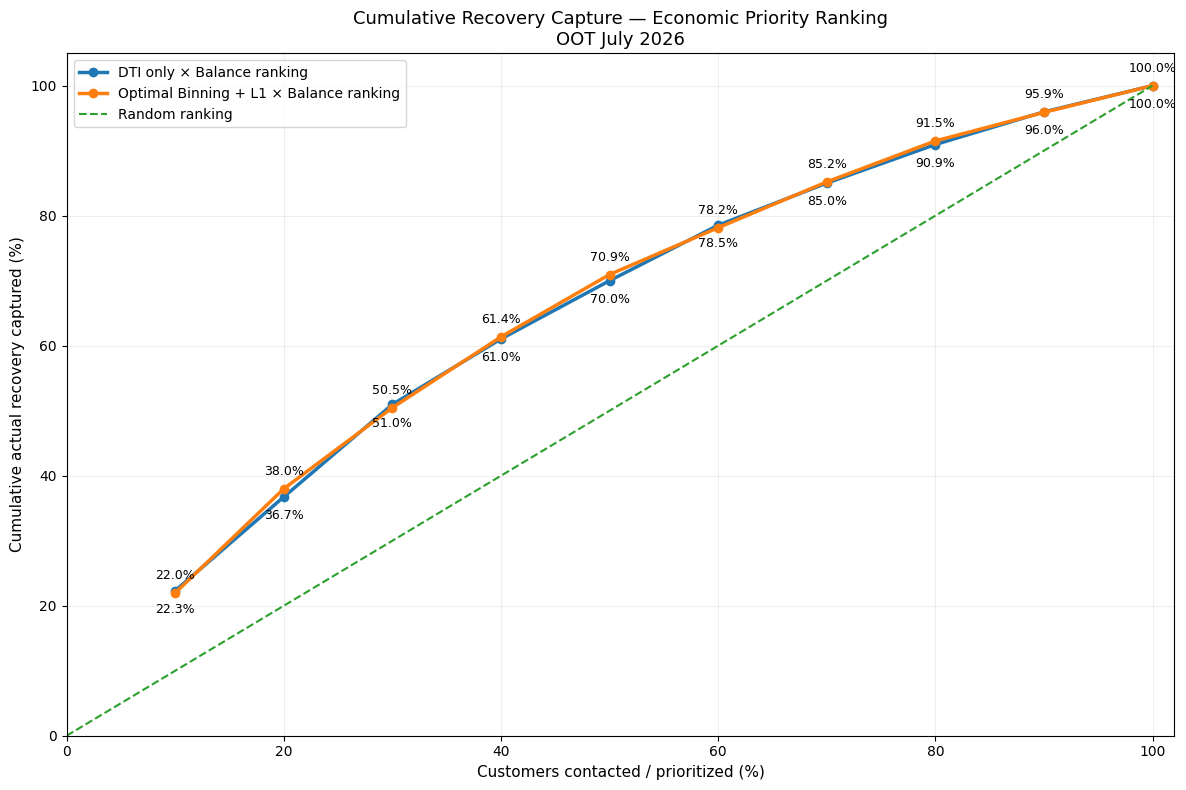

In [98]:
# ============================================================
# ECONOMIC PRIORITY RANKING
#
# Compare:
#   1. DTI-only P(Pay) × Balance
#   2. Optimal Binning + L1 P(Pay) × Balance
#
# Evaluation:
#   Cumulative ACTUAL recovery captured in OOT
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# 1. ECONOMIC SCORES
# ============================================================

oot_econ = oot.copy()


oot_econ["economic_score_dti"] = (
    oot_econ["p_pay_dti"]
    *
    oot_econ["balance_at_score"]
)


oot_econ["economic_score_l1"] = (
    oot_econ["p_pay_l1"]
    *
    oot_econ["balance_at_score"]
)


# ============================================================
# 2. PRIORITIZATION DEPTHS
# ============================================================

coverage_levels = [
    .10,
    .20,
    .30,
    .40,
    .50,
    .60,
    .70,
    .80,
    .90,
    1.00
]


total_recovery = (
    oot_econ[
        "recovery_to_dpd30_brl"
    ].sum()
)


# ============================================================
# 3. FUNCTION
# ============================================================

def economic_ranking_table(
    df,
    score_col,
    model_name
):

    ranked = (
        df
        .sort_values(
            score_col,
            ascending=False
        )
        .reset_index(drop=True)
    )

    rows = []

    for coverage in coverage_levels:

        n = int(
            np.ceil(
                len(ranked)
                *
                coverage
            )
        )

        group = ranked.iloc[:n]

        recovery = (
            group[
                "recovery_to_dpd30_brl"
            ].sum()
        )

        payers = (
            group[
                "pay_to_dpd30"
            ].sum()
        )

        rows.append({

            "model":
                model_name,

            "contact_pct":
                coverage * 100,

            "customers":
                n,

            "payers":
                payers,

            "payment_rate_pct":
                100 * payers / n,

            "recovery_brl":
                recovery,

            "recovery_capture_pct":
                100 * recovery / total_recovery,

            "recovery_per_customer":
                recovery / n
        })

    return pd.DataFrame(rows)


# ============================================================
# 4. BUILD BOTH RANKINGS
# ============================================================

econ_dti = economic_ranking_table(
    oot_econ,
    "economic_score_dti",
    "DTI only × Balance"
)


econ_l1 = economic_ranking_table(
    oot_econ,
    "economic_score_l1",
    "Optimal Binning + L1 × Balance"
)


# ============================================================
# 5. COMPARISON TABLE
# ============================================================

comparison = (
    econ_dti[
        [
            "contact_pct",
            "customers",
            "recovery_brl",
            "recovery_capture_pct",
            "recovery_per_customer"
        ]
    ]
    .merge(
        econ_l1[
            [
                "contact_pct",
                "recovery_brl",
                "recovery_capture_pct",
                "recovery_per_customer"
            ]
        ],
        on="contact_pct",
        suffixes=("_DTI", "_L1")
    )
)


comparison["incremental_recovery_brl"] = (
    comparison["recovery_brl_L1"]
    -
    comparison["recovery_brl_DTI"]
)


comparison["incremental_capture_pp"] = (
    comparison["recovery_capture_pct_L1"]
    -
    comparison["recovery_capture_pct_DTI"]
)


print()
print("=" * 150)
print("ECONOMIC PRIORITY RANKING — OOT")
print("=" * 150)

print(
    comparison.to_string(
        index=False,

        formatters={

            "contact_pct":
                lambda x: f"{x:.0f}%",

            "recovery_brl_DTI":
                lambda x: f"R$ {x:,.2f}",

            "recovery_brl_L1":
                lambda x: f"R$ {x:,.2f}",

            "recovery_capture_pct_DTI":
                lambda x: f"{x:.1f}%",

            "recovery_capture_pct_L1":
                lambda x: f"{x:.1f}%",

            "recovery_per_customer_DTI":
                lambda x: f"R$ {x:,.2f}",

            "recovery_per_customer_L1":
                lambda x: f"R$ {x:,.2f}",

            "incremental_recovery_brl":
                lambda x: f"R$ {x:+,.2f}",

            "incremental_capture_pp":
                lambda x: f"{x:+.1f} pp"
        }
    )
)


# ============================================================
# 6. GRAPH
# ============================================================

plt.figure(
    figsize=(12, 8)
)


# ----------------------------
# DTI
# ----------------------------

plt.plot(
    econ_dti["contact_pct"],
    econ_dti["recovery_capture_pct"],
    marker="o",
    linewidth=2.5,
    label="DTI only × Balance ranking"
)


# ----------------------------
# L1
# ----------------------------

plt.plot(
    econ_l1["contact_pct"],
    econ_l1["recovery_capture_pct"],
    marker="o",
    linewidth=2.5,
    label="Optimal Binning + L1 × Balance ranking"
)


# ----------------------------
# RANDOM
# ----------------------------

plt.plot(
    [0, 100],
    [0, 100],
    linestyle="--",
    linewidth=1.5,
    label="Random ranking"
)


# ============================================================
# 7. LABEL VALUES
# ============================================================

for _, row in econ_dti.iterrows():

    plt.annotate(
        f"{row['recovery_capture_pct']:.1f}%",
        (
            row["contact_pct"],
            row["recovery_capture_pct"]
        ),
        xytext=(0, -16),
        textcoords="offset points",
        ha="center",
        fontsize=9
    )


for _, row in econ_l1.iterrows():

    plt.annotate(
        f"{row['recovery_capture_pct']:.1f}%",
        (
            row["contact_pct"],
            row["recovery_capture_pct"]
        ),
        xytext=(0, 10),
        textcoords="offset points",
        ha="center",
        fontsize=9
    )


# ============================================================
# 8. FORMATTING
# ============================================================

plt.xlabel(
    "Customers contacted / prioritized (%)",
    fontsize=11
)

plt.ylabel(
    "Cumulative actual recovery captured (%)",
    fontsize=11
)

plt.title(
    "Cumulative Recovery Capture — Economic Priority Ranking\n"
    "OOT July 2026",
    fontsize=13
)

plt.xlim(
    0,
    102
)

plt.ylim(
    0,
    105
)

plt.grid(
    alpha=0.20
)

plt.legend(
    loc="upper left"
)

plt.tight_layout()

plt.show()

Discrimina pagadores um pouco melhor: AUC sobe de ~0,565 para 0,5845 e KS para 0,1198  
Não prejudica a priorização econômica: quando fazemos \(P(Pay)\times Balance\), o cumulative recovery capture fica praticamente igual ao DTI-only.

Então não há um trade-off relevante do tipo: ganho identificação de pagadores, mas perco recovery

In [106]:
# ============================================================
# DIAGNOSTIC — REAL COLUMNS IN OOT
# ============================================================

print("=" * 100)
print("OOT")
print("=" * 100)

print(f"Shape: {oot.shape}")
print()

for i, col in enumerate(oot.columns):
    print(f"{i:>4} | {col}")

OOT
Shape: (4155, 29)

   0 | customer_id
   1 | message_id
   2 | score_at
   3 | template
   4 | n_msgs_last_14d
   5 | dpd_at_score
   6 | balance_at_score
   7 | salary_at_score
   8 | payday_day_of_month
   9 | n_prior_transactions
  10 | account_age_months
  11 | days_since_last_app_login
  12 | state_uf
  13 | delivery_status
  14 | interaction
  15 | paid_within_72h
  16 | amount_paid_brl
  17 | dti_at_score
  18 | entry_dpd_band
  19 | score_month
  20 | days_until_dpd30
  21 | dpd30_at
  22 | mature_to_dpd30
  23 | messages_to_dpd30
  24 | recovery_to_dpd30_brl
  25 | pay_to_dpd30
  26 | p_pay
  27 | p_pay_l1
  28 | p_pay_dti


In [107]:
# ============================================================
# COLUMNS RELEVANT TO OUR ANALYSIS
# ============================================================

keywords = [
    "dpd",
    "due",
    "balance",
    "pay",
    "recovery",
    "message",
    "msg",
    "contact",
    "score",
    "customer"
]

relevant_cols = [
    col
    for col in oot.columns
    if any(
        keyword in col.lower()
        for keyword in keywords
    )
]

print("=" * 100)
print("RELEVANT OOT COLUMNS")
print("=" * 100)

for col in relevant_cols:
    print(col)

RELEVANT OOT COLUMNS
customer_id
message_id
score_at
n_msgs_last_14d
dpd_at_score
balance_at_score
salary_at_score
payday_day_of_month
dti_at_score
entry_dpd_band
score_month
days_until_dpd30
dpd30_at
mature_to_dpd30
messages_to_dpd30
recovery_to_dpd30_brl
pay_to_dpd30
p_pay
p_pay_l1
p_pay_dti


In [108]:
print()
print("=" * 100)
print("RELEVANT WA COLUMNS")
print("=" * 100)

relevant_wa_cols = [
    col
    for col in wa.columns
    if any(
        keyword in col.lower()
        for keyword in keywords
    )
]

for col in relevant_wa_cols:
    print(col)


RELEVANT WA COLUMNS
message_id
customer_id
n_msgs_last_14d
days_past_due
outstanding_balance_brl
payday_day_of_month


ONE-MESSAGE FULL PAYERS — DPD 1-30
OOT rows             : 4,155
OOT customers        : 4,155

DPD 1-30             : 4,155
Exactly 1 message    : 240
Full payment         : 1,168
--------------------------------------------------------------------------------------------------------------
TARGET rows          : 233
TARGET customers     : 233
Balance at score     : R$ 175,808.22
Actual recovery      : R$ 175,808.22

RAW MODEL SCORES — TARGET POPULATION
       P(Pay) DTI  P(Pay) L1  Economic DTI  Economic L1
count      233.00     233.00        233.00       233.00
mean         0.42       0.44        298.10       308.27
std          0.06       0.10        160.25       171.25
min          0.24       0.24        113.11        95.36
10%          0.34       0.31        125.06       126.54
25%          0.38       0.35        171.55       173.74
50%          0.42       0.43        267.90       268.06
75%          0.47       0.52        391.03       402.00
90%          0.48       0.58        526.

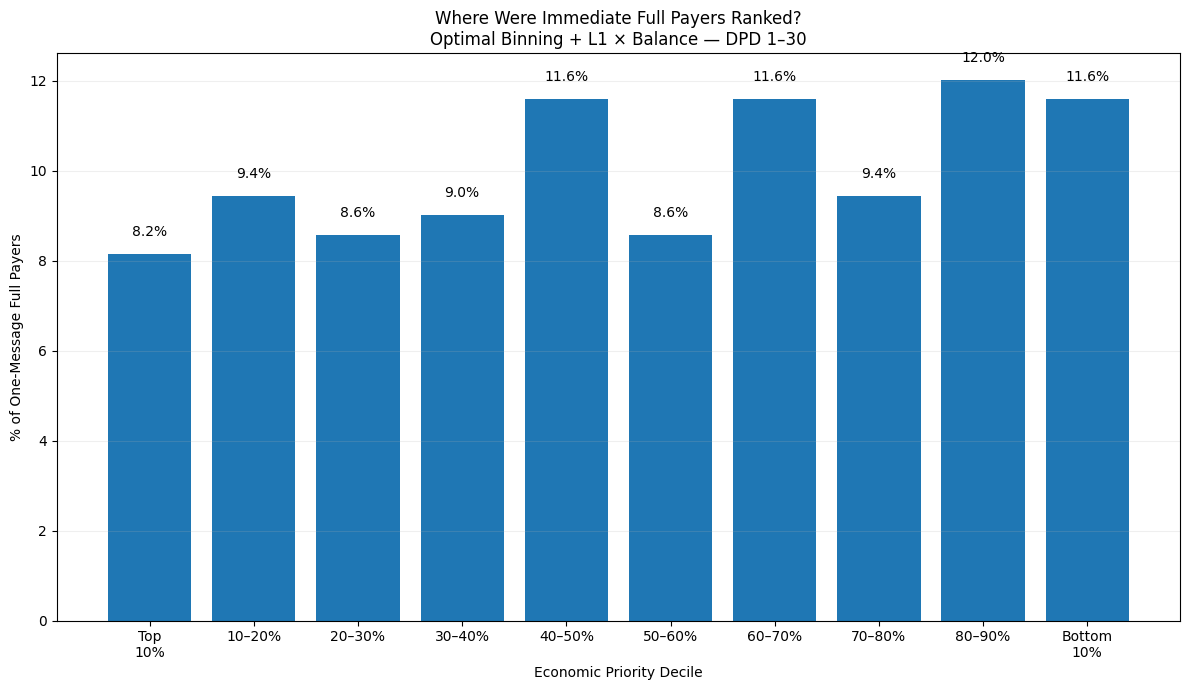

In [109]:
# ============================================================
# ONE-MESSAGE FULL PAYERS — SCORE ANALYSIS
#
# Population:
#   - DPD <= 30 at score
#   - exactly 1 message until DPD30
#   - paid
#   - recovered ~100% of balance
#
# Question:
#   Where were these customers ranked by:
#       1. DTI-only model
#       2. Optimal Binning + L1
#       3. Economic score = P(Pay) × Balance
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# 1. BASE
# ============================================================

df = oot.copy()


# ============================================================
# 2. ECONOMIC SCORES
# ============================================================

df["economic_score_dti"] = (
    df["p_pay_dti"]
    *
    df["balance_at_score"]
)

df["economic_score_l1"] = (
    df["p_pay_l1"]
    *
    df["balance_at_score"]
)


# ============================================================
# 3. IDENTIFY TARGET POPULATION
#
# Full payment:
# recovery until DPD30 approximately equals balance at score
#
# One message:
# exactly 1 message until DPD30
# ============================================================

TOLERANCE = 1.00   # R$ 1 tolerance


df["is_full_payment"] = (
    (
        df["recovery_to_dpd30_brl"]
        -
        df["balance_at_score"]
    )
    .abs()
    <= TOLERANCE
)


df["is_one_message"] = (
    df["messages_to_dpd30"].eq(1)
)


df["is_dpd_1_30"] = (
    df["dpd_at_score"]
    .between(1, 30)
)


df["is_target"] = (
    df["is_dpd_1_30"]
    &
    df["is_one_message"]
    &
    df["pay_to_dpd30"].eq(1)
    &
    df["is_full_payment"]
)


target = df.loc[
    df["is_target"]
].copy()


# ============================================================
# 4. QA
# ============================================================

print("=" * 110)
print("ONE-MESSAGE FULL PAYERS — DPD 1-30")
print("=" * 110)

print(f"OOT rows             : {len(df):,}")
print(f"OOT customers        : {df['customer_id'].nunique():,}")
print()

print(
    f"DPD 1-30             : "
    f"{df['is_dpd_1_30'].sum():,}"
)

print(
    f"Exactly 1 message    : "
    f"{df['is_one_message'].sum():,}"
)

print(
    f"Full payment         : "
    f"{df['is_full_payment'].sum():,}"
)

print("-" * 110)

print(
    f"TARGET rows          : "
    f"{len(target):,}"
)

print(
    f"TARGET customers     : "
    f"{target['customer_id'].nunique():,}"
)

print(
    f"Balance at score     : "
    f"R$ {target['balance_at_score'].sum():,.2f}"
)

print(
    f"Actual recovery      : "
    f"R$ {target['recovery_to_dpd30_brl'].sum():,.2f}"
)


# ============================================================
# 5. SCORE PERCENTILES
#
# IMPORTANT:
# calculated against ALL eligible DPD1-30 customers,
# not just against the target population.
#
# 100 = highest score
# ============================================================

eligible = df.loc[
    df["is_dpd_1_30"]
].copy()


eligible["pct_p_pay_dti"] = (
    eligible["p_pay_dti"]
    .rank(
        pct=True,
        method="average"
    )
    * 100
)


eligible["pct_p_pay_l1"] = (
    eligible["p_pay_l1"]
    .rank(
        pct=True,
        method="average"
    )
    * 100
)


eligible["pct_econ_dti"] = (
    eligible["economic_score_dti"]
    .rank(
        pct=True,
        method="average"
    )
    * 100
)


eligible["pct_econ_l1"] = (
    eligible["economic_score_l1"]
    .rank(
        pct=True,
        method="average"
    )
    * 100
)


# Bring percentiles to target
target = target.merge(
    eligible[
        [
            "message_id",
            "pct_p_pay_dti",
            "pct_p_pay_l1",
            "pct_econ_dti",
            "pct_econ_l1"
        ]
    ],
    on="message_id",
    how="left"
)


# ============================================================
# 6. RAW SCORE SUMMARY
# ============================================================

print()
print("=" * 110)
print("RAW MODEL SCORES — TARGET POPULATION")
print("=" * 110)


summary = pd.DataFrame({

    "P(Pay) DTI": target["p_pay_dti"].describe(
        percentiles=[.10, .25, .50, .75, .90]
    ),

    "P(Pay) L1": target["p_pay_l1"].describe(
        percentiles=[.10, .25, .50, .75, .90]
    ),

    "Economic DTI": target["economic_score_dti"].describe(
        percentiles=[.10, .25, .50, .75, .90]
    ),

    "Economic L1": target["economic_score_l1"].describe(
        percentiles=[.10, .25, .50, .75, .90]
    )

})

print(
    summary.round(3)
)


# ============================================================
# 7. PRIORITY CAPTURE
# ============================================================

def priority_metrics(
    data,
    percentile_col
):

    return {

        "Median percentile":
            data[percentile_col].median(),

        "Mean percentile":
            data[percentile_col].mean(),

        "Top 10%":
            100 * (
                data[percentile_col] >= 90
            ).mean(),

        "Top 20%":
            100 * (
                data[percentile_col] >= 80
            ).mean(),

        "Top 30%":
            100 * (
                data[percentile_col] >= 70
            ).mean(),

        "Top 50%":
            100 * (
                data[percentile_col] >= 50
            ).mean()
    }


priority = pd.DataFrame({

    "P(Pay) DTI":
        priority_metrics(
            target,
            "pct_p_pay_dti"
        ),

    "P(Pay) L1":
        priority_metrics(
            target,
            "pct_p_pay_l1"
        ),

    "Economic DTI":
        priority_metrics(
            target,
            "pct_econ_dti"
        ),

    "Economic L1":
        priority_metrics(
            target,
            "pct_econ_l1"
        )
})


print()
print("=" * 110)
print("WHERE DID ONE-MESSAGE FULL PAYERS RANK?")
print("=" * 110)

print(
    priority.round(1)
)


# ============================================================
# 8. ECONOMIC L1 DECILE
#
# Decile 1 = highest economic priority
# ============================================================

target["economic_l1_decile"] = (
    11
    -
    np.ceil(
        target["pct_econ_l1"] / 10
    )
).clip(1, 10).astype(int)


deciles = (
    target
    .groupby("economic_l1_decile")
    .agg(
        customers=("customer_id", "nunique"),
        recovery_brl=("recovery_to_dpd30_brl", "sum"),
        avg_balance=("balance_at_score", "mean"),
        avg_p_pay=("p_pay_l1", "mean"),
        avg_economic_score=("economic_score_l1", "mean")
    )
    .reindex(range(1, 11))
    .fillna(0)
    .reset_index()
)


deciles["customer_pct"] = (
    100
    *
    deciles["customers"]
    /
    target["customer_id"].nunique()
)


print()
print("=" * 110)
print("ONE-MESSAGE FULL PAYERS BY ECONOMIC PRIORITY DECILE")
print("1 = TOP 10% | 10 = BOTTOM 10%")
print("=" * 110)

print(
    deciles.to_string(
        index=False,

        formatters={

            "customer_pct":
                lambda x: f"{x:.1f}%",

            "recovery_brl":
                lambda x: f"R$ {x:,.2f}",

            "avg_balance":
                lambda x: f"R$ {x:,.2f}",

            "avg_p_pay":
                lambda x: f"{100*x:.1f}%",

            "avg_economic_score":
                lambda x: f"R$ {x:,.2f}"
        }
    )
)


# ============================================================
# 9. GRAPH
# ============================================================

plt.figure(
    figsize=(12, 7)
)


plt.bar(
    deciles["economic_l1_decile"],
    deciles["customer_pct"]
)


for _, row in deciles.iterrows():

    if row["customer_pct"] > 0:

        plt.text(
            row["economic_l1_decile"],
            row["customer_pct"] + 0.4,
            f"{row['customer_pct']:.1f}%",
            ha="center",
            fontsize=10
        )


plt.xlabel(
    "Economic Priority Decile"
)

plt.ylabel(
    "% of One-Message Full Payers"
)

plt.title(
    "Where Were Immediate Full Payers Ranked?\n"
    "Optimal Binning + L1 × Balance — DPD 1–30"
)

plt.xticks(
    range(1, 11),
    [
        "Top\n10%",
        "10–20%",
        "20–30%",
        "30–40%",
        "40–50%",
        "50–60%",
        "60–70%",
        "70–80%",
        "80–90%",
        "Bottom\n10%"
    ]
)

plt.grid(
    axis="y",
    alpha=.20
)

plt.tight_layout()

plt.show()

In [99]:
import sys
!{sys.executable} -m pip install xgboost

In [59]:
import xgboost as xgb

print(xgb.__version__)

3.4.1


In [61]:
# ============================================================
# AUDIT — OBJECTS FROM THE ORIGINAL L1 MODEL
# ============================================================

objects_to_check = [
    "train",
    "valid",
    "oot",
    "X_train",
    "X_test",
    "X_valid",
    "X_oot",
    "y_train",
    "y_test",
    "y_valid",
    "y_oot"
]

for obj_name in objects_to_check:
    if obj_name in globals():
        obj = globals()[obj_name]

        print("\n" + "=" * 100)
        print(obj_name)
        print("=" * 100)

        if hasattr(obj, "shape"):
            print("Shape:", obj.shape)

        if hasattr(obj, "columns"):
            print("Columns:")
            print(obj.columns.tolist())

        elif hasattr(obj, "name"):
            print("Name:", obj.name)


train
Shape: (3681, 30)
Columns:
['customer_id', 'message_id', 'score_at', 'template', 'n_msgs_last_14d', 'dpd_at_score', 'balance_at_score', 'salary_at_score', 'payday_day_of_month', 'n_prior_transactions', 'account_age_months', 'days_since_last_app_login', 'state_uf', 'delivery_status', 'interaction', 'paid_within_72h', 'amount_paid_brl', 'dti_at_score', 'entry_dpd_band', 'score_month', 'days_until_dpd30', 'dpd30_at', 'mature_to_dpd30', 'messages_to_dpd30', 'recovery_to_dpd30_brl', 'pay_to_dpd30', 'zero_recovery_to_dpd30', 'target_window_days', 'p_pay', 'p_pay_dti']

oot
Shape: (4155, 31)
Columns:
['customer_id', 'message_id', 'score_at', 'template', 'n_msgs_last_14d', 'dpd_at_score', 'balance_at_score', 'salary_at_score', 'payday_day_of_month', 'n_prior_transactions', 'account_age_months', 'days_since_last_app_login', 'state_uf', 'delivery_status', 'interaction', 'paid_within_72h', 'amount_paid_brl', 'dti_at_score', 'entry_dpd_band', 'score_month', 'days_until_dpd30', 'dpd30_at', '

In [62]:
# ============================================================
# FIND MODEL / SCORE OBJECTS
# ============================================================

for name in sorted(globals().keys()):

    name_lower = name.lower()

    if any(
        term in name_lower
        for term in [
            "l1",
            "dti",
            "score",
            "feature",
            "model"
        ]
    ):
        obj = globals()[name]

        print(
            f"{name:<40}",
            type(obj)
        )

CATEGORICAL_FEATURES                     <class 'list'>
FEATURE                                  <class 'str'>
FEATURES                                 <class 'list'>
NUMERIC_FEATURES                         <class 'list'>
SCORE                                    <class 'str'>
WOE_FEATURES                             <class 'list'>
X_oot_dti                                <class 'pandas.core.frame.DataFrame'>
X_train_dti                              <class 'pandas.core.frame.DataFrame'>
accuracy_score                           <class 'function'>
auc_l1                                   <class 'float'>
average_precision_score                  <class 'function'>
base_l1                                  <class 'sklearn.linear_model._logistic.LogisticRegression'>
best_l1                                  <class 'sklearn.linear_model._logistic.LogisticRegression'>
beta_dti                                 <class 'numpy.float64'>
binning_models                           <class 'dict'>
binning_

In [63]:
# ============================================================
# 29 — XGBOOST CHALLENGER
# EXACT SAME X / Y AS L1
# ============================================================

from xgboost import XGBClassifier

xgb_challenger = XGBClassifier(
    n_estimators=300,
    max_depth=3,
    learning_rate=0.03,

    min_child_weight=10,

    subsample=0.8,
    colsample_bytree=0.8,

    reg_alpha=1.0,
    reg_lambda=5.0,

    objective="binary:logistic",
    eval_metric="logloss",

    random_state=42,
    n_jobs=-1
)

xgb_challenger.fit(
    X_train,
    y_train
)

p_xgb_train = xgb_challenger.predict_proba(
    X_train
)[:, 1]

p_xgb_oot = xgb_challenger.predict_proba(
    X_oot
)[:, 1]

print("XGBoost fitted.")

XGBoost fitted.


In [64]:
# ============================================================
# 30 — XGBOOST TRAIN vs OOT
# ============================================================

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    log_loss
)

from scipy.stats import ks_2samp


def evaluate_xgb(y, p):

    return {
        "customers": len(y),

        "payer_rate":
            y.mean(),

        "roc_auc":
            roc_auc_score(y, p),

        "pr_auc":
            average_precision_score(y, p),

        "ks":
            ks_2samp(
                p[y == 1],
                p[y == 0]
            ).statistic,

        "log_loss":
            log_loss(y, p)
    }


print("=" * 100)
print("XGBOOST — SAME FEATURES AS L1")
print("=" * 100)

print("\nTRAIN")
print(
    evaluate_xgb(
        y_train,
        p_xgb_train
    )
)

print("\nOOT")
print(
    evaluate_xgb(
        y_oot,
        p_xgb_oot
    )
)

XGBOOST — SAME FEATURES AS L1

TRAIN
{'customers': 3681, 'payer_rate': np.float64(0.40532464004346647), 'roc_auc': 0.6576033041150182, 'pr_auc': 0.5698227779362144, 'ks': np.float64(0.2468465897608932), 'log_loss': 0.6358086466789246}

OOT
{'customers': 4155, 'payer_rate': np.float64(0.3951865222623345), 'roc_auc': 0.5746394025125376, 'pr_auc': 0.4613687803929689, 'ks': np.float64(0.11428949487027991), 'log_loss': 0.6703216433525085}


In [65]:
# ============================================================
# 31 — XGBOOST ECONOMIC SCORE
# ============================================================

oot_xgb = oot.copy()

oot_xgb["p_pay_xgb"] = p_xgb_oot

oot_xgb["economic_score_xgb"] = (
    oot_xgb["p_pay_xgb"]
    * oot_xgb["balance_at_score"]
)

print(
    oot_xgb[
        [
            "customer_id",
            "balance_at_score",
            "pay_to_dpd30",
            "recovery_to_dpd30_brl",
            "p_pay_l1",
            "p_pay_xgb",
            "economic_score_xgb"
        ]
    ].head()
)

   customer_id  balance_at_score  pay_to_dpd30  recovery_to_dpd30_brl  \
0      C000001            934.58             1                 934.58   
1      C000002          1,143.79             0                   0.00   
4      C000006            488.23             0                   0.00   
9      C000011            966.15             1                 456.62   
10     C000012            320.23             1                 320.23   

    p_pay_l1  p_pay_xgb  economic_score_xgb  
0       0.24       0.19              180.38  
1       0.32       0.26              295.18  
4       0.45       0.44              217.16  
9       0.43       0.44              428.15  
10      0.45       0.48              153.71  


In [67]:
# ============================================================
# 32 — ECONOMIC PRIORITY RANKING — XGBOOST OOT
# ============================================================

CONTACT_PCTS = [
    0.10,
    0.20,
    0.30,
    0.40,
    0.50,
    0.60,
    0.70,
    0.80,
    0.90,
    1.00
]


def economic_ranking(
    df,
    score_col
):

    ranked = (
        df
        .sort_values(
            score_col,
            ascending=False
        )
        .reset_index(drop=True)
    )

    total_recovery = (
        ranked[
            "recovery_to_dpd30_brl"
        ].sum()
    )

    rows = []

    for pct in CONTACT_PCTS:

        n = int(
            np.ceil(
                len(ranked) * pct
            )
        )

        selected = ranked.iloc[:n]

        recovery = (
            selected[
                "recovery_to_dpd30_brl"
            ].sum()
        )

        rows.append({
            "contact_pct":
                int(pct * 100),

            "customers":
                n,

            "recovery_brl":
                recovery,

            "recovery_capture_pct":
                100
                * recovery
                / total_recovery,

            "recovery_per_customer":
                recovery / n
        })

    return pd.DataFrame(rows)


ranking_xgb = economic_ranking(
    oot_xgb,
    "economic_score_xgb"
)


print("=" * 110)
print("ECONOMIC PRIORITY RANKING — XGBOOST OOT")
print("=" * 110)

print(
    ranking_xgb.to_string(
        index=False,
        formatters={
            "contact_pct":
                lambda x: f"{x}%",

            "recovery_brl":
                "R$ {:,.2f}".format,

            "recovery_capture_pct":
                "{:.1f}%".format,

            "recovery_per_customer":
                "R$ {:,.2f}".format
        }
    )
)

ECONOMIC PRIORITY RANKING — XGBOOST OOT
contact_pct  customers    recovery_brl recovery_capture_pct recovery_per_customer
        10%        416   R$ 247,282.48                21.8%             R$ 594.43
        20%        831   R$ 415,423.34                36.7%             R$ 499.91
        30%       1247   R$ 560,867.88                49.5%             R$ 449.77
        40%       1662   R$ 689,906.68                60.9%             R$ 415.11
        50%       2078   R$ 792,909.33                70.0%             R$ 381.57
        60%       2493   R$ 883,009.41                77.9%             R$ 354.20
        70%       2909   R$ 957,481.73                84.5%             R$ 329.14
        80%       3324 R$ 1,034,281.66                91.3%             R$ 311.16
        90%       3740 R$ 1,087,845.74                96.0%             R$ 290.87
       100%       4155 R$ 1,133,207.55               100.0%             R$ 272.73


In [68]:
# ============================================================
# 33 — L1 vs XGBOOST
# EXACT SAME ECONOMIC RANKING FUNCTION
# ============================================================

oot_xgb["economic_score_l1"] = (
    oot_xgb["p_pay_l1"]
    * oot_xgb["balance_at_score"]
)

ranking_l1_exact = economic_ranking(
    oot_xgb,
    "economic_score_l1"
)

ranking_xgb_exact = economic_ranking(
    oot_xgb,
    "economic_score_xgb"
)


comparison = (
    ranking_l1_exact[
        [
            "contact_pct",
            "customers",
            "recovery_capture_pct",
            "recovery_brl"
        ]
    ]
    .rename(
        columns={
            "recovery_capture_pct":
                "L1_capture_pct",

            "recovery_brl":
                "L1_recovery_brl"
        }
    )
    .merge(
        ranking_xgb_exact[
            [
                "contact_pct",
                "recovery_capture_pct",
                "recovery_brl"
            ]
        ].rename(
            columns={
                "recovery_capture_pct":
                    "XGB_capture_pct",

                "recovery_brl":
                    "XGB_recovery_brl"
            }
        ),
        on="contact_pct"
    )
)


comparison["XGB_minus_L1_pp"] = (
    comparison["XGB_capture_pct"]
    - comparison["L1_capture_pct"]
)

comparison["XGB_minus_L1_brl"] = (
    comparison["XGB_recovery_brl"]
    - comparison["L1_recovery_brl"]
)


print("=" * 120)
print("ECONOMIC RANKING — L1 vs XGBOOST — OOT")
print("=" * 120)

print(
    comparison.to_string(
        index=False,
        formatters={
            "contact_pct":
                lambda x: f"{x}%",

            "L1_capture_pct":
                "{:.2f}%".format,

            "XGB_capture_pct":
                "{:.2f}%".format,

            "XGB_minus_L1_pp":
                "{:+.2f} pp".format,

            "L1_recovery_brl":
                "R$ {:,.2f}".format,

            "XGB_recovery_brl":
                "R$ {:,.2f}".format,

            "XGB_minus_L1_brl":
                "R$ {:+,.2f}".format
        }
    )
)

ECONOMIC RANKING — L1 vs XGBOOST — OOT
contact_pct  customers L1_capture_pct L1_recovery_brl XGB_capture_pct XGB_recovery_brl XGB_minus_L1_pp XGB_minus_L1_brl
        10%        416         21.97%   R$ 248,969.48          21.82%    R$ 247,282.48        -0.15 pp     R$ -1,687.00
        20%        831         38.00%   R$ 430,591.21          36.66%    R$ 415,423.34        -1.34 pp    R$ -15,167.87
        30%       1247         50.46%   R$ 571,861.02          49.49%    R$ 560,867.88        -0.97 pp    R$ -10,993.14
        40%       1662         61.36%   R$ 695,355.58          60.88%    R$ 689,906.68        -0.48 pp     R$ -5,448.90
        50%       2078         70.95%   R$ 803,987.32          69.97%    R$ 792,909.33        -0.98 pp    R$ -11,077.99
        60%       2493         78.15%   R$ 885,636.31          77.92%    R$ 883,009.41        -0.23 pp     R$ -2,626.90
        70%       2909         85.20%   R$ 965,459.02          84.49%    R$ 957,481.73        -0.70 pp     R$ -7,977.29
 

In [69]:
# ============================================================
# 34 — ECONOMIC PRIORITY DECILES
# ============================================================

hist = model_df.copy()

# Economic priority already established
hist["economic_score_l1"] = (
    hist["p_pay_l1"]
    * hist["balance_at_score"]
)

# 1 = highest economic priority
hist["priority_decile"] = pd.qcut(
    hist["economic_score_l1"].rank(
        method="first",
        ascending=False
    ),
    q=10,
    labels=[
        "D1 — highest",
        "D2",
        "D3",
        "D4",
        "D5",
        "D6",
        "D7",
        "D8",
        "D9",
        "D10 — lowest"
    ]
)

priority_summary = (
    hist
    .groupby(
        "priority_decile",
        observed=True
    )
    .agg(
        customers=("customer_id", "nunique"),
        avg_score=("economic_score_l1", "mean"),
        avg_balance=("balance_at_score", "mean"),
        payer_rate=("pay_to_dpd30", "mean"),
        recovery_brl=("recovery_to_dpd30_brl", "sum")
    )
    .reset_index()
)

priority_summary["recovery_per_customer"] = (
    priority_summary["recovery_brl"]
    / priority_summary["customers"]
)

print("=" * 110)
print("ECONOMIC PRIORITY DECILES")
print("=" * 110)

print(
    priority_summary.to_string(
        index=False,
        formatters={
            "avg_score": "R$ {:,.2f}".format,
            "avg_balance": "R$ {:,.2f}".format,
            "payer_rate": "{:.2%}".format,
            "recovery_brl": "R$ {:,.2f}".format,
            "recovery_per_customer": "R$ {:,.2f}".format
        }
    )
)

KeyError: 'p_pay_l1'